# AM + ESM-2 Scalar Ensemble for CYP2C9 Activity Prediction

Combines two complementary scalar signals to improve prediction of CYP2C9 functional activity (CLICK-seq), with a focus on variants that AlphaMissense classifies as **ambiguous**.

| Signal | Source | Higher value means |
|---|---|---|
| `am_score` | AlphaMissense | More pathogenic |
| `esm2_mmp` | ESM-2 masked marginal log-likelihood (Δ log P mutant − WT) | More evolutionarily tolerated |

**Hypothesis**: ESM-2 carries complementary evolutionary fitness signal that compensates where AM's structural signal is weak (ambiguous variants).

The resulting ensemble is also benchmarked against four external baselines: **DeMaSk** (function-trained on deep mutational scans), **PharmGScore** (pharmacogene-tuned), and **SIFT** and **REVEL** from dbNSFP (alignment-based and supervised-ensemble, respectively).

## Required input files

All paths below are relative to this notebook, i.e. `DATA_DIR = '../data'`:

| Path | Description |
|---|---|
| `AlphaMissense-Search-P11712.tsv` | AlphaMissense pathogenicity score and class for every CYP2C9 (UniProt P11712) missense variant. |
| `cyp2c9.csv` | Deep mutational scanning data: VAMP-seq abundance and CLICK-seq activity scores for CYP2C9 variants. |
| `masked_marginal_prob.json` | ESM-2 masked-marginal log-likelihood ratio (Δ log P, mutant vs. WT) per CYP2C9 variant, keyed as `P11712_<3-letter mutation>`. |
| `rep_matrix_files.txt` | Ordered list of `P11712_<mutation>.pt` filenames giving the row order of `rep_matrix.npy`. |
| `rep_matrix.npy` | Per-residue ESM-2 embeddings for N=~8000 CYP2C9 variants, shape `(N, 490, 1280)` (~40 GB; loaded via `mmap_mode='r'`, never fully read into memory). |
| `clinvar_cyp2c9.txt` | ClinVar tab-delimited variant summary for CYP2C9; used as an independent clinical validation set. |
| `pharmvar_cyp2c9_missense_mutations_single.csv` | PharmVar missense allele definitions and functional status for CYP2C9; used as a second independent validation set. |
| `cyp2c9_demask_predictions.txt` | Precomputed DeMaSk substitution scores for CYP2C9 (function-trained baseline). |
| `cyp2c9_dbnsfp_scores.csv` | dbNSFP scores for CYP2C9 (SIFT and REVEL baselines). |
| `cyp2c9_pharmgscore_zenodo.csv` | Precomputed PharmGScore values for CYP2C9, mapped from GRCh38 genomic coordinates (pharmacogene-tuned baseline). |

## Output produced by this notebook

| Path | Description |
|---|---|
| `am_calibrated_error.csv` | Per-variant AM-calibrated OOF click-seq prediction error (`|oof_am - click-seq_score|`), written near the end of this notebook. Consumed by `alphamissense_ambiguous.ipynb` to associate structural/positional priors with prediction error rather than with AM's own class label. |


In [ ]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit, minimize
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.isotonic import IsotonicRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.neighbors import NearestNeighbors
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import (
    r2_score, roc_auc_score, average_precision_score, roc_curve,
    precision_score, recall_score, accuracy_score, f1_score, matthews_corrcoef,
)
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text


# ── Figure defaults ───────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':         150,
    'savefig.dpi':         300,
    'font.family':         'sans-serif',
    'font.sans-serif':     ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':           11,
    'axes.titlesize':      13,
    'axes.titleweight':    'bold',
    'axes.labelsize':      12,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'legend.fontsize':     10,
    'legend.frameon':      True,
    'legend.framealpha':   0.85,
    'legend.facecolor':    'white',
    'legend.edgecolor':    '0.8',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.linewidth':      0.8,
    'lines.linewidth':     1.2,
})

DATA_DIR    = '../data'
CLASS_ORDER = ['likely_benign', 'ambiguous', 'likely_pathogenic']
PALETTE     = {'likely_benign': '#0072B2', 'ambiguous': '#E69F00', 'likely_pathogenic': '#D55E00'}

class MonotoneSigmoid(BaseEstimator, RegressorMixin):
    """4-parameter logistic, monotone increasing: higher MMP -> higher activity."""
    @staticmethod
    def _sigmoid(x, L, k, x0, b):
        return L / (1 + np.exp(-k * (x - x0))) + b

    def fit(self, X, y):
        X = np.asarray(X).ravel()
        y = np.asarray(y)
        p0 = [float(y.max() - y.min()), 1.0, float(np.median(X)), float(y.min())]
        try:
            self.popt_, _ = curve_fit(
                self._sigmoid, X, y, p0=p0,
                bounds=([0, 1e-3, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
                maxfev=20_000
            )
        except RuntimeError:
            self.popt_ = np.array(p0)
        return self

    def predict(self, X):
        return self._sigmoid(np.asarray(X).ravel(), *self.popt_)

class CalibratedEnsemble(BaseEstimator, RegressorMixin):
    """Ridge on calibrated [am_activity, esm2_activity]; inner 4-fold OOF, grouped by
    residue position (X's 3rd column), avoids leakage. predict() only reads the first
    two columns, so 2- or 3-column X both work there."""
    def fit(self, X, y):
        X_am, X_esm, pos = X[:, 0], X[:, 1], X[:, 2]
        self.am_cal_  = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am, y)
        self.esm_cal_ = MonotoneSigmoid().fit(X_esm, y)
        inner_cv = GroupKFold(n_splits=4, shuffle=True, random_state=0)
        am_oof  = cross_val_predict(
            IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y,
            cv=inner_cv, groups=pos)
        esm_oof = cross_val_predict(
            MonotoneSigmoid(), X_esm, y,
            cv=inner_cv, groups=pos)
        X_meta = np.column_stack([am_oof, esm_oof])
        self.ridge_ = Pipeline([('scaler', StandardScaler()),
                                 ('ridge',  RidgeCV(alphas=np.logspace(-3, 3, 50)))]).fit(X_meta, y)
        return self

    def predict(self, X):
        X_am, X_esm = X[:, 0], X[:, 1]
        return self.ridge_.predict(np.column_stack([
            self.am_cal_.predict(X_am),
            self.esm_cal_.predict(X_esm)
        ]))


def _fit_simplex_weights(X_meta, y):
    """Non-negative weights summing to 1 that minimise MSE (simplex regression)."""
    n = X_meta.shape[1]
    res = minimize(
        lambda w: np.mean((X_meta @ w - y) ** 2),
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, None)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1}
    )
    return res.x if res.success else np.ones(n) / n


class ConstrainedEnsemble(BaseEstimator, RegressorMixin):
    """Simplex-constrained weighted average of calibrated [am_activity, esm2_activity].
    Weights >= 0 and sum to 1; inner 4-fold OOF, grouped by residue position (X's 3rd
    column), avoids leakage. predict() only reads the first two columns, so 2- or
    3-column X both work there."""
    def fit(self, X, y):
        X_am, X_esm, pos = X[:, 0], X[:, 1], X[:, 2]
        self.am_cal_  = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am, y)
        self.esm_cal_ = MonotoneSigmoid().fit(X_esm, y)
        inner_cv = GroupKFold(n_splits=4, shuffle=True, random_state=0)
        am_oof  = cross_val_predict(
            IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y,
            cv=inner_cv, groups=pos)
        esm_oof = cross_val_predict(
            MonotoneSigmoid(), X_esm, y,
            cv=inner_cv, groups=pos)
        self.weights_ = _fit_simplex_weights(np.column_stack([am_oof, esm_oof]), y)
        return self

    def predict(self, X):
        X_am, X_esm = X[:, 0], X[:, 1]
        return np.column_stack([
            self.am_cal_.predict(X_am),
            self.esm_cal_.predict(X_esm)
        ]) @ self.weights_


# ── KNN hyperparameters: fixed, not re-tuned per fold ────────────────────────
# Chosen once via a position-grouped 5-fold grid search over pooling (mean vs. max),
# neighbor weighting, distance metric, and K, run in `knn_hyperparameter_tuning.ipynb`. 
# Winner: mean pooling, weights='distance', metric='euclidean', K=30.
# This fixed configuration is used everywhere KNN appears below; it is never
# re-selected inside any fold, nested or otherwise.
KNN_BEST = dict(k=30, weights='distance', metric='euclidean')

def _make_knn():
    return Pipeline([('scaler', StandardScaler()),
                     ('knn',   KNeighborsRegressor(n_neighbors=KNN_BEST['k'],
                                                    weights=KNN_BEST['weights'],
                                                    metric=KNN_BEST['metric']))])

def _tuned_knn(X_embed, y, pos=None):
    """Fit the fixed-hyperparameter KNN (see KNN_BEST) on (X_embed, y). `pos` is
    accepted but unused -- kept only so every existing call site (which passes
    residue position for what used to be inner-CV K-selection) still works
    unchanged. Returns (fitted_pipeline, k) for the same reason."""
    return _make_knn().fit(X_embed, y), KNN_BEST['k']


class TunedKNN(BaseEstimator, RegressorMixin):
    """Standalone KNN-on-ESM-2-embeddings predictor with K selected by an inner,
    position-grouped CV. X layout: [:-1]=embedding, [-1]=residue position
    (grouping only, never a predictive feature)."""
    def fit(self, X, y):
        X_embed, pos = X[:, :-1], X[:, -1]
        self.model_, self.k_ = _tuned_knn(X_embed, y, pos)
        return self

    def predict(self, X):
        return self.model_.predict(X[:, :-1])


class ConstrainedEnsemblePlusKNN(BaseEstimator, RegressorMixin):
    """Simplex-constrained weighted average of [am_activity, esm2_activity, knn_activity].
    Weights >= 0 and sum to 1; inner 4-fold OOF avoids leakage.
    X layout: [0]=am_score, [1]=esm2_mmp, [2:-1]=ESM-2 embedding, [-1]=residue position.
    Position is used only to group the inner CV (so substitutions at the same residue
    never split across train/test -- their mean-pooled ESM-2 embeddings are highly
    similar) and is never used as a predictive feature. K, weights, and metric are
    the fixed values in KNN_BEST (chosen once in knn_hyperparameter_tuning.ipynb,
    not re-selected per fold)."""
    def fit(self, X, y):
        X_am, X_esm, X_embed, pos = X[:, 0], X[:, 1], X[:, 2:-1], X[:, -1]
        self.am_cal_  = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am, y)
        self.esm_cal_ = MonotoneSigmoid().fit(X_esm, y)
        self.knn_, self.k_ = _tuned_knn(X_embed, y, pos)
        inner_cv = GroupKFold(n_splits=4, shuffle=True, random_state=0)
        am_oof  = cross_val_predict(
            IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y,
            cv=inner_cv, groups=pos)
        esm_oof = cross_val_predict(
            MonotoneSigmoid(), X_esm, y,
            cv=inner_cv, groups=pos)
        knn_oof = cross_val_predict(
            _make_knn(), X_embed, y,
            cv=inner_cv, groups=pos)
        self.weights_ = _fit_simplex_weights(np.column_stack([am_oof, esm_oof, knn_oof]), y)
        return self

    def predict(self, X):
        X_am, X_esm, X_embed = X[:, 0], X[:, 1], X[:, 2:-1]
        return np.column_stack([
            self.am_cal_.predict(X_am),
            self.esm_cal_.predict(X_esm),
            self.knn_.predict(X_embed)
        ]) @ self.weights_


## Load & merge data

In [2]:
# ── AlphaMissense ─────────────────────────────────────────────────────────────
am = pd.read_csv(f'{DATA_DIR}/AlphaMissense-Search-P11712.tsv', sep='\t')
am.columns = am.columns.str.lstrip('# ')
am = am.rename(columns={
    'a.a.1': 'ref', 'position': 'pos', 'a.a.2': 'alt',
    'pathogenicity score': 'am_score', 'pathogenicity class': 'am_class'
})

# ── ESM-2 masked marginal log-likelihood ──────────────────────────────────────
with open(f'{DATA_DIR}/masked_marginal_prob.json') as f:
    esm2_raw = json.load(f)

esm2 = pd.DataFrame(list(esm2_raw.items()), columns=['key', 'esm2_mmp'])
esm2['mutation'] = esm2['key'].str.replace('P11712_', '', regex=False)
esm2 = esm2[['mutation', 'esm2_mmp']]

# ── DMS activity scores ───────────────────────────────────────────────────────
dms = pd.read_csv(f'{DATA_DIR}/cyp2c9.csv', index_col=0)
dms_ms = dms[dms['alt'] != '='].copy()
dms_ms['pos'] = dms_ms['pos'].astype(int)

# The raw file has 5 literal duplicate (ref, pos, alt) rows (identical mutation and
# click-seq_score; one copy of each pair is missing vamp-seq_score) -- keep the more
# complete row per duplicated variant so nothing is double-counted downstream.
_n_dup = dms_ms.duplicated(subset=['ref', 'pos', 'alt']).sum()
dms_ms = (dms_ms.sort_values('vamp-seq_score', na_position='last')
                 .drop_duplicates(subset=['ref', 'pos', 'alt'], keep='first')
                 .sort_index())
print(f'Removed {_n_dup} duplicate (ref, pos, alt) row(s) from the raw DMS data '
      f'(kept the more complete row per duplicate).')

# ── Three-way merge ───────────────────────────────────────────────────────────
merged = (
    dms_ms
    .merge(esm2, on='mutation', how='inner')
    .merge(am[['ref', 'pos', 'alt', 'am_score', 'am_class']], on=['ref', 'pos', 'alt'], how='inner')
)

print(f'Merged variants:  {len(merged):,}')
print(f'With click-seq:   {merged["click-seq_score"].notna().sum():,}')
print(f'\nAM class breakdown:')
print(merged['am_class'].value_counts().to_string())
merged.head()

Removed 5 duplicate (ref, pos, alt) row(s) from the raw DMS data (kept the more complete row per duplicate).
Merged variants:  8,093
With click-seq:   6,141

AM class breakdown:
am_class
likely_pathogenic    3295
likely_benign        3253
ambiguous            1545


,mutation,protein,ref,pos,alt,vamp-seq_score,click-seq_score,vamp-seq_score_norm,click-seq_score_norm,esm2_mmp,am_score,am_class
0,Ala103Arg,CYP2C9,A,103,R,0.895387,0.745012,0.901634,0.756173,-1.865662,0.5645,likely_pathogenic
1,Ala103Asp,CYP2C9,A,103,D,0.784961,1.179110,0.790437,1.196774,-3.777131,0.6448,likely_pathogenic
2,Ala103Cys,CYP2C9,A,103,C,NaN,1.067052,NaN,1.083038,-2.420961,0.4753,ambiguous
3,Ala103Gln,CYP2C9,A,103,Q,1.014394,1.213731,1.021471,1.231914,-1.151646,0.4662,ambiguous
4,Ala103Glu,CYP2C9,A,103,E,NaN,1.242510,NaN,1.261124,-3.267833,0.4906,ambiguous


In [3]:
# ── ClinVar CYP2C9 variants ───────────────────────────────────────────────────
clinvar = pd.read_csv(f'{DATA_DIR}/clinvar_cyp2c9.txt', sep='\t')

def parse_mut(s):
    m = re.match(r'^([A-Z])(\d+)([A-Z*])$', str(s))
    return (m.group(1), int(m.group(2)), m.group(3)) if m else None

_cv = clinvar[['Protein change', 'Germline classification', 'Molecular consequence', 'Condition(s)']].rename(columns={
    'Protein change': 'mutation',
    'Germline classification': 'functional_effect',
    'Molecular consequence': 'mol_consequence',
    'Condition(s)': 'condition'
})
result = _cv[
    _cv['mutation'].notna() & _cv['mutation'].str.strip().ne('') &
    _cv['functional_effect'].notna() & _cv['functional_effect'].str.strip().ne('')
].copy()

benign = result.loc[
    result['functional_effect'].str.contains('Benign', case=False, na=False) &
    ~result['functional_effect'].str.contains('Likely benign', case=False, na=False),
    'mutation'
].tolist()
likely_benign = result.loc[
    result['functional_effect'].str.contains('Likely benign', case=False, na=False),
    'mutation'
].tolist()
pathogenic = result.loc[
    result['functional_effect'].str.contains('Pathogenic', case=False, na=False) &
    ~result['functional_effect'].str.contains('Likely pathogenic', case=False, na=False),
    'mutation'
].tolist()
likely_pathogenic = result.loc[
    result['functional_effect'].str.contains('Likely pathogenic', case=False, na=False),
    'mutation'
].tolist()
uncertain_significance = result.loc[
    result['functional_effect'].str.contains('Uncertain significance', case=False, na=False),
    'mutation'
].tolist()

clinvar_rpa = set()
for _m in benign + likely_benign + pathogenic + likely_pathogenic + uncertain_significance:
    _p = parse_mut(_m)
    if _p:
        clinvar_rpa.add(_p)

print(f'ClinVar: {len(result)} variants with mutation+functional_effect, {len(clinvar_rpa)} unique positions')
print(f'  Benign: {len(benign)}')
print(f'  Likely benign: {len(likely_benign)}')
print(f'  Pathogenic: {len(pathogenic)}')
print(f'  Likely pathogenic: {len(likely_pathogenic)}')
print(f'  Uncertain significance: {len(uncertain_significance)}')


ClinVar: 50 variants with mutation+functional_effect, 42 unique positions
  Benign: 2
  Likely benign: 5
  Pathogenic: 1
  Likely pathogenic: 0
  Uncertain significance: 34


## Feature overview: correlation and complementarity

Total variants with all features: 6,141
Spearman(am_score, esm2_mmp) = -0.797  (shared variance ≈ 63.520%)


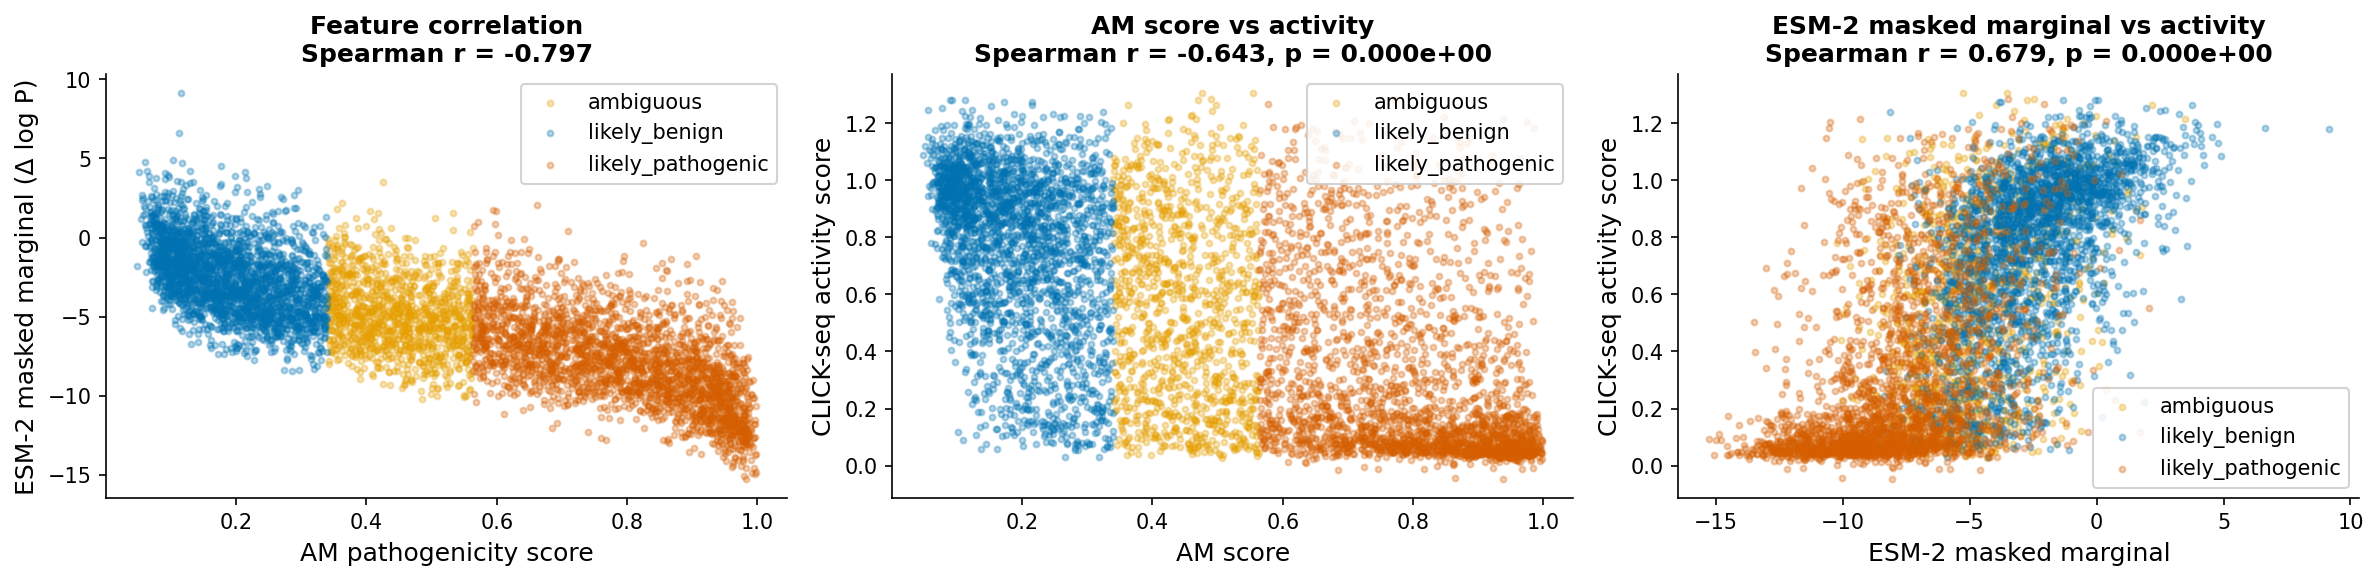

In [4]:
fit = merged[['mutation', 'ref', 'pos', 'alt', 'am_score', 'esm2_mmp', 'click-seq_score', 'am_class']].dropna().copy()
print(f'Total variants with all features: {len(fit):,}')

r_feat, _ = stats.spearmanr(fit['am_score'], fit['esm2_mmp'])
print(f'Spearman(am_score, esm2_mmp) = {r_feat:.3f}  '
      f'(shared variance ≈ {r_feat**2*100:.3f}%)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Feature–feature scatter
ax = axes[0]
for cls, grp in fit.groupby('am_class'):
    ax.scatter(grp['am_score'], grp['esm2_mmp'], color=PALETTE[cls],
               alpha=0.3, s=8, label=cls, rasterized=True)
ax.set_xlabel('AM pathogenicity score', fontsize=12)
ax.set_ylabel('ESM-2 masked marginal (Δ log P)', fontsize=12)
ax.set_title(f'Feature correlation\nSpearman r = {r_feat:.3f}', fontsize=12)
ax.legend(fontsize=10)

# Each feature vs click-seq
for ax, feat, label in zip(axes[1:],
                            ['am_score', 'esm2_mmp'],
                            ['AM score', 'ESM-2 masked marginal']):
    for cls, grp in fit.groupby('am_class'):
        ax.scatter(grp[feat], grp['click-seq_score'], color=PALETTE[cls],
                   alpha=0.3, s=8, label=cls, rasterized=True)
    r, p = stats.spearmanr(fit[feat], fit['click-seq_score'])
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('CLICK-seq activity score', fontsize=12)
    ax.set_title(f'{label} vs activity\nSpearman r = {r:.3f}, p = {p:.3e}', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [5]:
for c in ["likely_benign", "ambiguous", "likely_pathogenic"]:
    r, p = stats.spearmanr(fit.loc[fit['am_class'] == c, 'am_score'], fit.loc[fit['am_class'] == c, 'esm2_mmp'])
    print(f"{c} am score vs esm2 mmp: Spearman r = {r:.3f}, p = {p:.3e}")

likely_benign am score vs esm2 mmp: Spearman r = -0.488, p = 6.485e-152
ambiguous am score vs esm2 mmp: Spearman r = -0.223, p = 1.169e-14
likely_pathogenic am score vs esm2 mmp: Spearman r = -0.615, p = 4.255e-253


## Baseline: per-AM-class Spearman for each feature individually

In [6]:
def spearman_by_class(df, feat, target='click-seq_score'):
    """Return dict {am_class: (n, r, p)} for a given feature."""
    results = {}
    for cls in CLASS_ORDER:
        sub = df[df['am_class'] == cls][[feat, target]].dropna()
        r, p = stats.spearmanr(sub[feat], sub[target])
        results[cls] = (len(sub), r, p)
    return results

baseline_am   = spearman_by_class(fit, 'am_score')
baseline_esm2 = spearman_by_class(fit, 'esm2_mmp')

print('Baseline Spearman r vs CLICK-seq, by AM class\n')
print(f'{"AM class":<24} {"n":>6}  {"AM score":>10}  {"ESM-2 mmp":>10}')
print('-' * 56)
for cls in CLASS_ORDER:
    n, r_am, _   = baseline_am[cls]
    _, r_esm, _  = baseline_esm2[cls]
    print(f'  {cls:<22} {n:>6}  {r_am:>10.3f}  {r_esm:>10.3f}')

Baseline Spearman r vs CLICK-seq, by AM class

AM class                      n    AM score   ESM-2 mmp
--------------------------------------------------------
  likely_benign            2532      -0.354       0.544
  ambiguous                1176      -0.130       0.343
  likely_pathogenic        2433      -0.423       0.446


## Ensemble models: 5-fold cross-validated predictions

Three models trained on CYP2C9 variants with CLICK-seq labels:
- **AM-only**: isotonic regression on `am_score` (monotone decreasing, reproduces existing baseline)
- **ESM2-only**: sigmoid regression on `esm2_mmp` (monotone increasing)
- **Ensemble**: Ridge regression on `[am_score, esm2_mmp]` with StandardScaler

All evaluated with 5-fold CV; predictions are out-of-fold.

In [7]:
train = fit.dropna(subset=['click-seq_score']).copy().reset_index(drop=True)
y     = train['click-seq_score'].values
X_am  = train['am_score'].values
X_esm = train['esm2_mmp'].values
X_ens = train[['am_score', 'esm2_mmp', 'pos']].values   # 3rd column used only to group CV

kf = GroupKFold(n_splits=5, shuffle=True, random_state=42)
groups_train = train['pos'].values

# AM-only isotonic (decreasing: higher AM → lower activity)
oof_am = cross_val_predict(
    IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y, cv=kf, groups=groups_train)

# ESM-2 only sigmoid (increasing: higher mmp → higher activity)
oof_esm = cross_val_predict(
    MonotoneSigmoid(), X_esm, y, cv=kf, groups=groups_train)

# AM + ESM-2: compare Ridge vs constrained non-negative weighted average
oof_ens_ridge = cross_val_predict(CalibratedEnsemble(),  X_ens, y, cv=kf, groups=groups_train)
oof_ens_const = cross_val_predict(ConstrainedEnsemble(), X_ens, y, cv=kf, groups=groups_train)

_r2_ens_r     = r2_score(y, oof_ens_ridge)
_r2_ens_c     = r2_score(y, oof_ens_const)
BestEnsemble2 = CalibratedEnsemble  if _r2_ens_r >= _r2_ens_c else ConstrainedEnsemble
_ens2_method  = 'Ridge'             if _r2_ens_r >= _r2_ens_c else 'Constrained'
oof_ens       = oof_ens_ridge       if _r2_ens_r >= _r2_ens_c else oof_ens_const
ensemble_pipe = BestEnsemble2()

print('AM + ESM-2 ensemble comparison (5-fold OOF R2):')
print(f'  Ridge       {_r2_ens_r:.4f}')
print(f'  Constrained {_r2_ens_c:.4f}')
print(f'  Winner: {_ens2_method}\n')

# Overall metrics
print('5-fold CV overall performance (all AM classes)\n')
print(f'{"Model":<24} {"Spearman r":>12}  {"R2":>8}')
print('-' * 48)
for name, preds in [('AM-only',           oof_am),
                    ('ESM2-only',          oof_esm),
                    ('Ens (Ridge)',         oof_ens_ridge),
                    ('Ens (Constrained)',   oof_ens_const)]:
    r, _ = stats.spearmanr(y, preds)
    r2   = r2_score(y, preds)
    print(f'  {name:<22} {r:>12.3f}  {r2:>8.3f}')

AM + ESM-2 ensemble comparison (5-fold OOF R2):
  Ridge       0.4768
  Constrained 0.4727
  Winner: Ridge

5-fold CV overall performance (all AM classes)

Model                      Spearman r        R2
------------------------------------------------
  AM-only                       0.637     0.399
  ESM2-only                     0.677     0.450
  Ens (Ridge)                   0.698     0.477
  Ens (Constrained)             0.698     0.473


## Per-AM-class Spearman for each model

Does the ensemble Spearman on the **ambiguous** subset approach the level seen for benign/pathogenic?

In [8]:
train['oof_am']  = oof_am
train['oof_esm'] = oof_esm
train['oof_ens'] = oof_ens

model_cols  = {'AM-only': 'oof_am', 'ESM2-only': 'oof_esm', 'AM + ESM-2': 'oof_ens'}
class_results = {}

print('Per-AM-class Spearman r (5-fold OOF predictions vs CLICK-seq)\n')
print(f'{"AM class":<24}', '  '.join(f'{m:>12}' for m in model_cols), '  delta (Ens−AM)')
print('-' * 80)

for cls in CLASS_ORDER:
    sub = train[train['am_class'] == cls]
    row = {}
    for model, col in model_cols.items():
        r, p = stats.spearmanr(sub[col], sub['click-seq_score'])
        row[model] = (len(sub), r, p)
    class_results[cls] = row
    r_vals   = [row[m][1] for m in model_cols]
    delta    = row['AM + ESM-2'][1] - row['AM-only'][1]
    print(f'  {cls:<22}', '  '.join(f'{r:>12.3f}' for r in r_vals), f'  {delta:>+.3f}')

Per-AM-class Spearman r (5-fold OOF predictions vs CLICK-seq)

AM class                      AM-only     ESM2-only    AM + ESM-2   delta (Ens−AM)
--------------------------------------------------------------------------------
  likely_benign                 0.338         0.543         0.551   +0.213
  ambiguous                     0.080         0.341         0.341   +0.260
  likely_pathogenic             0.400         0.441         0.475   +0.075


## Stability bias: AM captures destabilization, not catalysis (4-panel figure)

Correlations are Spearman's $\rho$ between AM score and CYP2C9 CLICK-seq activity (negative: higher
pathogenicity score, lower activity). Abundance strata are a median split of the VAMP-seq abundance
readout (`vamp-seq_score_norm`), computed within whichever population each panel analyzes.

- **A.** Within the ambiguous class, split by abundance: destabilizing (low-abundance) variants retain
  signal ($\rho=-0.186$) while abundance-independent variants do not ($\rho=-0.059$, ns).
- **B.** Extended to all three AM classes; only the ambiguous class shows the abundance-independent
  correlation collapse to non-significance.
- **C.** Whole dataset, destabilizing vs. abundance-independent variants ($\rho=-0.567$ vs. $-0.358$;
  independent-samples Fisher $r$-to-$z$, $p<10^{-18}$).
- **D.** Control: AM-score range/IQR matched between abundance strata within the ambiguous class (so
  panel A is not itself a range-restriction artifact), shown against the equal-width sliding-window
  "typical narrow-window" envelope from the matched-score-width control above -- the destabilizing point
  falls inside that envelope (consistent with ordinary range restriction) while the abundance-independent
  point falls outside/below it (a real effect, not explained by range restriction alone).

In [9]:
# ── Matched score-width control, used by Panel D below: is the ambiguous
# class's low AM-score/activity correlation typical of any narrow AM-score
# window of the same width, or specific to the ambiguous class? ─────────────
amb_lo, amb_hi = fit.loc[fit['am_class'] == 'ambiguous', 'am_score'].agg(['min', 'max'])
amb_width = amb_hi - amb_lo


def sliding_window_rho(df, width, step_frac=0.02, score_col='am_score',
                        target_col='click-seq_score', lo_all=None, hi_all=None):
    """Spearman(score, target) within each equal-width window of the given *width*,
    slid across [lo_all, hi_all] (defaults to df[score_col]'s own min/max). Returns
    (window_centers, rhos)."""
    scores = df[score_col].values
    lo_all = scores.min() if lo_all is None else lo_all
    hi_all = scores.max() if hi_all is None else hi_all
    step = max(width * step_frac, 1e-6)
    centers, rhos = [], []
    lo = lo_all
    while lo + width <= hi_all:
        mask = (scores >= lo) & (scores < lo + width)
        if mask.sum() >= 10:
            r, _ = stats.spearmanr(df.loc[mask, score_col], df.loc[mask, target_col])
            centers.append(lo + width / 2)
            rhos.append(r)
        lo += step
    return np.array(centers), np.array(rhos)


centers_w, rhos_w = sliding_window_rho(fit, width=amb_width,
                                        lo_all=fit['am_score'].min(), hi_all=fit['am_score'].max())

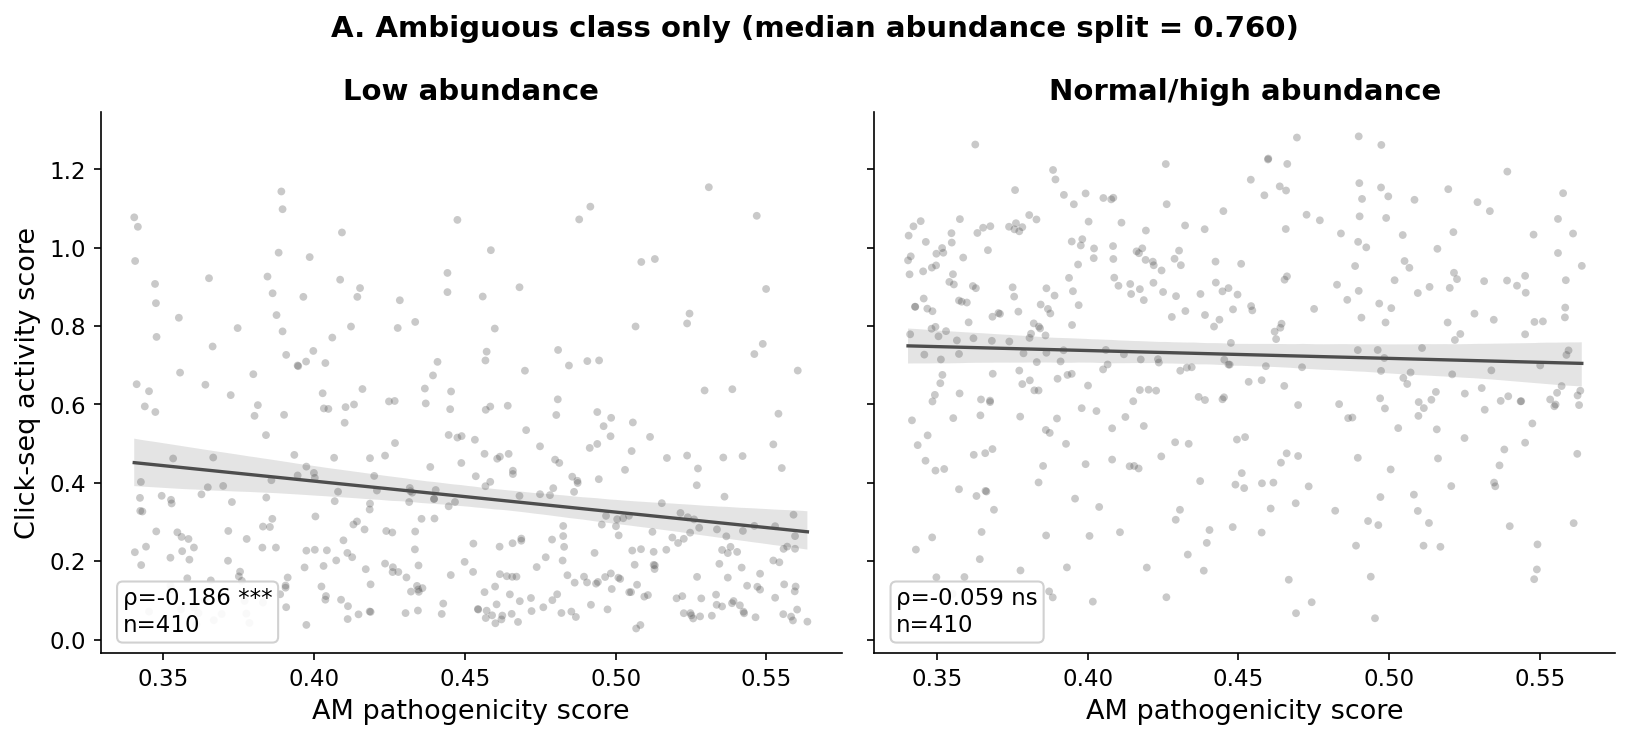

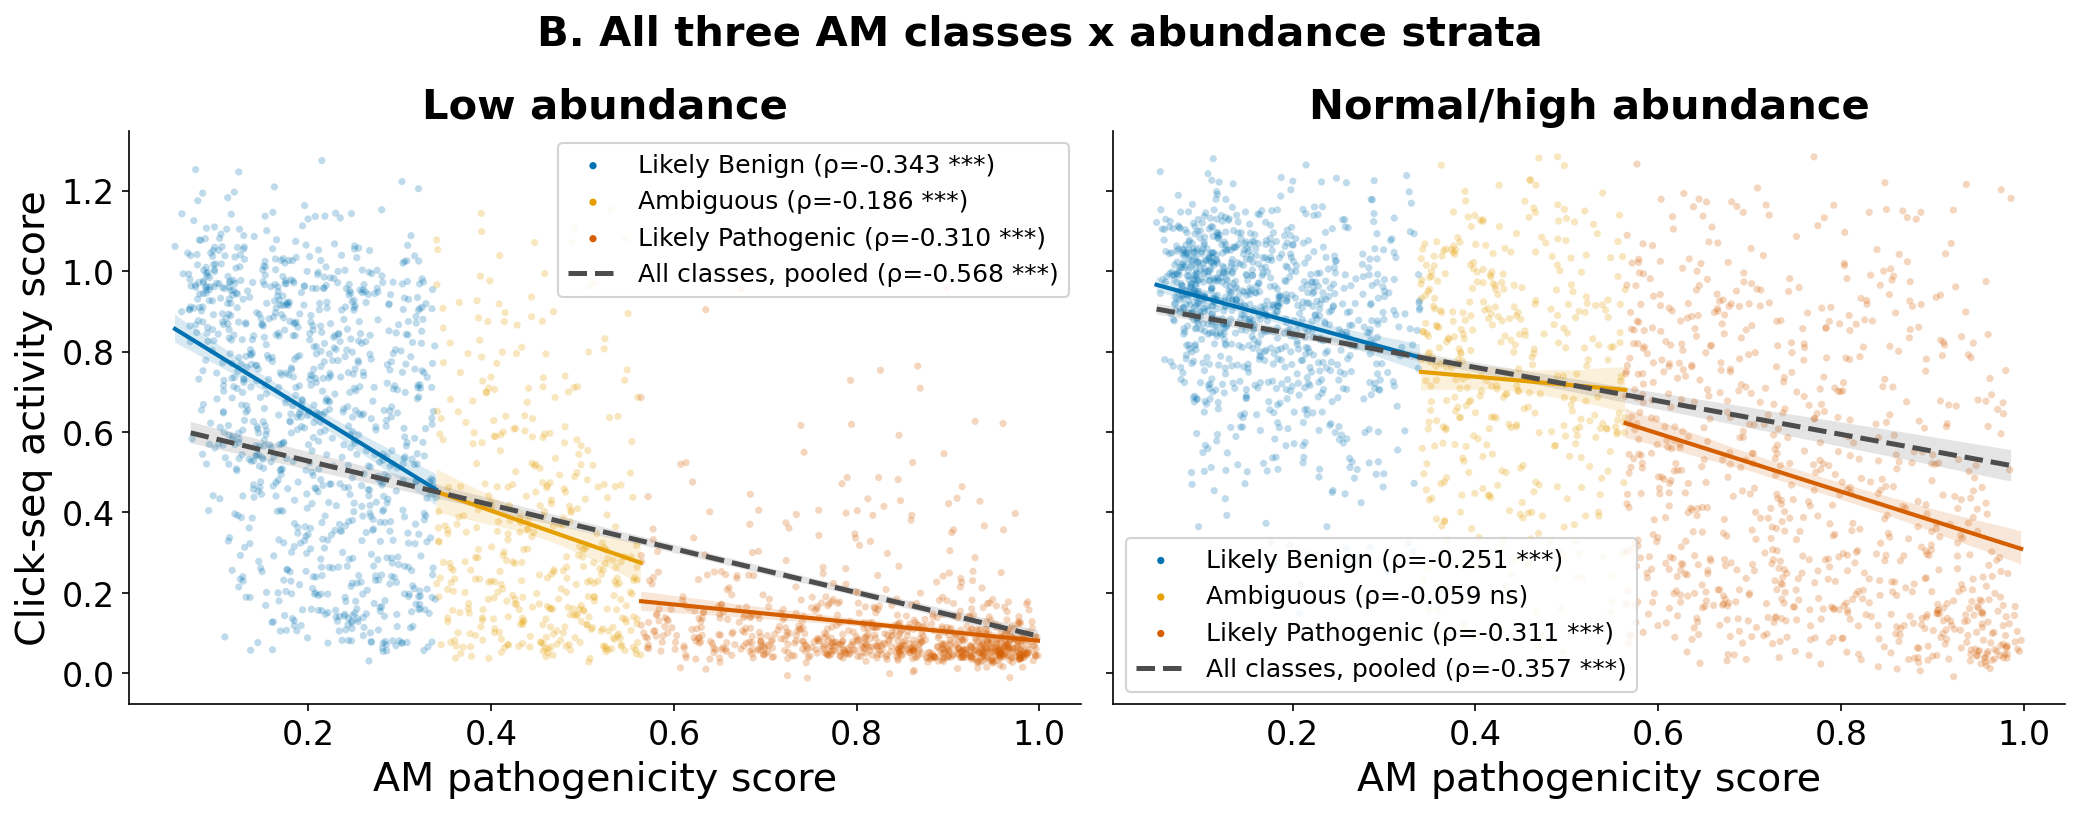

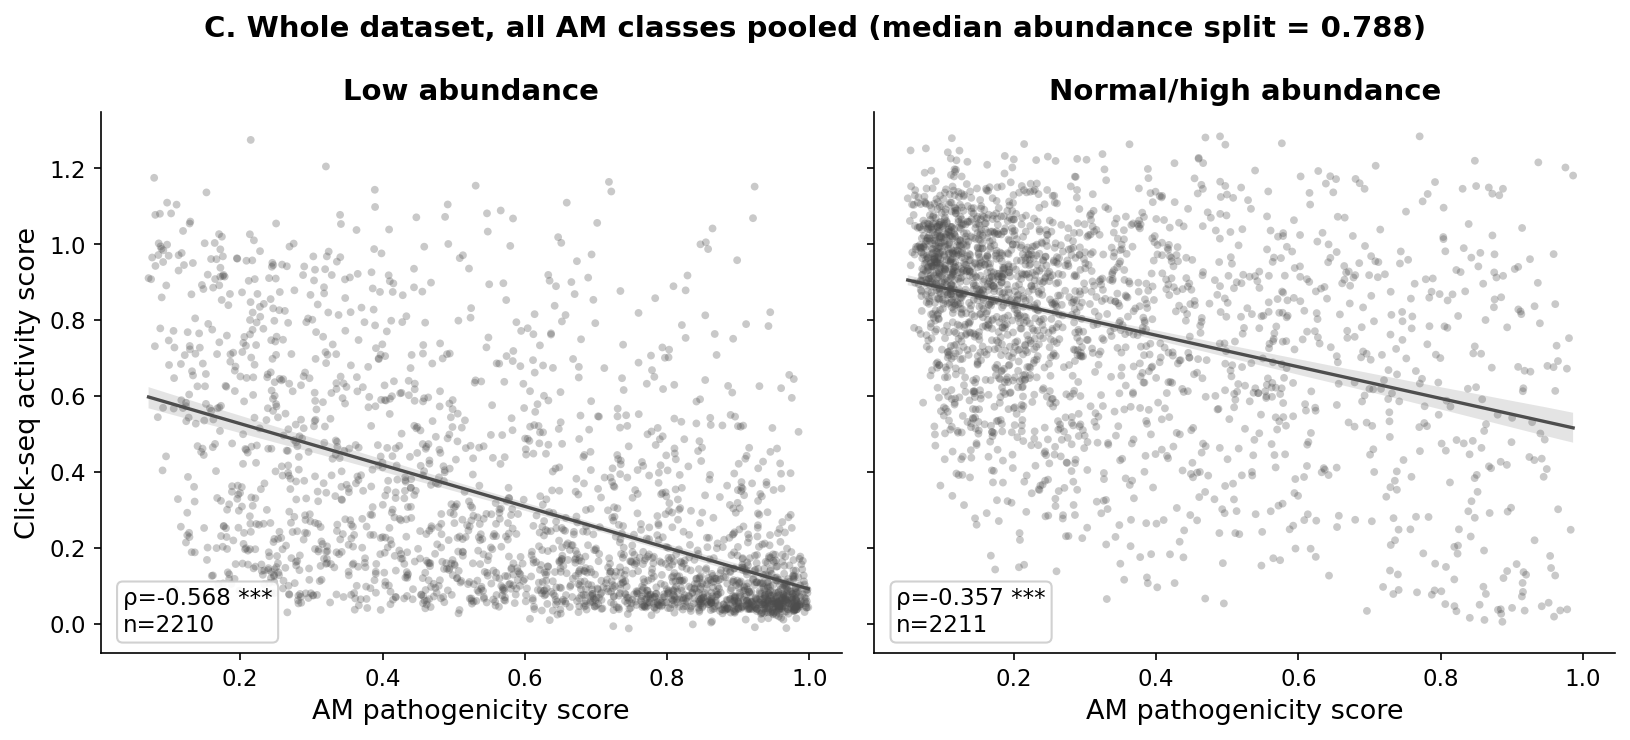

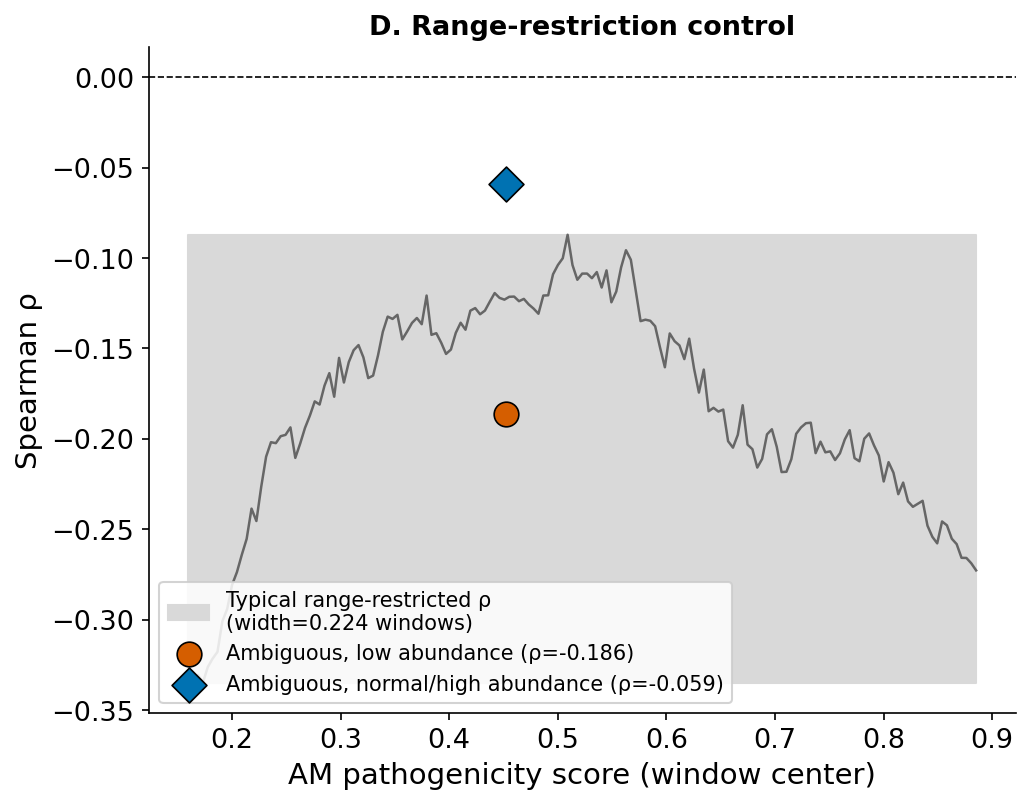

Panel A (ambiguous class only):
  low abundance      : rho=-0.186  p=1.518e-04  n=410
  normal/high abund. : rho=-0.059  p=2.342e-01  n=410

Panel B (all three classes):
  likely_benign        (median split=0.914): low rho=-0.343 (p=1.10e-27, n=952)   normal/high rho=-0.251 (p=4.16e-15, n=953)
  ambiguous            (median split=0.760): low rho=-0.186 (p=1.52e-04, n=410)   normal/high rho=-0.059 (p=2.34e-01, n=410)
  likely_pathogenic    (median split=0.460): low rho=-0.310 (p=2.71e-20, n=848)   normal/high rho=-0.311 (p=1.88e-20, n=848)

Panel C (whole dataset):
  low abundance      : rho=-0.568  p=9.881e-189  n=2210
  normal/high abund. : rho=-0.357  p=1.759e-67  n=2211
  Fisher r-to-z (low vs normal/high, independent samples): z=-8.987  p=0.000e+00

Panel D (range-match check, ambiguous class):
  low abundance           : AM range=[0.340,0.564]  width=0.223  IQR=0.104  n=410
  normal/high abundance   : AM range=[0.340,0.564]  width=0.223  IQR=0.114  n=410
  Typical range-restricted

In [10]:
CLASS_ORDER_AB = ['likely_benign', 'ambiguous', 'likely_pathogenic']
ABUND_COLORS = {'low abundance': '#D55E00', 'normal/high abundance': '#0072B2'}  # still used by Panel D
NEUTRAL_SCATTER_COLOR = '#4D4D4D'  # panels A/C: not one of PALETTE's class colors, avoids clash with panel B
abundance_cols = ['ref', 'pos', 'alt', 'vamp-seq_score_norm']


def abundance_split(df, med=None):
    """Median-split df by VAMP-seq abundance (within df, unless an external `med` is given);
    returns (low_df, high_df, median_used)."""
    med = df['vamp-seq_score_norm'].median() if med is None else med
    return df[df['vamp-seq_score_norm'] < med], df[df['vamp-seq_score_norm'] >= med], med


def rho_by_group(low_df, hi_df, x='am_score', y='click-seq_score'):
    r_lo, p_lo = stats.spearmanr(low_df[x], low_df[y])
    r_hi, p_hi = stats.spearmanr(hi_df[x], hi_df[y])
    return (r_lo, p_lo, len(low_df)), (r_hi, p_hi, len(hi_df))


def fisher_r_to_z(r1, n1, r2, n2):
    z1, z2 = np.arctanh(r1), np.arctanh(r2)
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z = (z1 - z2) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p


def _stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))


def _scatter_reg_panel(ax, df, color, r, p, n, x='am_score', y='click-seq_score', line_color=None):
    """Scatter + OLS fit + 95% CI band (seaborn regplot) for one group, with
    rho/p/n annotated in the title -- replaces the old flat rho-only bar."""
    sns.regplot(x=x, y=y, data=df, ax=ax, ci=95,
                scatter_kws=dict(color=color, alpha=0.3, s=14, rasterized=True, edgecolor='none'),
                line_kws=dict(color=line_color or color, linewidth=1.6))
    ax.text(0.03, 0.03, f'ρ={r:+.3f} {_stars(p)}\nn={n}', transform=ax.transAxes,
            fontsize=11, va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.8', alpha=0.9))
    ax.tick_params(axis='both', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ── Panel A: within-ambiguous, low vs normal/high abundance ─────────────────
amb_ab = (fit[fit['am_class'] == 'ambiguous']
          .merge(merged[abundance_cols].drop_duplicates(['ref', 'pos', 'alt']), on=['ref', 'pos', 'alt'], how='left')
          .dropna(subset=['vamp-seq_score_norm']))
amb_low, amb_hi_grp, amb_med = abundance_split(amb_ab)
amb_lo_stats, amb_hi_stats = rho_by_group(amb_low, amb_hi_grp)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, df, label, st in zip(
    axes, [amb_low, amb_hi_grp], ['Low abundance', 'Normal/high abundance'],
    [amb_lo_stats, amb_hi_stats],
):
    _scatter_reg_panel(ax, df, NEUTRAL_SCATTER_COLOR, *st)
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_xlabel('AM pathogenicity score', fontsize=13)
axes[0].set_ylabel('Click-seq activity score', fontsize=13)
axes[1].set_ylabel('')
fig.suptitle(f'A. Ambiguous class only (median abundance split = {amb_med:.3f})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Whole-dataset (all classes pooled) abundance strata, computed early so
# Panel B can overlay this as a gray reference line (Panel C renders its own
# figure from these same values further below) ──────────────────────────────
all_ab = (fit.merge(merged[abundance_cols].drop_duplicates(['ref', 'pos', 'alt']), on=['ref', 'pos', 'alt'], how='left')
          .dropna(subset=['vamp-seq_score_norm']))
all_low, all_hi, all_med = abundance_split(all_ab)
all_lo_stats, all_hi_stats = rho_by_group(all_low, all_hi)

# ── Panel B: all three AM classes, overlaid by color, x abundance strata ─────
# One plot per abundance stratum (not per class): all three classes overlaid
# on the same axes, colored by PALETTE (same class colors used everywhere else
# in this notebook), plus a gray "all classes pooled" reference line (line
# only, same fit as Panel C) so each class's trend can be compared directly
# to the overall trend, not just to the other two classes.
class_ab_results = {}
for cls in CLASS_ORDER_AB:
    sub_ab = (fit[fit['am_class'] == cls]
              .merge(merged[abundance_cols].drop_duplicates(['ref', 'pos', 'alt']), on=['ref', 'pos', 'alt'], how='left')
              .dropna(subset=['vamp-seq_score_norm']))
    lo_df, hi_df, med = abundance_split(sub_ab)
    class_ab_results[cls] = (rho_by_group(lo_df, hi_df), med, lo_df, hi_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
for ax, stratum_label, stratum_idx in zip(axes, ['Low abundance', 'Normal/high abundance'], [0, 1]):
    for cls in CLASS_ORDER_AB:
        (lo_stats, hi_stats), med, lo_df, hi_df = class_ab_results[cls]
        df, st = (lo_df, lo_stats) if stratum_idx == 0 else (hi_df, hi_stats)
        r, p, n = st
        sns.regplot(x='am_score', y='click-seq_score', data=df, ax=ax, ci=95,
                    scatter_kws=dict(color=PALETTE[cls], alpha=0.25, s=12, rasterized=True, edgecolor='none'),
                    line_kws=dict(color=PALETTE[cls], linewidth=2),
                    label=f'{cls.replace("_", " ").title()} (ρ={r:+.3f} {_stars(p)})')
    all_df, all_st = (all_low, all_lo_stats) if stratum_idx == 0 else (all_hi, all_hi_stats)
    r_all, p_all, n_all = all_st
    sns.regplot(x='am_score', y='click-seq_score', data=all_df, ax=ax, ci=95, scatter=False,
                line_kws=dict(color=NEUTRAL_SCATTER_COLOR, linewidth=2.4, linestyle='--'),
                label=f'All classes, pooled (ρ={r_all:+.3f} {_stars(p_all)})')
    ax.set_title(stratum_label, fontsize=20, fontweight='bold')
    ax.set_xlabel('AM pathogenicity score', fontsize=19)
    ax.tick_params(axis='both', labelsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    leg = ax.legend(fontsize=12, loc='best', frameon=True)
    for handle in leg.legend_handles:
        handle.set_alpha(1)
axes[0].set_ylabel('Click-seq activity score', fontsize=19)
axes[1].set_ylabel('')
fig.suptitle('B. All three AM classes x abundance strata', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Panel C: whole dataset (pooled across AM classes), low vs normal/high ────
# (all_ab/all_low/all_hi/all_med/all_lo_stats/all_hi_stats computed above, for Panel B's overlay)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, df, label, st in zip(
    axes, [all_low, all_hi], ['Low abundance', 'Normal/high abundance'],
    [all_lo_stats, all_hi_stats],
):
    _scatter_reg_panel(ax, df, NEUTRAL_SCATTER_COLOR, *st)
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_xlabel('AM pathogenicity score', fontsize=13)
axes[0].set_ylabel('Click-seq activity score', fontsize=13)
axes[1].set_ylabel('')
fig.suptitle(f'C. Whole dataset, all AM classes pooled (median abundance split = {all_med:.3f})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

z_all, p_z_all = fisher_r_to_z(all_lo_stats[0], all_lo_stats[2], all_hi_stats[0], all_hi_stats[2])

# ── Panel D: range-match control -- ambiguous abundance points vs the
# equal-width sliding-window "typical narrow-window" envelope (centers_w/rhos_w,
# computed in the matched-score-width control above) ────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.fill_between(centers_w, rhos_w.min(), rhos_w.max(), color='0.85', zorder=1,
                label=f'Typical range-restricted ρ\n(width={amb_width:.3f} windows)')
ax.plot(centers_w, rhos_w, color='0.4', linewidth=1.2, zorder=2)
amb_center = np.mean([amb_lo, amb_hi])
ax.scatter([amb_center], [amb_lo_stats[0]], color=ABUND_COLORS['low abundance'], s=140,
           zorder=3, edgecolor='black', linewidth=0.8, label=f'Ambiguous, low abundance (ρ={amb_lo_stats[0]:.3f})')
ax.scatter([amb_center], [amb_hi_stats[0]], color=ABUND_COLORS['normal/high abundance'], s=140,
           zorder=3, edgecolor='black', linewidth=0.8, marker='D',
           label=f'Ambiguous, normal/high abundance (ρ={amb_hi_stats[0]:.3f})')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.tick_params(axis='both', labelsize=13)
ax.set_xlabel('AM pathogenicity score (window center)', fontsize=14)
ax.set_ylabel('Spearman ρ', fontsize=14)
ax.set_title('D. Range-restriction control', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Supporting numbers ────────────────────────────────────────────────────────
print('Panel A (ambiguous class only):')
print(f'  low abundance      : rho={amb_lo_stats[0]:+.3f}  p={amb_lo_stats[1]:.3e}  n={amb_lo_stats[2]}')
print(f'  normal/high abund. : rho={amb_hi_stats[0]:+.3f}  p={amb_hi_stats[1]:.3e}  n={amb_hi_stats[2]}')

print('\nPanel B (all three classes):')
for cls in CLASS_ORDER_AB:
    (lo_stats, hi_stats), med, _, _ = class_ab_results[cls]
    print(f'  {cls:<20} (median split={med:.3f}): '
          f'low rho={lo_stats[0]:+.3f} (p={lo_stats[1]:.2e}, n={lo_stats[2]})   '
          f'normal/high rho={hi_stats[0]:+.3f} (p={hi_stats[1]:.2e}, n={hi_stats[2]})')

print('\nPanel C (whole dataset):')
print(f'  low abundance      : rho={all_lo_stats[0]:+.3f}  p={all_lo_stats[1]:.3e}  n={all_lo_stats[2]}')
print(f'  normal/high abund. : rho={all_hi_stats[0]:+.3f}  p={all_hi_stats[1]:.3e}  n={all_hi_stats[2]}')
print(f'  Fisher r-to-z (low vs normal/high, independent samples): z={z_all:.3f}  p={p_z_all:.3e}')

print('\nPanel D (range-match check, ambiguous class):')
for label, grp in [('low abundance', amb_low), ('normal/high abundance', amb_hi_grp)]:
    lo_s, hi_s = grp['am_score'].min(), grp['am_score'].max()
    iqr = grp['am_score'].quantile(0.75) - grp['am_score'].quantile(0.25)
    print(f'  {label:<24}: AM range=[{lo_s:.3f},{hi_s:.3f}]  width={hi_s-lo_s:.3f}  IQR={iqr:.3f}  n={len(grp)}')
print(f'  Typical range-restricted rho envelope (width-matched windows): '
      f'[{rhos_w.min():.3f}, {rhos_w.max():.3f}], median={np.median(rhos_w):.3f}')

## AM pathogenicity score vs. VAMP-seq abundance, across the full dataset

Direct comparison of AM's pathogenicity score against measured VAMP-seq protein abundance --
the DMS phenotype closest to AM's training signal (structural stability), as opposed to the
CLICK-seq catalytic activity used elsewhere in this notebook. Every DMS variant with both an
AM score and a VAMP-seq measurement is plotted in one panel (no abundance stratification here,
since VAMP-seq abundance is itself the y-axis), colored by AM class with the same palette used
throughout the notebook, plus a pooled "Full dataset" reference line.

Total variants with AM score + VAMP-seq abundance: 6,370


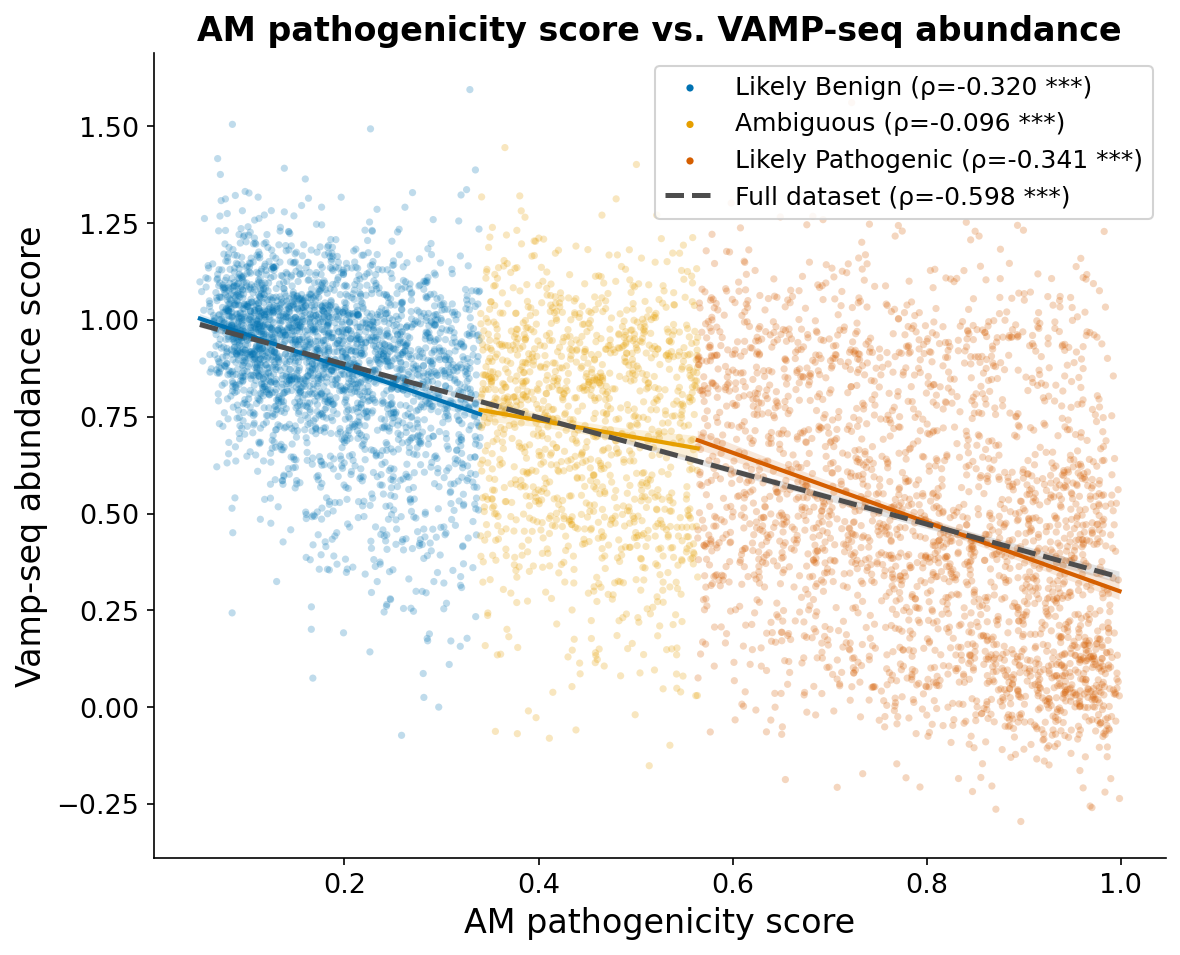


Full dataset: rho=-0.598  p=0.000e+00  n=6,370
  likely_benign       : rho=-0.320  p=1.507e-63  n=2,623
  ambiguous           : rho=-0.096  p=9.655e-04  n=1,189
  likely_pathogenic   : rho=-0.341  p=1.080e-70  n=2,558


In [11]:
# ── AM pathogenicity score vs. VAMP-seq abundance, all AM classes ───────────
# Same three-class color breakdown as Panel B, but VAMP-seq abundance (not
# click-seq activity) on the y-axis, and no abundance stratification (VAMP-seq
# abundance IS the axis here) -- includes every DMS variant with both an AM
# score and a VAMP-seq measurement, independent of CLICK-seq/ESM-2 coverage.
vamp_fit = merged[['ref', 'pos', 'alt', 'am_score', 'am_class', 'vamp-seq_score_norm']].dropna().copy()
print(f'Total variants with AM score + VAMP-seq abundance: {len(vamp_fit):,}')

r_all_vamp, p_all_vamp = stats.spearmanr(vamp_fit['am_score'], vamp_fit['vamp-seq_score_norm'])
n_all_vamp = len(vamp_fit)

class_vamp_stats = {}
for cls in CLASS_ORDER_AB:
    sub = vamp_fit[vamp_fit['am_class'] == cls]
    r, p = stats.spearmanr(sub['am_score'], sub['vamp-seq_score_norm'])
    class_vamp_stats[cls] = (r, p, len(sub))

fig, ax = plt.subplots(figsize=(8, 6.5))
for cls in CLASS_ORDER_AB:
    sub = vamp_fit[vamp_fit['am_class'] == cls]
    r, p, n = class_vamp_stats[cls]
    sns.regplot(x='am_score', y='vamp-seq_score_norm', data=sub, ax=ax, ci=95,
                scatter_kws=dict(color=PALETTE[cls], alpha=0.25, s=12, rasterized=True, edgecolor='none'),
                line_kws=dict(color=PALETTE[cls], linewidth=2),
                label=f'{cls.replace("_", " ").title()} (ρ={r:+.3f} {_stars(p)})')
sns.regplot(x='am_score', y='vamp-seq_score_norm', data=vamp_fit, ax=ax, ci=95, scatter=False,
            line_kws=dict(color=NEUTRAL_SCATTER_COLOR, linewidth=2.4, linestyle='--'),
            label=f'Full dataset (ρ={r_all_vamp:+.3f} {_stars(p_all_vamp)})')
ax.set_xlabel('AM pathogenicity score', fontsize=16)
ax.set_ylabel('Vamp-seq abundance score', fontsize=16)
ax.set_title('AM pathogenicity score vs. VAMP-seq abundance', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
leg = ax.legend(fontsize=12, loc='best', frameon=True)
for handle in leg.legend_handles:
    handle.set_alpha(1)
plt.tight_layout()
plt.show()

print(f'\nFull dataset: rho={r_all_vamp:+.3f}  p={p_all_vamp:.3e}  n={n_all_vamp:,}')
for cls in CLASS_ORDER_AB:
    r, p, n = class_vamp_stats[cls]
    print(f'  {cls:<20}: rho={r:+.3f}  p={p:.3e}  n={n:,}')

## KNN prediction from ESM-2 residue embeddings (subset analysis)

Per-residue ESM-2 representations (shape `[n_variants, 490, 1280]`) are loaded from a pre-built matrix (`rep_matrix.npy`), with variant order given by `rep_matrix_files.txt`.  Mean-pooling across residue positions yields a 1280-dim embedding per variant.  A **K-Nearest Neighbours regressor (K = 5)** is trained on these embeddings and added as a fourth predictor.

The matrix covers 8,802 variants; those present in the CLICK-seq training set form the evaluation subset used here.

An **Ensemble+KNN** model extends the scalar Ridge ensemble by incorporating the KNN embedding prediction as an additional meta-feature.  Within each outer CV fold the KNN is trained on the fold's training portion, its test-fold predictions are passed to Ridge alongside `am_score` and `esm2_mmp`.  To reduce training-fold leakage in the Ridge meta-learner, KNN training-fold meta-features are generated via inner 4-fold CV.

| Model | Features |
|---|---|
| AM-only | `am_score` (isotonic) |
| ESM2-only | `esm2_mmp` (sigmoid) |
| KNN-embed | ESM-2 mean-pool embedding, K=5 |
| Ensemble | Ridge(`am_score`, `esm2_mmp`) |
| Ensemble+KNN | Ridge(`am_score`, `esm2_mmp`, KNN-embed prediction) |

In [12]:
# ── Build mutation → row-index map from the ordered file list ─────────────────
with open(f'{DATA_DIR}/rep_matrix_files.txt') as f:
    rep_files = [l.strip() for l in f]

# e.g. "P11712_Leu201Met.pt" → "Leu201Met"
rep_mutations = [fn.replace('P11712_', '').replace('.pt', '') for fn in rep_files]
mut_to_idx    = {m: i for i, m in enumerate(rep_mutations)}

# ── Memory-map the matrix (8802 × 490 × 1280, float64, ~41 GB on disk) ───────
rep_matrix = np.load(f'{DATA_DIR}/rep_matrix.npy', mmap_mode='r')
print(f'rep_matrix shape: {rep_matrix.shape}  dtype: {rep_matrix.dtype}')
print(f'Variants in matrix: {len(rep_mutations):,}')

# ── Subset: training variants present in the matrix ───────────────────────────
emb_train = train[train['mutation'].isin(mut_to_idx)].copy().reset_index(drop=True)

# Mean-pool over residue positions → (n_subset, 1280)
row_idx = [mut_to_idx[m] for m in emb_train['mutation']]
X_emb   = rep_matrix[row_idx].mean(axis=1).astype(np.float32)   # load + pool row-by-row via mmap

y_emb     = emb_train['click-seq_score'].values
X_am_emb  = emb_train['am_score'].values
X_esm_emb = emb_train['esm2_mmp'].values
X_ens_emb = emb_train[['am_score', 'esm2_mmp']].values

# Residue position for each variant -- used to group CV folds so that all
# substitutions at a given position stay together in either train or test.
groups_emb = emb_train['pos'].values

print(f'\nEmbedding subset: {len(emb_train):,} variants  (embedding dim = {X_emb.shape[1]})')
print(emb_train['am_class'].value_counts().to_string())

rep_matrix shape: (8802, 490, 1280)  dtype: float64
Variants in matrix: 8,802



Embedding subset: 6,141 variants  (embedding dim = 1280)
am_class
likely_benign        2532
likely_pathogenic    2433
ambiguous            1176


In [13]:
kf_emb = GroupKFold(n_splits=5, shuffle=True, random_state=42)

# ── AM-only, ESM2-only, Ensemble re-run on embedding subset ──────────────────
# All folds below are grouped by residue position (groups_emb) so that variants
# at the same position never split across train/test within a fold.
oof_am_emb = cross_val_predict(
    IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am_emb, y_emb,
    cv=kf_emb, groups=groups_emb)

oof_esm_emb = cross_val_predict(
    MonotoneSigmoid(), X_esm_emb, y_emb, cv=kf_emb, groups=groups_emb)

X_ens_emb_grp = np.column_stack([X_ens_emb, groups_emb])   # [am, esm2, pos] for BestEnsemble2's own inner grouped CV
oof_ens_emb = cross_val_predict(BestEnsemble2(), X_ens_emb_grp, y_emb, cv=kf_emb, groups=groups_emb)

# ── KNN on ESM-2 embeddings, fixed hyperparameters (KNN_BEST) ────────────────
# See TunedKNN / _tuned_knn in the imports cell -- weights='distance',
# metric='euclidean', K=30, chosen once via knn_hyperparameter_tuning.ipynb and
# never re-selected per fold.
X_emb_grp   = np.column_stack([X_emb, groups_emb])
oof_knn_emb = cross_val_predict(TunedKNN(), X_emb_grp, y_emb, cv=kf_emb, groups=groups_emb)

# ── Ensemble+KNN: Ridge on [am_score, esm2_mmp, KNN-embed prediction] ────────
# Within each outer CV fold (grouped by residue position):
#   • KNN trained on the train portion using the fixed KNN_BEST hyperparameters
#     (weights='distance', metric='euclidean', K=30) → test-fold KNN predictions
#   • KNN meta-features for the Ridge training set obtained via an inner 4-fold
#     CV, also grouped by position, to reduce training-fold leakage before
#     fitting the meta Ridge (same fixed hyperparameters throughout).
class EnsemblePlusKNN(BaseEstimator, RegressorMixin):
    """Ridge on calibrated [am_activity, esm2_activity, knn_pred] stacked predictor.
    X layout: [0]=am_score, [1]=esm2_mmp, [2:-1]=ESM-2 embedding, [-1]=residue position.
    Position is used only to group the inner CV, never as a predictive feature.
    KNN uses the fixed hyperparameters in KNN_BEST (not re-selected per fold)."""
    def fit(self, X, y):
        X_am, X_esm, X_embed, pos = X[:, 0], X[:, 1], X[:, 2:-1], X[:, -1]
        self.am_cal_  = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am, y)
        self.esm_cal_ = MonotoneSigmoid().fit(X_esm, y)
        self.knn_, self.k_ = _tuned_knn(X_embed, y, pos)
        # inner 4-fold OOF for all three meta-features, grouped by position, to reduce leakage
        inner_cv = GroupKFold(n_splits=4, shuffle=True, random_state=0)
        am_oof  = cross_val_predict(
            IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y,
            cv=inner_cv, groups=pos)
        esm_oof = cross_val_predict(
            MonotoneSigmoid(), X_esm, y,
            cv=inner_cv, groups=pos)
        knn_oof = cross_val_predict(
            _make_knn(), X_embed, y,
            cv=inner_cv, groups=pos)
        X_meta = np.column_stack([am_oof, esm_oof, knn_oof])
        self.ridge_ = Pipeline([('scaler', StandardScaler()),
                                 ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 50)))]).fit(X_meta, y)
        return self

    def predict(self, X):
        X_am, X_esm, X_embed = X[:, 0], X[:, 1], X[:, 2:-1]
        return self.ridge_.predict(np.column_stack([
            self.am_cal_.predict(X_am),
            self.esm_cal_.predict(X_esm),
            self.knn_.predict(X_embed)
        ]))

# Append residue position as the last column so fit()/predict() below can group the
# inner CV by position without ever treating it as a predictive feature.
X_combined        = np.column_stack([X_ens_emb, X_emb, groups_emb])   # [am, esm2, emb_0 ... emb_1279, pos]
oof_ens_knn_ridge = cross_val_predict(
    EnsemblePlusKNN(),            X_combined, y_emb, cv=kf_emb, groups=groups_emb)
oof_ens_knn_const = cross_val_predict(
    ConstrainedEnsemblePlusKNN(), X_combined, y_emb, cv=kf_emb, groups=groups_emb)

_r2_knn_r           = r2_score(y_emb, oof_ens_knn_ridge)
_r2_knn_c           = r2_score(y_emb, oof_ens_knn_const)
BestEnsemblePlusKNN = (EnsemblePlusKNN if _r2_knn_r >= _r2_knn_c
                       else ConstrainedEnsemblePlusKNN)
_knn_method         = 'Ridge'  if _r2_knn_r >= _r2_knn_c else 'Constrained'
oof_ens_knn         = oof_ens_knn_ridge if _r2_knn_r >= _r2_knn_c else oof_ens_knn_const

print('AM + ESM-2 + KNN ensemble comparison (5-fold position-grouped OOF R2, fixed KNN hyperparameters):')
print(f'  Ridge       {_r2_knn_r:.4f}')
print(f'  Constrained {_r2_knn_c:.4f}')
print(f'  Winner: {_knn_method}\n')

# ── Overall metrics on embedding subset ──────────────────────────────────────
print(f'5-fold position-grouped CV performance on embedding subset (n = {len(emb_train)})\n')
print(f'{"Model":<26} {"Spearman r":>12}  {"R2":>8}')
print('-' * 50)
for name, preds in [('AM-only',              oof_am_emb),
                    ('ESM2-only',             oof_esm_emb),
                    ('KNN-embed',             oof_knn_emb),
                    ('Ens (best)',             oof_ens_emb),
                    ('Ens+KNN (Ridge)',        oof_ens_knn_ridge),
                    ('Ens+KNN (Constrained)',  oof_ens_knn_const)]:
    r, _ = stats.spearmanr(y_emb, preds)
    r2   = r2_score(y_emb, preds)
    print(f'  {name:<24} {r:>12.3f}  {r2:>8.3f}')

AM + ESM-2 + KNN ensemble comparison (5-fold position-grouped OOF R2, fixed KNN hyperparameters):
  Ridge       0.4972
  Constrained 0.4809
  Winner: Ridge

5-fold position-grouped CV performance on embedding subset (n = 6141)

Model                        Spearman r        R2
--------------------------------------------------
  AM-only                         0.637     0.399
  ESM2-only                       0.677     0.450
  KNN-embed                       0.597     0.336
  Ens (best)                      0.698     0.477
  Ens+KNN (Ridge)                 0.713     0.497
  Ens+KNN (Constrained)           0.709     0.481


In [14]:
emb_train['oof_am_emb']      = oof_am_emb
emb_train['oof_esm_emb']     = oof_esm_emb
emb_train['oof_knn_emb']     = oof_knn_emb
emb_train['oof_ens_emb']     = oof_ens_emb
emb_train['oof_ens_knn']     = oof_ens_knn

model_cols_emb = {
    'AM-only':      'oof_am_emb',
    'ESM2-only':    'oof_esm_emb',
    'KNN-embed':    'oof_knn_emb',
    'AM + ESM-2':     'oof_ens_emb',
    'AM + ESM-2 + KNN': 'oof_ens_knn',
}

print('Per-AM-class Spearman r on embedding subset (5-fold OOF)\n')
col_w = 14
header = f'{"AM class":<24}' + ''.join(f'{m:>{col_w}}' for m in model_cols_emb)
print(header)
print('-' * (24 + col_w * len(model_cols_emb)))

emb_class_results = {}
for cls in CLASS_ORDER:
    sub = emb_train[emb_train['am_class'] == cls]
    row = {}
    for model, col in model_cols_emb.items():
        r, p = stats.spearmanr(sub[col], sub['click-seq_score'])
        row[model] = (len(sub), r, p)
    emb_class_results[cls] = row
    r_vals = [row[m][1] for m in model_cols_emb]
    delta  = row['AM + ESM-2 + KNN'][1] - row['AM-only'][1]
    n      = row['AM-only'][0]
    print(f'  {cls:<22}' + ''.join(f'{r:>{col_w}.3f}' for r in r_vals)
          + f'   n={n}  delta(Ens+KNN−AM)={delta:+.3f}')

Per-AM-class Spearman r on embedding subset (5-fold OOF)

AM class                       AM-only     ESM2-only     KNN-embed    AM + ESM-2AM + ESM-2 + KNN
----------------------------------------------------------------------------------------------
  likely_benign                  0.338         0.543         0.440         0.551         0.568   n=2532  delta(Ens+KNN−AM)=+0.229
  ambiguous                      0.080         0.341         0.353         0.341         0.399   n=1176  delta(Ens+KNN−AM)=+0.318
  likely_pathogenic              0.400         0.441         0.342         0.475         0.498   n=2433  delta(Ens+KNN−AM)=+0.099


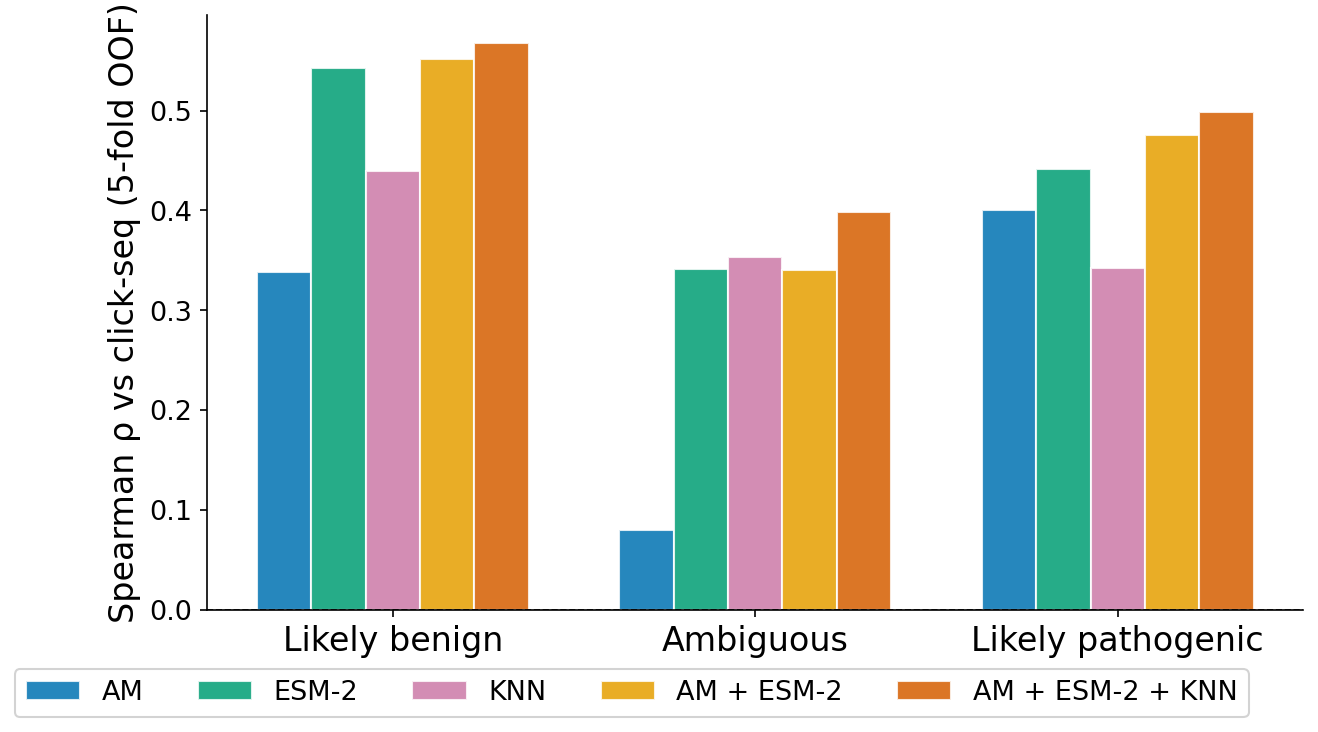

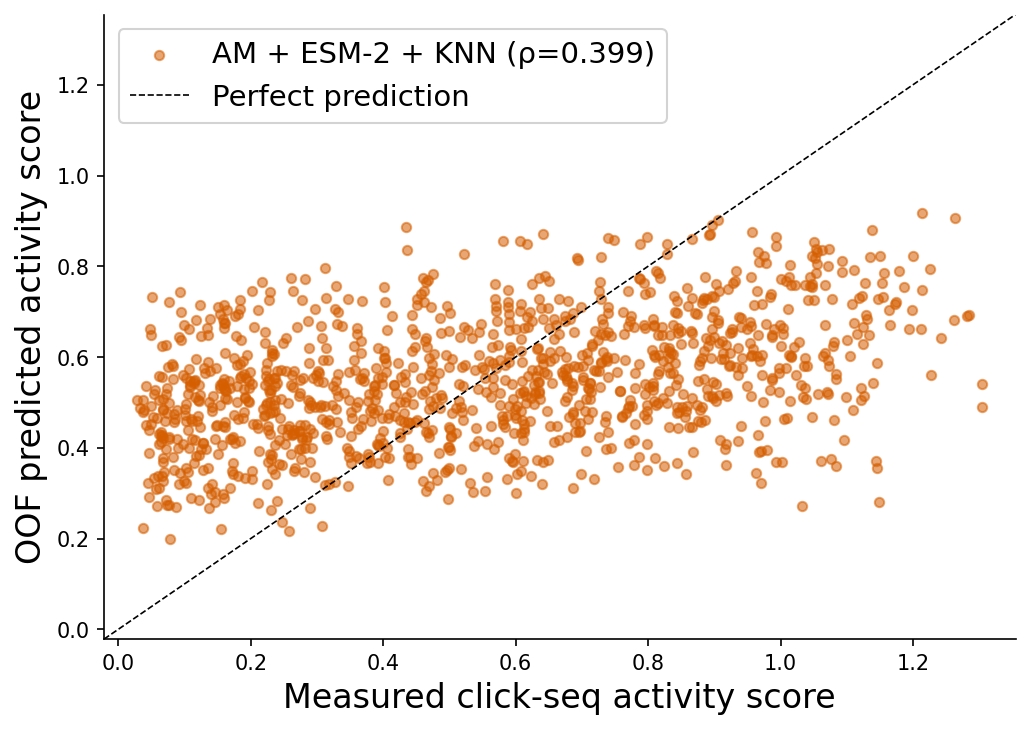

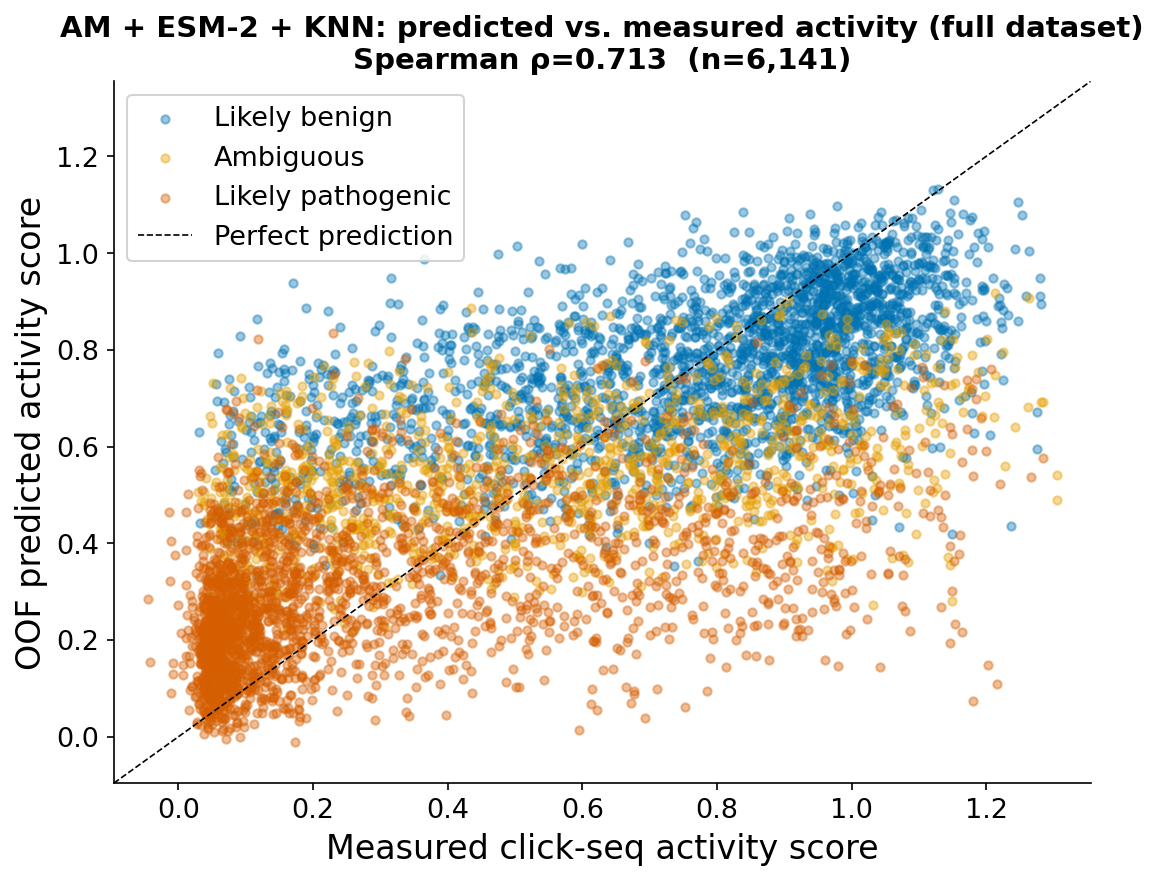

In [15]:
cap = lambda s: s[:1].upper() + s[1:]   # capitalize first letter only, leave the rest
fix_label = lambda s: s.replace('-only', '').replace('KNN-embed', 'KNN').replace('ESM2', 'ESM-2')

# ── Figure 1: per-class grouped bar chart for the embedding subset ───────────
fig1, ax = plt.subplots(figsize=(10, 5))
models_plot  = list(model_cols_emb.keys())
colors_plot  = ['#0072B2', '#009E73', '#CC79A7', '#E69F00', '#D55E00']
x     = np.arange(len(CLASS_ORDER))
width = 0.15

for i, (model, color) in enumerate(zip(models_plot, colors_plot)):
    col    = model_cols_emb[model]
    r_vals = [emb_class_results[cls][model][1] for cls in CLASS_ORDER]
    offset = (i - len(models_plot) / 2 + 0.5) * width
    ax.bar(x + offset, r_vals, width, label=cap(fix_label(model)), color=color,
           alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([cap(c.replace('_', ' ')) for c in CLASS_ORDER], fontsize=16)
ax.tick_params(axis='y', labelsize=13)
ax.set_ylabel('Spearman ρ vs click-seq (5-fold OOF)', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=13, ncol=5, bbox_to_anchor=(0.95, -0.1), borderaxespad=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig1.tight_layout(rect=[0, 0, 0.85, 1])   # reserve right margin for the legend
plt.show()

# ── Figure 2: ambiguous variants scatter — AM + ESM-2 + KNN only ─────────────
fig2, ax = plt.subplots(figsize=(7, 5))
amb_emb = emb_train[emb_train['am_class'] == 'ambiguous'].dropna(subset=['click-seq_score'])
r_ens_knn, _ = stats.spearmanr(amb_emb['oof_ens_knn'], amb_emb['click-seq_score'])

h_ens_knn = ax.scatter(amb_emb['click-seq_score'], amb_emb['oof_ens_knn'],
                       alpha=0.55, s=20, color='#D55E00',
                       label=cap(f'AM + ESM-2 + KNN (ρ={r_ens_knn:.3f})'), rasterized=True)

lims = [amb_emb['click-seq_score'].min() - 0.05,
        amb_emb['click-seq_score'].max() + 0.05]
h_perfect, = ax.plot(lims, lims, 'k--', linewidth=0.8, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Measured click-seq activity score', fontsize=16)
ax.set_ylabel('OOF predicted activity score', fontsize=16)

ax.legend(handles=[h_ens_knn, h_perfect], fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig2.tight_layout()
plt.show()

# ── Figure 3: full dataset scatter, colored by AM class — AM + ESM-2 + KNN ──
fig3, ax = plt.subplots(figsize=(7.5, 6))
full_emb = emb_train.dropna(subset=['click-seq_score', 'oof_ens_knn'])
r_full, p_full = stats.spearmanr(full_emb['oof_ens_knn'], full_emb['click-seq_score'])

for cls in CLASS_ORDER:
    sub = full_emb[full_emb['am_class'] == cls]
    ax.scatter(sub['click-seq_score'], sub['oof_ens_knn'],
               alpha=0.4, s=16, color=PALETTE[cls],
               label=cap(cls.replace('_', ' ')), rasterized=True)

lims = [full_emb['click-seq_score'].min() - 0.05, full_emb['click-seq_score'].max() + 0.05]
ax.plot(lims, lims, 'k--', linewidth=0.8, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Measured click-seq activity score', fontsize=16)
ax.set_ylabel('OOF predicted activity score', fontsize=16)
ax.set_title(f'AM + ESM-2 + KNN: predicted vs. measured activity (full dataset)\n'
             f'Spearman ρ={r_full:.3f}  (n={len(full_emb):,})', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=13)
ax.legend(fontsize=13, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig3.tight_layout()
plt.show()

## Table: consolidated Spearman ρ (position-grouped, nested CV) and exported prediction error

Regenerates the full ρ table under the position-grouped, nested-CV pipeline above, and exports the
AM-calibrated OOF prediction error (`|â_AM − a|`) for use in `alphamissense_ambiguous.ipynb`, where it is
associated with each of the four structural/positional priors (in place of AM's own class label).

In [16]:
table1_full = pd.DataFrame([
    {'Model': 'AM-only',    'Dataset': f'Full DMS (n={len(train):,})', 'Spearman_rho': stats.spearmanr(train['click-seq_score'], train['oof_am'])[0]},
    {'Model': 'ESM2-only',  'Dataset': f'Full DMS (n={len(train):,})', 'Spearman_rho': stats.spearmanr(train['click-seq_score'], train['oof_esm'])[0]},
    {'Model': 'AM + ESM-2', 'Dataset': f'Full DMS (n={len(train):,})', 'Spearman_rho': stats.spearmanr(train['click-seq_score'], train['oof_ens'])[0]},
])
table1_emb = pd.DataFrame([
    {'Model': 'AM-only',          'Dataset': f'Embedding subset (n={len(emb_train):,})', 'Spearman_rho': stats.spearmanr(y_emb, oof_am_emb)[0]},
    {'Model': 'ESM2-only',        'Dataset': f'Embedding subset (n={len(emb_train):,})', 'Spearman_rho': stats.spearmanr(y_emb, oof_esm_emb)[0]},
    {'Model': 'KNN-embed',        'Dataset': f'Embedding subset (n={len(emb_train):,})', 'Spearman_rho': stats.spearmanr(y_emb, oof_knn_emb)[0]},
    {'Model': 'AM + ESM-2',       'Dataset': f'Embedding subset (n={len(emb_train):,})', 'Spearman_rho': stats.spearmanr(y_emb, oof_ens_emb)[0]},
    {'Model': 'AM + ESM-2 + KNN', 'Dataset': f'Embedding subset (n={len(emb_train):,})', 'Spearman_rho': stats.spearmanr(y_emb, oof_ens_knn)[0]},
])
table1 = pd.concat([table1_full, table1_emb], ignore_index=True)
table1['Spearman_rho'] = table1['Spearman_rho'].round(3)
print('=== Table: Spearman rho, position-grouped nested 5-fold OOF CV ===')
print(table1.to_string(index=False))

# ── Export AM-calibrated OOF prediction error for alphamissense_ambiguous.ipynb ──
train['am_error'] = (train['oof_am'] - train['click-seq_score']).abs()
error_export = train[['ref', 'pos', 'alt', 'am_class', 'oof_am', 'click-seq_score', 'am_error']]
error_export.to_csv(f'{DATA_DIR}/am_calibrated_error.csv', index=False)
print(f'\nExported {len(error_export):,} rows of AM-calibrated OOF prediction error to '
      f'{DATA_DIR}/am_calibrated_error.csv for use in alphamissense_ambiguous.ipynb')

=== Table: Spearman rho, position-grouped nested 5-fold OOF CV ===
           Model                    Dataset  Spearman_rho
         AM-only         Full DMS (n=6,141)         0.637
       ESM2-only         Full DMS (n=6,141)         0.677
      AM + ESM-2         Full DMS (n=6,141)         0.698
         AM-only Embedding subset (n=6,141)         0.637
       ESM2-only Embedding subset (n=6,141)         0.677
       KNN-embed Embedding subset (n=6,141)         0.597
      AM + ESM-2 Embedding subset (n=6,141)         0.698
AM + ESM-2 + KNN Embedding subset (n=6,141)         0.713

Exported 6,141 rows of AM-calibrated OOF prediction error to ../data/am_calibrated_error.csv for use in alphamissense_ambiguous.ipynb


## Baseline predictor panel: function-trained and pharmacogene-tuned baselines

1. **DeMaSk** (Singh Lab, github.com/Singh-Lab/DeMaSk) -- function-trained: its directional substitution
   matrix is fit on a collection of deep mutational scanning datasets that predates Amorosi et al. 2021's
   CYP2C9 DMS, so scoring CYP2C9 with it is legitimate out-of-sample transfer, not circular. Installed
   locally (`pip install -e`) and run against the full UniProt P11712 sequence. Its homolog-search step
   (`demask.homologs`, wraps `blastp`) needs either a local BLAST database or NCBI's remote service
   (`blastp -remote`); the remote service silently hung for across multiple attempts -- consistent with 
   compute-node firewall policies. Homologs were instead found with a **local** BLAST search
   against UniProt Swiss-Prot (`makeblastdb` + local `blastp`, ~575k sequences, completed in seconds),
   which sidesteps the network issue entirely.
2. **PharmGScore** (Hajto et al., PMC12971486; github.com/ippas/ifpan-pharmgscore-manuscript) --
   pharmacogene-tuned. Use the authors' own **precomputed PharmGScore values**, released at
   [Zenodo record 15926746](https://zenodo.org/records/15926746) (`PharmGScore-PV-genes.tsv.gz`),
   which already reflect their exact reference pool, dbNSFP version, and transcript choice. Those
   values are keyed by GRCh38 genomic locus, so they were mapped to CYP2C9 protein substitutions via
   Ensembl's exon/CDS coordinates for **ENST00000260682** (confirmed canonical/MANE-Select; its
   conceptual translation matches UniProt P11712 exactly, residue-for-residue, including length).
   3,266 genomic SNVs map onto 2,897 unique missense (ref, pos, alt) substitutions; 310 of those are
   reachable by more than one single-nucleotide path and are averaged across paths, matching the
   published treatment. See `data/pharmgscore_zenodo/map_pgs_to_protein.py` for the mapping code.
   **PharmMLScore**, the repo's other pharmacogene-tuned score, could not be reproduced: its
   gene-specific trained neural-network weights (including a dedicated CYP2C9 model, `CYP2C9.pt`) are
   not released in the repository, and its inputs depend on population-level allele-burden context (a
   per-individual `n` term) that doesn't apply to a standalone per-variant catalog.
3. **dbNSFP breadth panel**, narrowed to **SIFT** and **REVEL** as the two additional results reported
   here.

**Scope note on REVEL and PharmGScore**: both are shown in the DMS activity-panel comparison
(per-AM-class Spearman r vs CLICK-seq, below) but excluded from the ClinVar and PharmVar
clinical-alignment comparisons further down. REVEL is itself partly trained on ClinVar-derived labels.
PharmGScore is an unweighted mean of four components, one of which (FATHMM-XF) is a supervised
classifier whose positive training examples are historically drawn from HGMD -- a curated pathogenic-
variant database that substantially overlaps with ClinVar at the variant level (the other three
components -- CADD, PROVEAN, MutationAssessor -- carry no such risk: CADD's training scheme uses
simulated/fixation-derived proxy labels rather than disease labels, and PROVEAN/MutationAssessor are
purely alignment/conservation-based). This makes PharmGScore's ClinVar/PharmVar exposure partial and
diluted (~1 of 4 equally-weighted components) rather than as direct as REVEL's, but real enough that
correlating either against ClinVar category or PharmVar function would not be a clean independent test
the way it is for the DMS activity panel -- so both are excluded from clinical alignment, kept only in
the activity panel below.


In [17]:
# ── DeMaSk (function-trained) ────────────────────────────────────────────────
demask_pred = pd.read_csv(f'{DATA_DIR}/cyp2c9_demask_predictions.txt', sep='\t')
demask_pred = demask_pred.rename(columns={'WT': 'ref', 'var': 'alt', 'score': 'demask_score'})
demask_pred = demask_pred[['pos', 'ref', 'alt', 'demask_score']]

# ── dbNSFP panel (SIFT, REVEL) ────────────────────────────────────────────────
dbnsfp = pd.read_csv(f'{DATA_DIR}/cyp2c9_dbnsfp_scores.csv')
dbnsfp = dbnsfp.merge(demask_pred, on=['pos', 'ref', 'alt'], how='outer')

# ── PharmGScore: authors' own precomputed values (Hajto et al., Zenodo 15926746) ──
# Mapped from GRCh38 genomic SNVs onto CYP2C9 protein substitutions via
# ENST00000260682 (canonical/MANE-Select; translation matches UniProt P11712
# exactly); see data/pharmgscore_zenodo/map_pgs_to_protein.py.
pgs_zenodo = pd.read_csv(f'{DATA_DIR}/cyp2c9_pharmgscore_zenodo.csv')
dbnsfp = dbnsfp.merge(pgs_zenodo, on=['ref', 'pos', 'alt'], how='left')
dbnsfp = dbnsfp.rename(columns={'pgs_zenodo': 'pharm_g_score'})

# Direction convention (True = higher score -> higher activity/more tolerated).
# Only these four are reported as results (DeMaSk, PharmGScore, SIFT, REVEL); PolyPhen-2,
# PROVEAN, MutationAssessor, VEST4, PrimateAI, FATHMM-XF, and CADD are still fetched/present
# in dbnsfp above but are intentionally excluded from calibration/reporting/plotting here.
EXT_SCORES = {
    'demask_score':     dict(label='DeMaSk',           increasing=True),
    'pharm_g_score':    dict(label='PharmGScore',       increasing=False),
    'sift':             dict(label='SIFT',              increasing=True),
    'revel':            dict(label='REVEL',             increasing=False),
}

train_ext = train.merge(dbnsfp, on=['ref', 'pos', 'alt'], how='left')

kf_ext = GroupKFold(n_splits=5, shuffle=True, random_state=42)
ext_oof_cols = {}
for feat, meta in EXT_SCORES.items():
    mask = train_ext[feat].notna() & train_ext['click-seq_score'].notna()
    sub  = train_ext[mask]
    oof  = cross_val_predict(
        IsotonicRegression(increasing=meta['increasing'], out_of_bounds='clip'),
        sub[feat].values, sub['click-seq_score'].values, cv=kf_ext, groups=sub['pos'].values)
    col = f'oof_{feat}'
    train_ext[col] = np.nan
    train_ext.loc[mask, col] = oof
    ext_oof_cols[meta['label']] = col

print(f'Coverage (DMS variants with a score): '
      + ',  '.join(f'{meta["label"]}={train_ext[feat].notna().sum():,}'
                    for feat, meta in EXT_SCORES.items()))

print('\nPer-AM-class Spearman r (5-fold OOF, baseline predictors vs CLICK-seq)\n')
header = f'{"AM class":<22}' + ''.join(f'{l:>18}' for l in ext_oof_cols)
print(header)
print('-' * len(header))
ext_class_results = {}
for cls in CLASS_ORDER:
    sub = train_ext[train_ext['am_class'] == cls]
    row = {}
    for label, col in ext_oof_cols.items():
        s = sub.dropna(subset=[col, 'click-seq_score'])
        r, p = (stats.spearmanr(s[col], s['click-seq_score']) if len(s) >= 3 else (np.nan, np.nan))
        row[label] = (len(s), r, p)
    ext_class_results[cls] = row
    print(f'  {cls:<20}' + ''.join(f'{row[l][1]:>18.3f}' for l in ext_oof_cols))

print('\nOverall Spearman r (5-fold OOF, all AM classes pooled):')
for label, col in ext_oof_cols.items():
    s = train_ext.dropna(subset=[col, 'click-seq_score'])
    r, p = stats.spearmanr(s[col], s['click-seq_score'])
    print(f'  {label:<16}: rho={r:+.3f}  p={p:.3e}  n={len(s)}')


Coverage (DMS variants with a score): DeMaSk=6,141,  PharmGScore=2,043,  SIFT=2,040,  REVEL=2,040

Per-AM-class Spearman r (5-fold OOF, baseline predictors vs CLICK-seq)

AM class                          DeMaSk       PharmGScore              SIFT             REVEL
----------------------------------------------------------------------------------------------
  likely_benign                    0.146             0.442             0.459             0.364


  ambiguous                        0.158             0.249             0.133             0.104
  likely_pathogenic                0.400             0.338             0.124             0.217

Overall Spearman r (5-fold OOF, all AM classes pooled):
  DeMaSk          : rho=+0.524  p=0.000e+00  n=6141
  PharmGScore     : rho=+0.604  p=2.832e-203  n=2043
  SIFT            : rho=+0.584  p=1.023e-186  n=2040
  REVEL           : rho=+0.539  p=3.840e-154  n=2040


### Table: footing-matched baseline comparison (equal n across all methods)

This restricts **every** model's existing,
already-leak-free OOF prediction to the exact same common-coverage variants that have PharmGScore/SIFT/
REVEL/DeMaSk coverage -- no refitting, just re-evaluating the same predictions on a common held-out set.

In [18]:
common_mask = (train_ext['sift'].notna() & train_ext['pharm_g_score'].notna()
               & train_ext['revel'].notna() & train_ext['demask_score'].notna())
print(f'Footing-matched common subset: n = {common_mask.sum():,}')

oof_sources = {
    'AM-only':          (train,     'oof_am'),
    'ESM2-only':        (train,     'oof_esm'),
    'AM + ESM-2':       (train,     'oof_ens'),
    'KNN-embed':        (emb_train, 'oof_knn_emb'),
    'AM + ESM-2 + KNN': (emb_train, 'oof_ens_knn'),
    'DeMaSk':           (train_ext, 'oof_demask_score'),
    'PharmGScore':      (train_ext, 'oof_pharm_g_score'),
    'SIFT':             (train_ext, 'oof_sift'),
    'REVEL':            (train_ext, 'oof_revel'),
}

target = train_ext.loc[common_mask, ['ref', 'pos', 'alt', 'click-seq_score']]
table1b_rows = []
for label, (df_src, pred_col) in oof_sources.items():
    m = target.merge(df_src[['ref', 'pos', 'alt', pred_col]], on=['ref', 'pos', 'alt'], how='inner').dropna(subset=[pred_col])
    r, p = stats.spearmanr(m[pred_col], m['click-seq_score'])
    table1b_rows.append(dict(Model=label, Spearman_rho=round(r, 3), n=len(m)))

table1b = pd.DataFrame(table1b_rows)
print(f'\n=== Table: footing-matched Spearman rho (n = {common_mask.sum():,} common subset) ===')
print(table1b.to_string(index=False))

Footing-matched common subset: n = 2,040

=== Table: footing-matched Spearman rho (n = 2,040 common subset) ===
           Model  Spearman_rho    n
         AM-only         0.650 2040
       ESM2-only         0.686 2040
      AM + ESM-2         0.713 2040
       KNN-embed         0.625 2040
AM + ESM-2 + KNN         0.721 2040
          DeMaSk         0.523 2040
     PharmGScore         0.604 2040
            SIFT         0.584 2040
           REVEL         0.539 2040


## ClinVar Variant Activity Prediction

In [19]:
AA1_TO_3 = {
    'A':'Ala','C':'Cys','D':'Asp','E':'Glu','F':'Phe','G':'Gly',
    'H':'His','I':'Ile','K':'Lys','L':'Leu','M':'Met','N':'Asn',
    'P':'Pro','Q':'Gln','R':'Arg','S':'Ser','T':'Thr','V':'Val',
    'W':'Trp','Y':'Tyr'
}

def mut_1to3(s):
    p = parse_mut(s)
    if p is None: return None
    ref, pos, alt = p
    r3, a3 = AA1_TO_3.get(ref), AA1_TO_3.get(alt)
    return f'{r3}{pos}{a3}' if r3 and a3 else None

def assign_category(fe):
    fe_l = str(fe).lower()
    if 'likely pathogenic' in fe_l: return 'likely_pathogenic'
    if 'pathogenic'        in fe_l: return 'pathogenic'
    if 'likely benign'     in fe_l: return 'likely_benign'
    if 'benign'            in fe_l: return 'benign'
    if 'uncertain'         in fe_l: return 'uncertain_significance'
    return 'other'

# ── Exclude ClinVar variants from training, then fit all five models ─────────────────────
# Excluded at the POSITION level (not just the exact variant): a same-position sibling of a
# ClinVar variant left in the training pool would still let the KNN component leak position
# information into that ClinVar variant's held-out prediction (the same mechanism fixed for
# the internal CV, but this production fit isn't cross-validated so needed its own fix).
_clinvar_midx     = pd.MultiIndex.from_tuples(clinvar_rpa)
_clinvar_positions = {p[1] for p in clinvar_rpa}
_in_cv        = merged['pos'].isin(_clinvar_positions)
_fit_cv       = merged[~_in_cv][['mutation', 'ref', 'pos', 'alt',
                                  'am_score', 'esm2_mmp', 'click-seq_score', 'am_class']].dropna().copy()
train_cv      = _fit_cv.dropna(subset=['click-seq_score']).copy().reset_index(drop=True)
print(f'ClinVar exclusion (position-level): removed {_in_cv.sum()} variants at '
      f'{len(_clinvar_positions)} positions from merged; {len(train_cv):,} remain for training\n')

y_cv      = train_cv['click-seq_score'].values
X_am_cv   = train_cv['am_score'].values
X_esm_cv  = train_cv['esm2_mmp'].values
X_ens_cv  = train_cv[['am_score', 'esm2_mmp', 'pos']].values   # 3rd column used only to group CV

am_iso_final   = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am_cv,  y_cv)
esm2_sig_final = MonotoneSigmoid().fit(X_esm_cv, y_cv)
ens_pipe_cv    = BestEnsemble2().fit(X_ens_cv, y_cv)

# External baseline predictors (Item 8), refit on the ClinVar-excluded set
train_cv_ext = train_cv.merge(dbnsfp, on=['ref', 'pos', 'alt'], how='left')
ext_models_cv = {}
for feat, meta in EXT_SCORES.items():
    mask = train_cv_ext[feat].notna()
    if mask.sum() < 10:
        continue
    ext_models_cv[feat] = IsotonicRegression(increasing=meta['increasing'], out_of_bounds='clip').fit(
        train_cv_ext.loc[mask, feat].values, train_cv_ext.loc[mask, 'click-seq_score'].values)

# KNN: slice pre-computed emb_train/X_emb to drop ClinVar rows (no disk re-load)
# Same position-level exclusion as above -- critical here since KNN is the model most
# sensitive to a same-position sibling remaining in the training pool.
_in_cv_emb   = emb_train['pos'].isin(_clinvar_positions)
_mask_cv_emb = ~_in_cv_emb
emb_train_cv = emb_train[_mask_cv_emb].copy().reset_index(drop=True)
X_emb_cv     = X_emb[_mask_cv_emb]
y_emb_cv     = emb_train_cv['click-seq_score'].values

knn_final, _knn_final_k = _tuned_knn(X_emb_cv, y_emb_cv, emb_train_cv['pos'].values)
print(f'ClinVar-excluded production KNN: K={_knn_final_k} (fixed, see KNN_BEST)')
ens_knn_final = BestEnsemblePlusKNN().fit(
    np.column_stack([emb_train_cv[['am_score', 'esm2_mmp']].values, X_emb_cv,
                      emb_train_cv['pos'].values]), y_emb_cv)

# ── Build prediction dataframe ────────────────────────────────────────────
cv_pred = result.copy()
cv_pred['mutation_3l'] = cv_pred['mutation'].apply(mut_1to3)
_parsed = cv_pred['mutation'].apply(parse_mut)
cv_pred['ref'] = _parsed.apply(lambda x: x[0] if x else None)
cv_pred['pos'] = pd.to_numeric(_parsed.apply(lambda x: x[1] if x else None), errors='coerce')
cv_pred['alt'] = _parsed.apply(lambda x: x[2] if x else None)
cv_pred['category'] = cv_pred['functional_effect'].apply(assign_category)

# AM scores
cv_pred = cv_pred.merge(
    am[['ref', 'pos', 'alt', 'am_score', 'am_class']], on=['ref', 'pos', 'alt'], how='left'
)
# ESM-2 masked marginal
cv_pred = cv_pred.merge(
    esm2.rename(columns={'mutation': 'mutation_3l'}), on='mutation_3l', how='left'
)
# Click-seq ground truth (held-out)
_click = (merged[['ref', 'pos', 'alt', 'click-seq_score']]
          .dropna(subset=['click-seq_score'])
          .drop_duplicates(['ref', 'pos', 'alt']))
cv_pred = cv_pred.merge(_click, on=['ref', 'pos', 'alt'], how='left')

print(f'ClinVar variants: {len(cv_pred)} rows ({cv_pred["mutation"].nunique()} unique mutations)')
print(f'  AM score:  {cv_pred["am_score"].notna().sum()}  '
      f'ESM-2 MMP: {cv_pred["esm2_mmp"].notna().sum()}  '
      f'Click-seq: {cv_pred["click-seq_score"].notna().sum()} (held-out)\n')

# ── AM individually (isotonic, decreasing) ─────────────────────────────────────────
has_am   = cv_pred['am_score'].notna()
has_esm2 = cv_pred['esm2_mmp'].notna()
has_ens  = has_am & has_esm2

cv_pred['pred_am'] = np.nan
cv_pred.loc[has_am, 'pred_am'] = am_iso_final.predict(cv_pred.loc[has_am, 'am_score'].values)

# ── ESM-2 individually (isotonic, increasing) ─────────────────────────────────────────
cv_pred['pred_esm2'] = np.nan
cv_pred.loc[has_esm2, 'pred_esm2'] = esm2_sig_final.predict(cv_pred.loc[has_esm2, 'esm2_mmp'].values)

# ── Ensemble (AM + ESM-2) ─────────────────────────────────────────────────────────
cv_pred['pred_ensemble'] = np.nan
cv_pred.loc[has_ens, 'pred_ensemble'] = ens_pipe_cv.predict(
    cv_pred.loc[has_ens, ['am_score', 'esm2_mmp']].values
)

# ── External baseline predictors ────────────────────────────────────────────────
cv_pred = cv_pred.merge(dbnsfp, on=['ref', 'pos', 'alt'], how='left')
for feat in ext_models_cv:
    col = f'pred_{feat}'
    cv_pred[col] = np.nan
    has_feat = cv_pred[feat].notna()
    cv_pred.loc[has_feat, col] = ext_models_cv[feat].predict(cv_pred.loc[has_feat, feat].values)

# ── Embedding availability ─────────────────────────────────────────────────────────────────────────
cv_pred['has_embedding'] = cv_pred['mutation_3l'].isin(mut_to_idx)
has_knn = has_ens & cv_pred['has_embedding']

if has_knn.sum() > 0:
    _rows    = [mut_to_idx[m] for m in cv_pred.loc[has_knn, 'mutation_3l']]
    X_cv_emb = rep_matrix[_rows].mean(axis=1).astype(np.float32)
else:
    X_cv_emb = None

# ── KNN individually ───────────────────────────────────────────────────────────────────────────────────────────────────────
cv_pred['pred_knn'] = np.nan
if X_cv_emb is not None:
    cv_pred.loc[has_knn, 'pred_knn'] = knn_final.predict(X_cv_emb)

# ── Ensemble + KNN ─────────────────────────────────────────────────────────────────────────────────────────────────────
cv_pred['pred_ens_knn'] = np.nan
if X_cv_emb is not None:
    X_cv_comb = np.column_stack([cv_pred.loc[has_knn, ['am_score', 'esm2_mmp']].values, X_cv_emb,
                                  cv_pred.loc[has_knn, 'pos'].values])
    cv_pred.loc[has_knn, 'pred_ens_knn'] = ens_knn_final.predict(X_cv_comb)

print('Predictions complete:')
print(f'  AM (individual):     {cv_pred["pred_am"].notna().sum()}')
print(f'  ESM-2 (individual):  {cv_pred["pred_esm2"].notna().sum()}')
print(f'  Ensemble (AM+ESM-2): {cv_pred["pred_ensemble"].notna().sum()}')
print(f'  KNN (individual):    {cv_pred["pred_knn"].notna().sum()}')
print(f'  Ensemble+KNN:        {cv_pred["pred_ens_knn"].notna().sum()}')
for feat in ext_models_cv:
    print(f'  {EXT_SCORES[feat]["label"]:<38}: {cv_pred[f"pred_{feat}"].notna().sum()}')
cv_pred[['mutation', 'category', 'am_score', 'am_class', 'esm2_mmp',
         'pred_am', 'pred_esm2', 'pred_ensemble', 'pred_knn', 'pred_ens_knn', 'click-seq_score']]


ClinVar exclusion (position-level): removed 709 variants at 42 positions from merged; 5,640 remain for training



ClinVar-excluded production KNN: K=30 (fixed, see KNN_BEST)


ClinVar variants: 50 rows (48 unique mutations)
  AM score:  49  ESM-2 MMP: 45  Click-seq: 30 (held-out)



Predictions complete:
  AM (individual):     49
  ESM-2 (individual):  45
  Ensemble (AM+ESM-2): 45
  KNN (individual):    45
  Ensemble+KNN:        45
  DeMaSk                                : 49
  PharmGScore                           : 49
  SIFT                                  : 49
  REVEL                                 : 49


,mutation,category,am_score,am_class,esm2_mmp,pred_am,pred_esm2,pred_ensemble,pred_knn,pred_ens_knn,click-seq_score
0,V6F,uncertain_significance,0.0774,likely_benign,-0.667392,0.977606,0.878163,0.951231,0.850481,0.965316,NaN
1,L9F,uncertain_significance,0.0829,likely_benign,-1.519629,0.951332,0.820055,0.900575,0.877794,0.934402,0.901104
2,C10Y,uncertain_significance,0.2530,likely_benign,-4.357482,0.683094,0.585345,0.629795,0.491913,0.585515,0.544437
3,L15I,uncertain_significance,0.0966,likely_benign,-2.411788,0.914480,0.751658,0.838532,0.946185,0.908254,NaN
4,P35S,uncertain_significance,0.2714,likely_benign,-4.158930,0.642468,0.602795,0.625202,0.559192,0.603650,NaN
5,I42N,uncertain_significance,0.3877,ambiguous,NaN,0.595947,NaN,NaN,NaN,NaN,NaN
6,G46V,uncertain_significance,0.2963,likely_benign,-3.857610,0.642468,0.629230,0.643367,0.303995,0.531330,0.316458
7,Y80F,uncertain_significance,0.1306,likely_benign,NaN,0.831530,NaN,NaN,NaN,NaN,NaN
8,K84E,uncertain_significance,0.3160,likely_benign,-7.521041,0.622497,0.331415,0.430566,0.698755,0.498761,0.519647
9,D89G,uncertain_significance,0.1642,likely_benign,-4.660036,0.798159,0.558802,0.658525,0.774309,0.706660,NaN


In [20]:
# Ensemble model parameters (ClinVar-excluded final fit)
# Inputs are calibrated activity predictions (standardised for Ridge).

def _print_model_params(model, label):
    if hasattr(model, 'weights_'):
        names = (['am_activity', 'esm2_activity'] if len(model.weights_) == 2
                 else ['am_activity', 'esm2_activity', 'knn_activity'])
        print(f'{label} (Constrained):')
        for nm, w in zip(names, model.weights_):
            print(f'  {nm:<14} weight: {w:.4f}')
    else:
        r = model.ridge_['ridge']
        names = (['am_activity', 'esm2_activity'] if len(r.coef_) == 2
                 else ['am_activity', 'esm2_activity', 'knn_activity'])
        print(f'{label} Ridge (alpha={r.alpha_:.3g}):')
        for nm, c in zip(names, r.coef_):
            print(f'  {nm:<14} coef: {c:+.4f}')
        print(f'  {"intercept":<14} {r.intercept_:+.4f}')

_print_model_params(ens_pipe_cv,   'AM + ESM-2')
print()
_print_model_params(ens_knn_final, 'AM + ESM-2 + KNN')


AM + ESM-2 Ridge (alpha=11):
  am_activity    coef: +0.0968
  esm2_activity  coef: +0.1708
  intercept      +0.5393

AM + ESM-2 + KNN Ridge (alpha=25.6):
  am_activity    coef: +0.0817
  esm2_activity  coef: +0.1330
  knn_activity   coef: +0.0708
  intercept      +0.5393


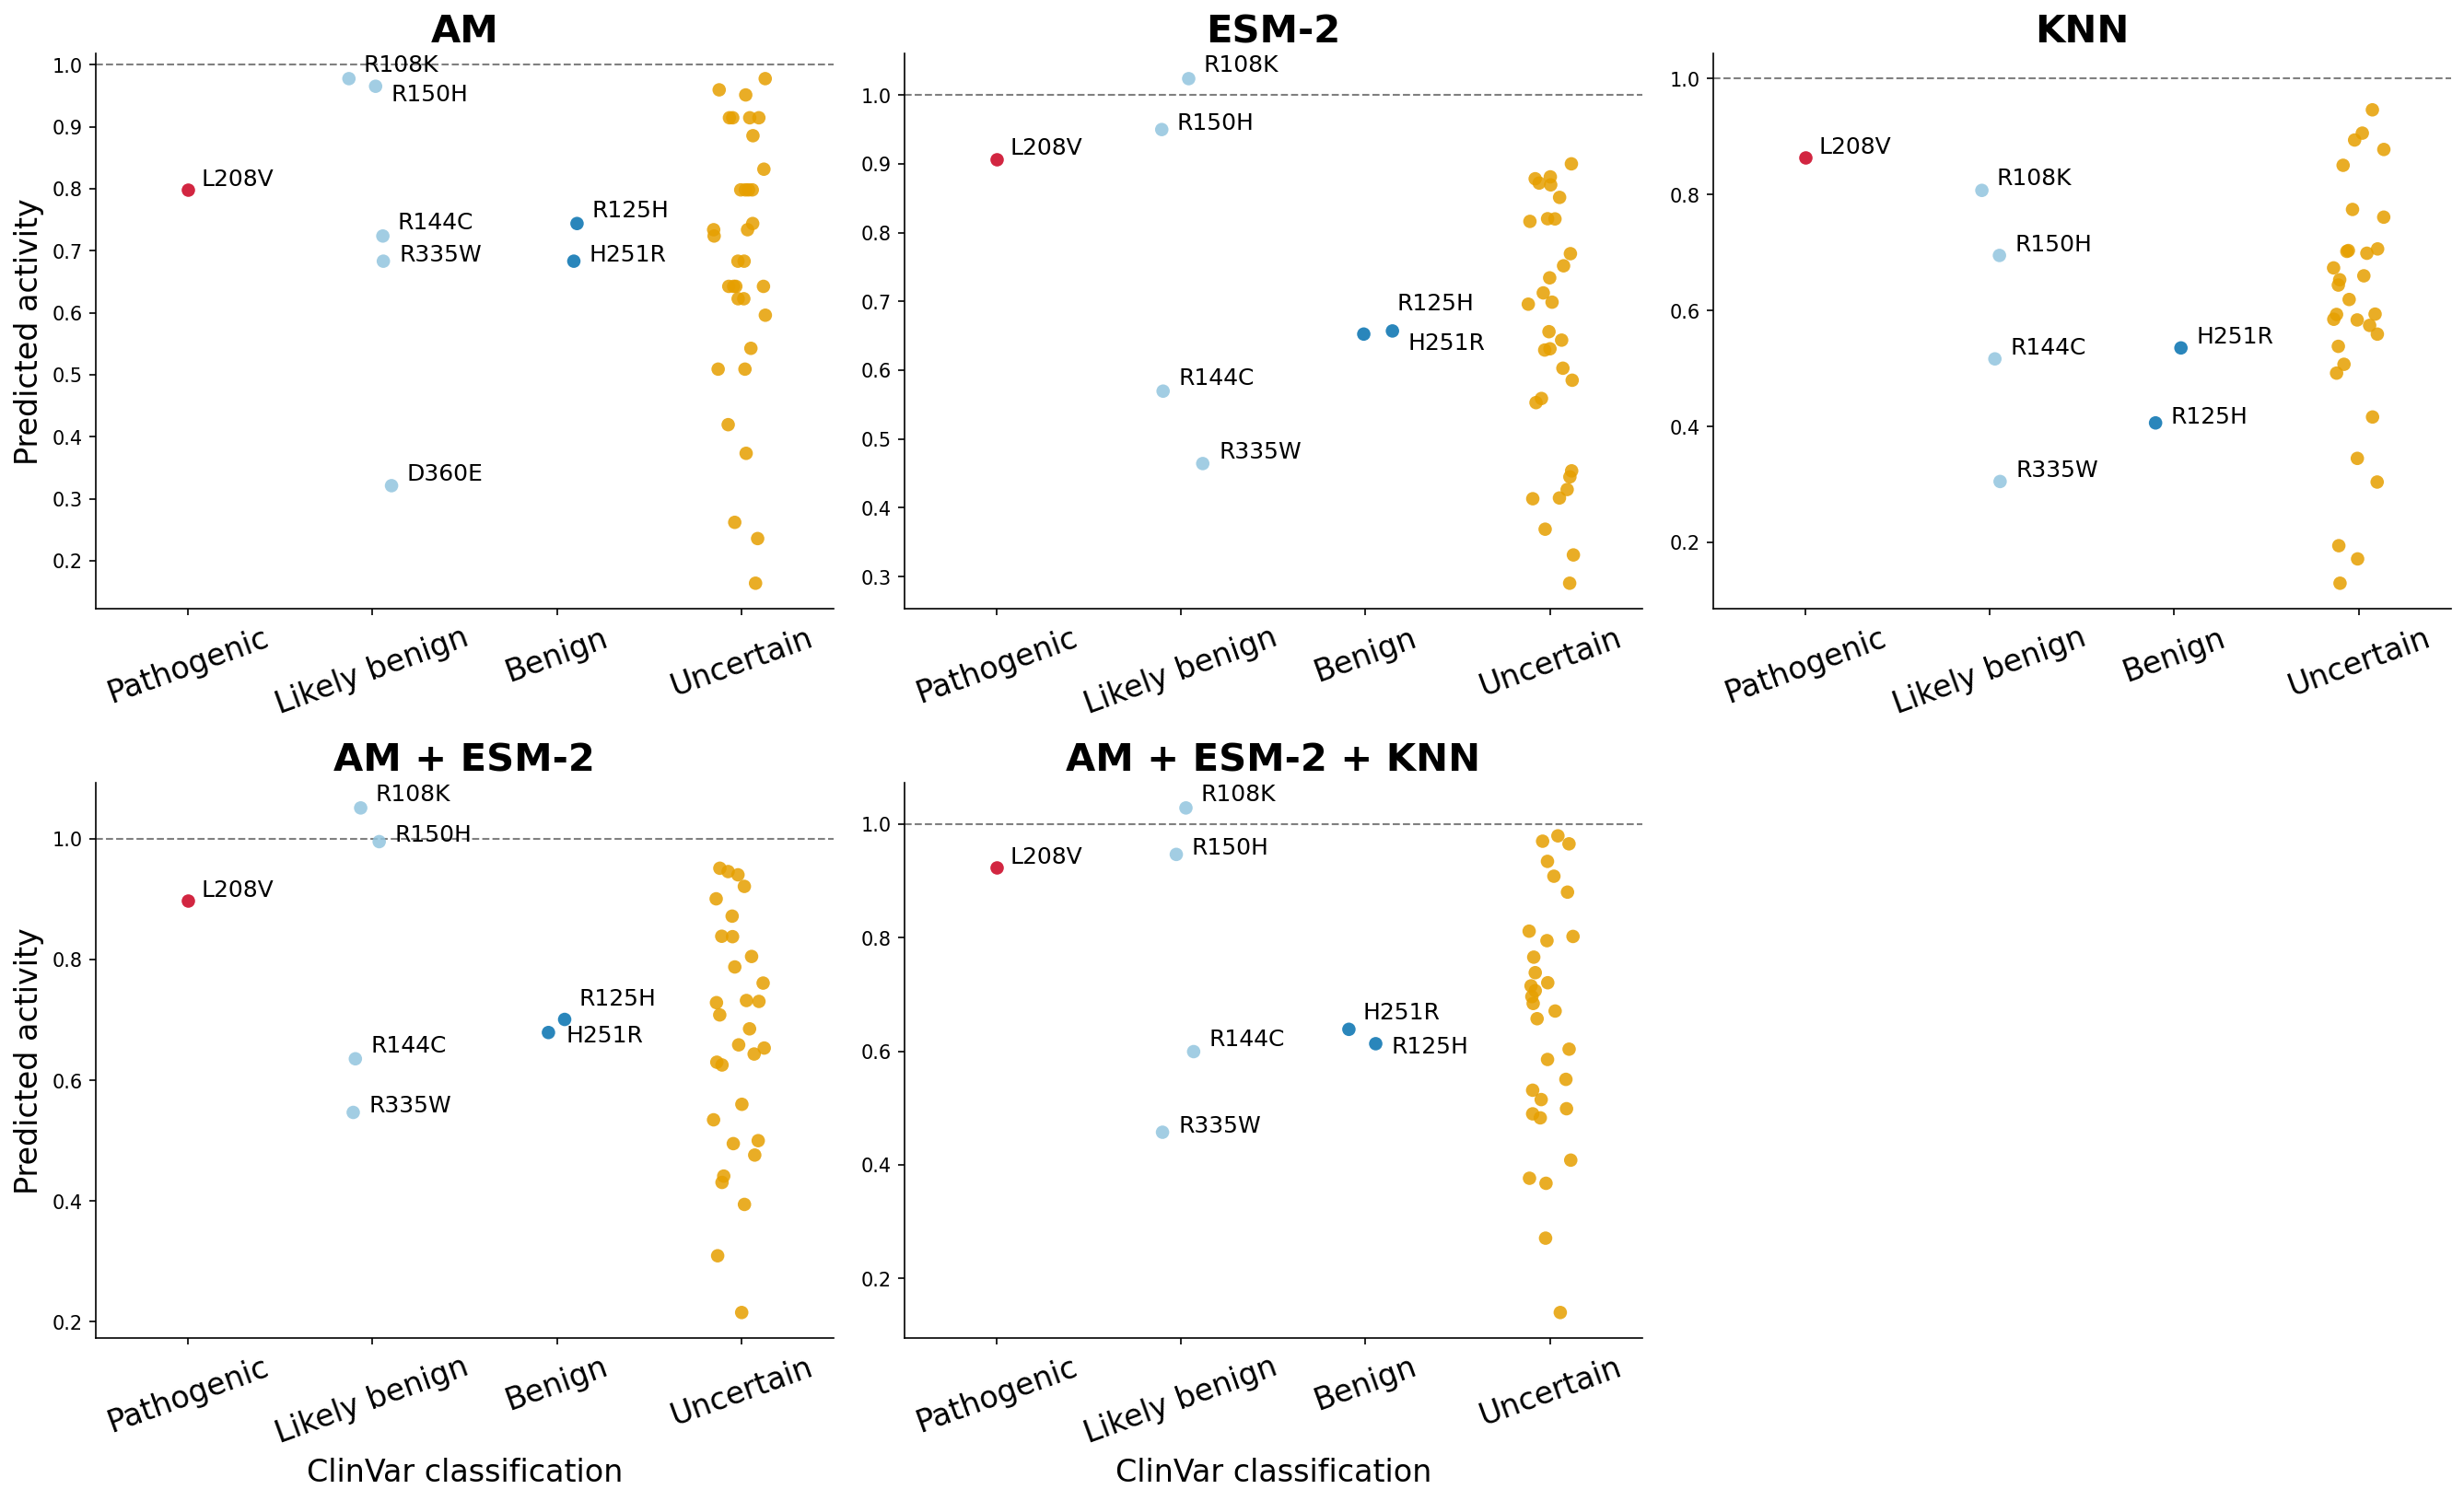

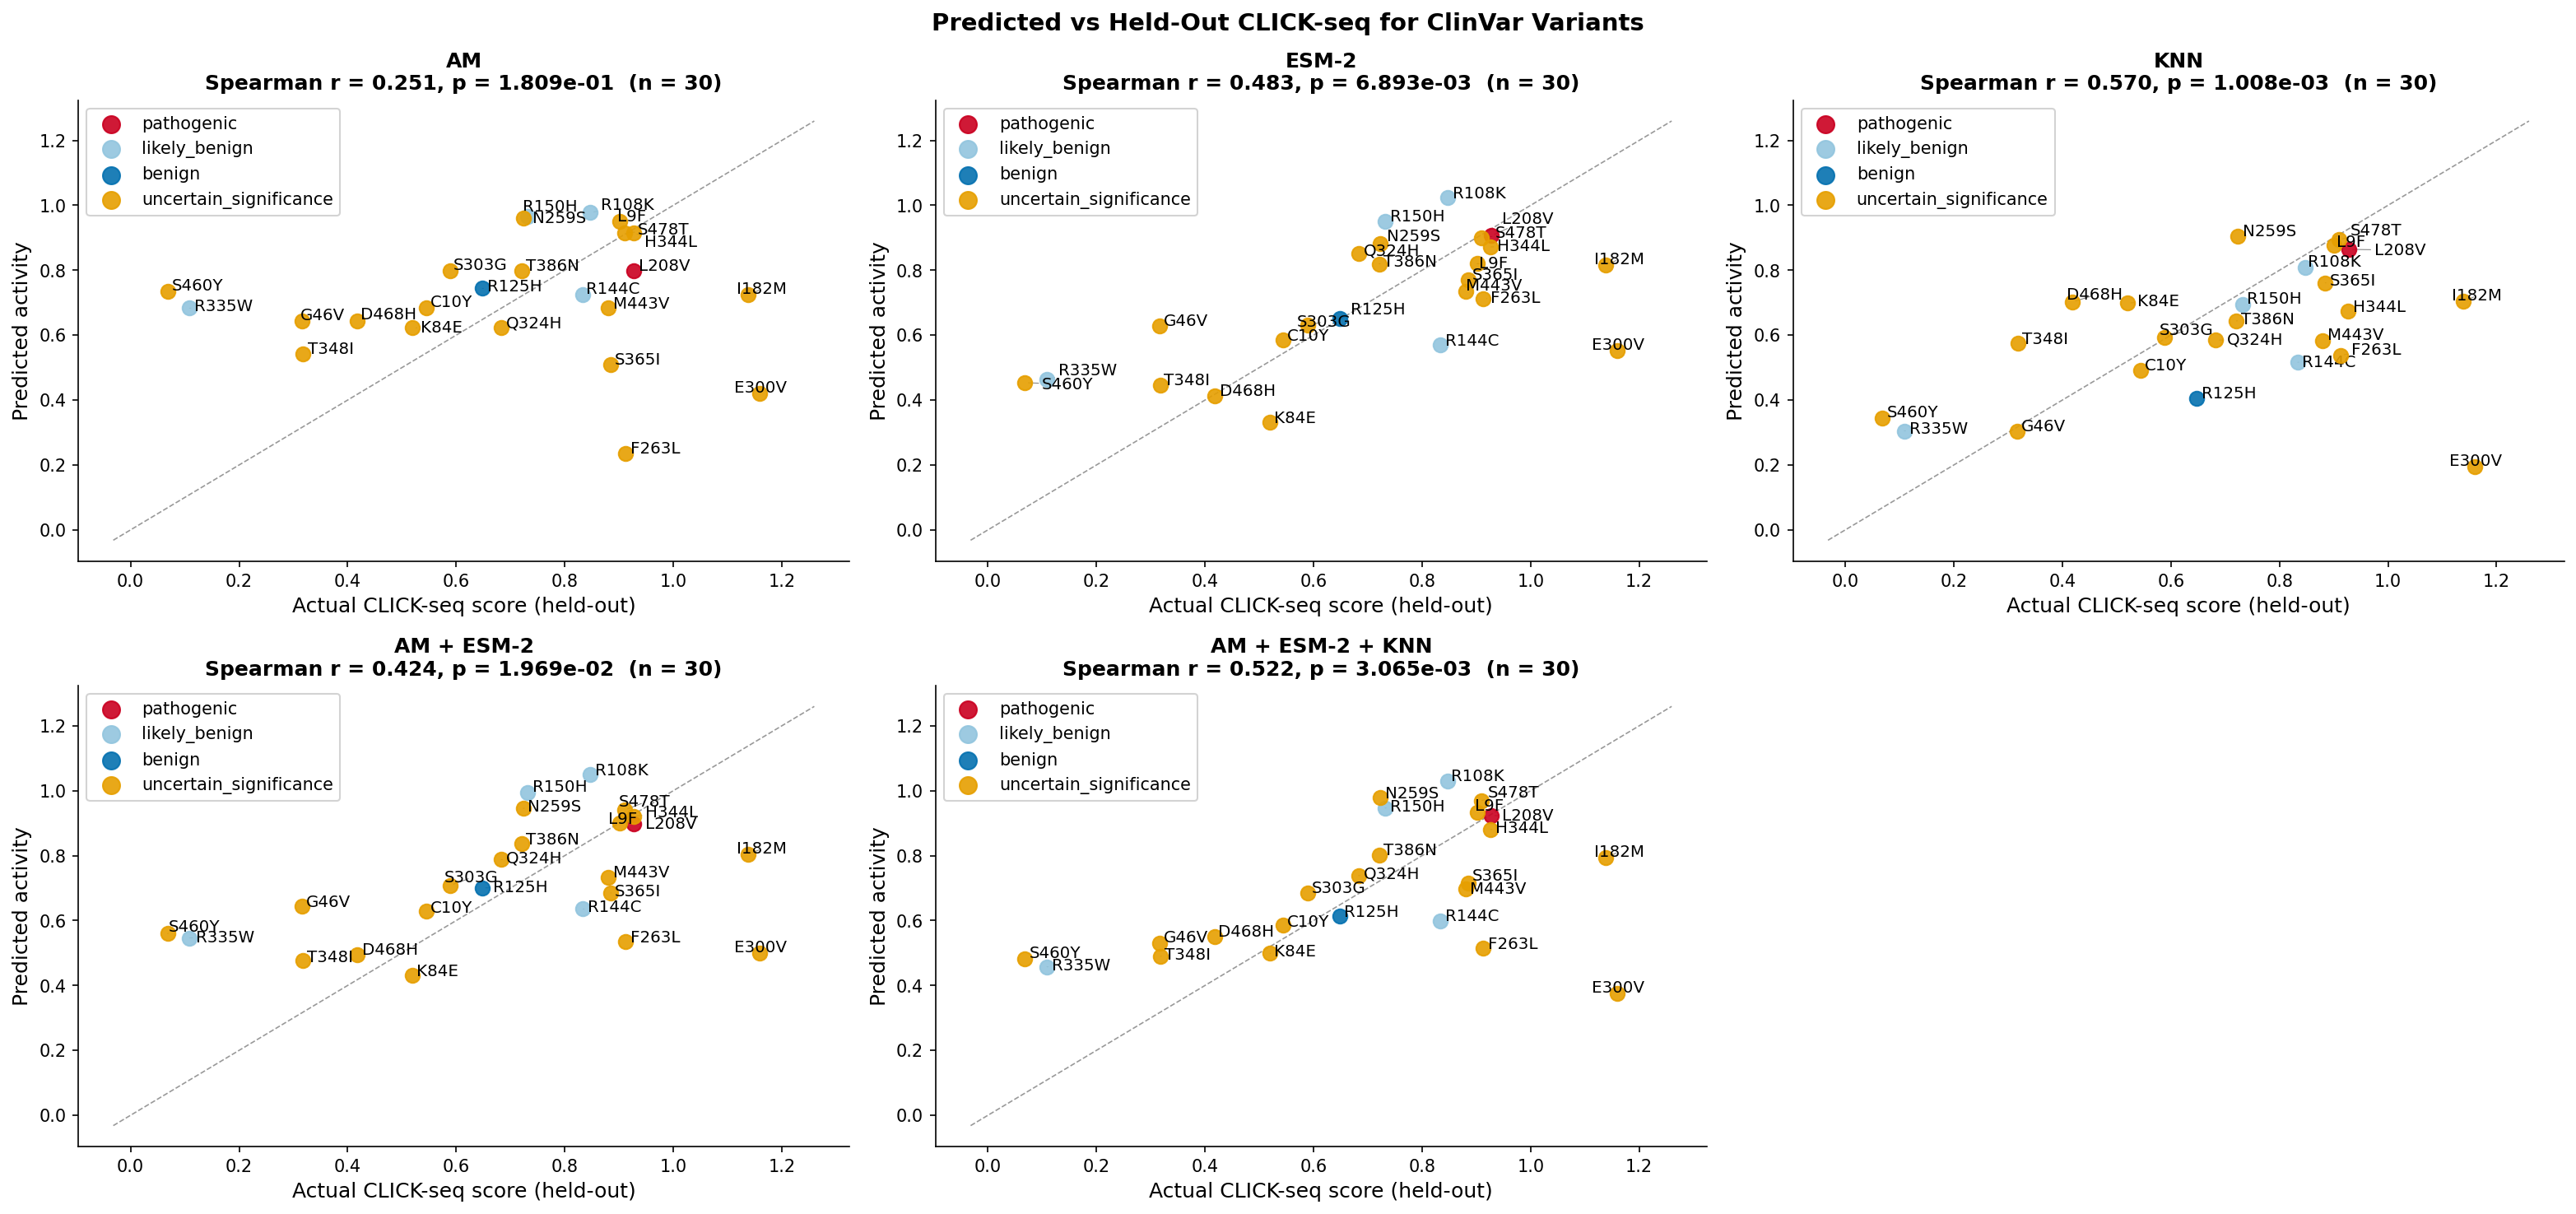

In [21]:
CAT_ORDER  = ['pathogenic', 'likely_benign', 'benign', 'uncertain_significance']
CAT_COLORS = {
    'benign':                 '#0571B0',
    'likely_benign':           '#92C5DE',
    'uncertain_significance':  '#E69F00',
    'likely_pathogenic':       '#F4A582',
    'pathogenic':              '#CA0020',
}
MODELS = [
    ('pred_am',       'AM'),
    ('pred_esm2',     'ESM-2'),
    ('pred_knn',      'KNN'),
    ('pred_ensemble', 'AM + ESM-2'),
    ('pred_ens_knn',  'AM + ESM-2 + KNN'),
]

# Ordinal severity scale for quantifying predicted-activity vs. ClinVar-category
# correlation. Ascending = decreasing pathogenicity (matches the sign convention used
# for PharmVar's func_numeric, where higher = more functional/benign).
# uncertain_significance (VUS) is excluded -- like PharmVar's Uncertain/Unknown Function,
# it is a "we don't know" placeholder rather than a genuine ordinal middle position.
CAT_NUMERIC = {'pathogenic': 0, 'likely_pathogenic': 1, 'likely_benign': 2, 'benign': 3}
cv_pred['cat_numeric'] = cv_pred['category'].map(CAT_NUMERIC)


def plot_activity_by_category(ax, sub, pred_col, cats_sub, label_fontsize=12):
    """Strip plot of predicted activity vs. ClinVar category, with mutation labels
    on every category except uncertain_significance (too numerous to label)."""
    sns.stripplot(data=sub, x='category', y=pred_col, order=cats_sub,
                  hue='category', hue_order=cats_sub, palette=CAT_COLORS,
                  legend=False, ax=ax, jitter=0.15, size=7, alpha=0.85)

    label_cats = set(cats_sub) - {'uncertain_significance'}
    texts = []
    for coll, cat in zip(ax.collections, cats_sub):
        if cat not in label_cats:
            continue
        grp = sub[sub['category'] == cat]
        for (xj, yj) in coll.get_offsets():           # true jittered dot position
            idx = (grp[pred_col] - yj).abs().idxmin()  # match dot back to its mutation
            texts.append(ax.text(xj, yj, grp.loc[idx, 'mutation'], fontsize=label_fontsize))
    adjust_text(texts, ax=ax, only_move={'text': 'y'}, expand_text=(1.05, 1.2))

    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='WT = 1.0')
    ax.set_xticks(range(len(cats_sub)))
    label_map = {'uncertain_significance': 'Uncertain'}
    ax.set_xticklabels([label_map.get(c, c.replace('_', ' ').capitalize()) for c in cats_sub],
                        fontsize=16)
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ── 1. Predicted activity by ClinVar category ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()
ncols, n_used = 3, len(MODELS)

for ax_i, (pred_col, title) in enumerate(MODELS):
    ax = axes_flat[ax_i]
    sub = cv_pred[cv_pred[pred_col].notna()].copy()
    cats_sub = [c for c in CAT_ORDER if c in sub['category'].values]
    sub = sub[sub['category'].isin(cats_sub)].copy()   # drop 'other' / unlisted categories
    if sub.empty:
        ax.text(0.5, 0.5, 'No predictions', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue

    plot_activity_by_category(ax, sub, pred_col, cats_sub)

    ax.set_xlabel('ClinVar classification' if ax_i + ncols > n_used else '', fontsize=16)
    ax.set_ylabel('Predicted activity' if ax_i % ncols == 0 else '', fontsize=16)
    ax.set_title(title, fontsize=20, fontweight='bold')

axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

# ── 2. Predicted vs actual click-seq (held-out validation) ────────────────────
cv_click = cv_pred[cv_pred['click-seq_score'].notna()].copy()

if len(cv_click) >= 2:
    valid_models = [(col, title) for col, title in MODELS if cv_click[col].notna().any()]
    n_panels = len(valid_models)
    ncols = min(3, n_panels)
    nrows = (n_panels + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax_i, (pred_col, title) in enumerate(valid_models):
        ax = axes_flat[ax_i]
        sub = cv_click[cv_click[pred_col].notna()]
        if sub.empty:
            continue

        texts = []
        for cat in CAT_ORDER:
            grp = sub[sub['category'] == cat]
            if len(grp):
                ax.scatter(grp['click-seq_score'], grp[pred_col],
                           color=CAT_COLORS[cat], s=70, alpha=0.9, label=cat, zorder=3)
                for _, row in grp.iterrows():
                    texts.append(ax.text(row['click-seq_score'], row[pred_col],
                                         row['mutation'], fontsize=9.5))
        adjust_text(texts, ax=ax,
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

        lo = min(sub['click-seq_score'].min(), sub[pred_col].min()) - 0.1
        hi = max(sub['click-seq_score'].max(), sub[pred_col].max()) + 0.1
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.4)

        if len(sub) >= 3:
            r, p = stats.spearmanr(sub['click-seq_score'], sub[pred_col])
            ax.set_title(f'{title}\nSpearman r = {r:.3f}, p = {p:.3e}  (n = {len(sub)})',
                         fontsize=12, fontweight='bold')
        else:
            ax.set_title(f'{title}  (n = {len(sub)})', fontsize=12, fontweight='bold')

        ax.set_xlabel('Actual CLICK-seq score (held-out)', fontsize=12)
        ax.set_ylabel('Predicted activity', fontsize=12)
        ax.legend(fontsize=10, markerscale=1.2)

    for ax_i in range(len(valid_models), nrows * ncols):
        axes_flat[ax_i].set_visible(False)

    fig.suptitle('Predicted vs Held-Out CLICK-seq for ClinVar Variants',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Only {len(cv_click)} ClinVar variant(s) with click-seq scores — skipping scatter.')


### Quantifying predicted activity vs. ClinVar category (all models)

Spearman ρ: predicted activity vs ordinal ClinVar category
(pathogenic=0, likely_pathogenic=1, likely_benign=2, benign=3;
 uncertain_significance/VUS excluded -- not a genuine ordinal middle, "unknown"
 the same way PharmVar's Uncertain/Unknown Function categories are)

  AM                  : rho=-0.270  p=0.518 ns  n=8
  ESM-2               : rho=-0.219  p=0.637 ns  n=7
  KNN                 : rho=-0.538  p=0.213 ns  n=7
  AM + ESM-2          : rho=-0.219  p=0.637 ns  n=7
  AM + ESM-2 + KNN    : rho=-0.219  p=0.637 ns  n=7
  DeMaSk              : rho=-0.501  p=0.206 ns  n=8
  SIFT                : rho=-0.270  p=0.518 ns  n=8
  Measured DMS        : rho=-0.676  p=0.140 ns  n=6


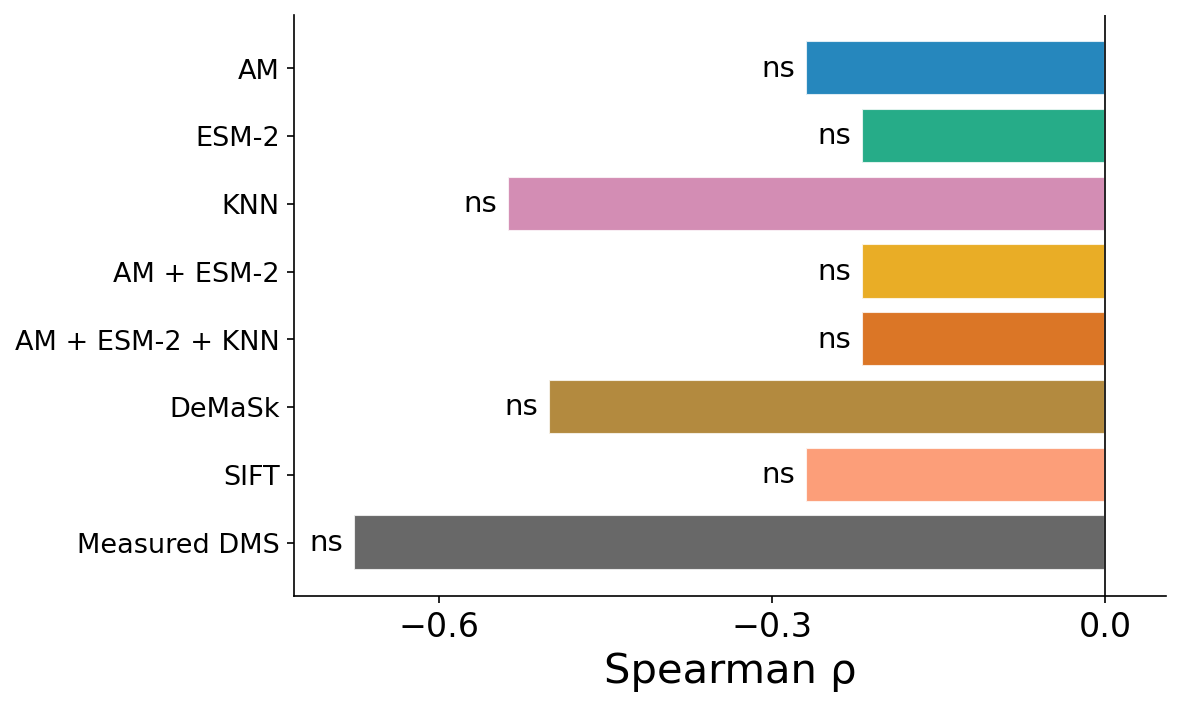

In [22]:
print('Spearman ρ: predicted activity vs ordinal ClinVar category')
print('(pathogenic=0, likely_pathogenic=1, likely_benign=2, benign=3;')
print(' uncertain_significance/VUS excluded -- not a genuine ordinal middle, "unknown"')
print(' the same way PharmVar\'s Uncertain/Unknown Function categories are)\n')

# Include the raw measured click-seq score itself as a "Measured DMS" reference
# bar -- how well does the ground-truth DMS activity itself agree with the
# ClinVar ordinal category, independent of any model? (predicted -> measured)
EXT_ORDER = ['demask_score', 'sift']  # PharmGScore, REVEL excluded from clinical alignment (see markdown above)
MODELS_WITH_DMS = (MODELS
                   + [(f'pred_{f}', EXT_SCORES[f]['label']) for f in EXT_ORDER
                      if f'pred_{f}' in cv_pred.columns]
                   + [('click-seq_score', 'Measured DMS')])

clinvar_ord_results = []
for pred_col, name in MODELS_WITH_DMS:
    sub = cv_pred.dropna(subset=['cat_numeric', pred_col])
    if len(sub) >= 3:
        rho, p = stats.spearmanr(sub['cat_numeric'], sub[pred_col])
    else:
        rho, p = float('nan'), float('nan')
    clinvar_ord_results.append(dict(model=name, rho=rho, p=p, n=len(sub)))
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {name:<20}: rho={rho:+.3f}  p={p:.3f} {stars}  n={len(sub)}')

# ── Bar chart: Spearman rho by model ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 0.45 * len(MODELS_WITH_DMS) + 1.5))
names = [r['model'].replace('(individual)', '').strip() for r in clinvar_ord_results]
rhos  = [r['rho'] for r in clinvar_ord_results]
ps    = [r['p']   for r in clinvar_ord_results]

# AM, ESM-2, KNN, AM+ESM-2, AM+ESM-2+KNN, DeMaSk, SIFT,
# Measured DMS (dark gray = ground-truth reference)
MODEL_COLORS = ['#0072B2', '#009E73', '#CC79A7', '#E69F00', '#D55E00',
                '#A6761D', '#FC8D62', '#4D4D4D']

def _tight_rho_xaxis(ax, rhos, pad_frac=0.08):
    """Tight x-limits around just the bars (always including 0), with a small,
    clean tick set (0 plus 1-2 more) instead of fixed (-1, 1) limits."""
    vals = [v for v in rhos if v == v] + [0.0]
    lo, hi = min(vals), max(vals)
    span = (hi - lo) or 1.0
    pad = span * pad_frac
    lo_lim, hi_lim = lo - pad, hi + pad
    ax.set_xlim(lo_lim, hi_lim)
    raw_ticks = MaxNLocator(nbins=3).tick_values(lo_lim, hi_lim)
    ticks = sorted(set([0.0] + [t for t in raw_ticks if lo_lim <= t <= hi_lim]))
    if len(ticks) > 3:
        ticks = sorted({0.0, ticks[0], ticks[-1]})
    ax.set_xticks(ticks)

ys   = range(len(names))
bars = ax.barh(list(ys), rhos, color=MODEL_COLORS[:len(names)], alpha=0.85, edgecolor='white')
for bar, v, p in zip(bars, rhos, ps):
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    yc = bar.get_y() + bar.get_height() / 2
    if v >= 0:
        ax.text(v + 0.01, yc, f'{stars}', va='center', ha='left', fontsize=14)
    else:
        ax.text(v - 0.01, yc, f'{stars}', va='center', ha='right', fontsize=14)

ax.set_yticks(list(ys))
ax.set_yticklabels(names, fontsize=13)
ax.invert_yaxis()                     # AM at top → Measured DMS at bottom
ax.axvline(0, color='black', linewidth=0.8)
_tight_rho_xaxis(ax, rhos)
ax.set_xlabel('Spearman ρ', fontsize=20)
ax.tick_params(axis='x', labelsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## PharmVar Allele Activity Prediction

Predicts CYP2C9 functional activity for all 78 PharmVar missense alleles using all five methods.

**Function label encoding** for ordinal correlation (Uncertain / Unknown / Function Not Assigned are excluded from label correlations):

| PharmVar label | Ordinal score |
|---|---|
| No Function | 0 |
| Decreased Function | 1 |
| Normal Function | 2 |

**Evidence Level** (`Limited` / `Moderate` / `Definitive`) is incorporated by stratifying correlations at three inclusion thresholds and by encoding marker shape in visualisations.

In [23]:
PV_MODELS = [
    ('pred_am',       'AM (individual)'),
    ('pred_esm2',     'ESM-2 (individual)'),
    ('pred_ensemble', 'AM + ESM-2'),
    ('pred_knn',      'KNN (individual)'),
    ('pred_ens_knn',  'AM + ESM-2 + KNN'),
]

# ── Load PharmVar missense alleles ─────────────────────────────────────────────────────────────────────
pv = pd.read_csv(f'{DATA_DIR}/pharmvar_cyp2c9_missense_mutations_single.csv')
pv_rpa = set(zip(pv['ref'], pv['pos'].astype(int), pv['alt']))   # exclusion set before any merges

pv['mutation_3l'] = pv.apply(
    lambda r: f"{AA1_TO_3.get(r['ref'], '')}{r['pos']}{AA1_TO_3.get(r['alt'], '')}"
              if AA1_TO_3.get(r['ref']) and AA1_TO_3.get(r['alt']) else None,
    axis=1
)

# Merge AM scores, ESM-2 MMP, click-seq ground truth
pv = pv.merge(am[['ref', 'pos', 'alt', 'am_score', 'am_class']], on=['ref', 'pos', 'alt'], how='left')
pv = pv.merge(esm2.rename(columns={'mutation': 'mutation_3l'}), on='mutation_3l', how='left')
_click_pv = (merged[['ref', 'pos', 'alt', 'click-seq_score']]
             .dropna(subset=['click-seq_score'])
             .drop_duplicates(['ref', 'pos', 'alt']))
pv = pv.merge(_click_pv, on=['ref', 'pos', 'alt'], how='left')

print(f'PharmVar alleles: {len(pv)}')
print(f'  AM score:  {pv["am_score"].notna().sum()}  '
      f'ESM-2 MMP: {pv["esm2_mmp"].notna().sum()}  '
      f'Click-seq: {pv["click-seq_score"].notna().sum()}\n')
print('Function breakdown:')
func_order_display = ['No Function', 'Decreased Function', 'Normal Function',
                      'Uncertain Function', 'Unknown Function', 'Function Not Assigned']
print(pv['Function'].value_counts().reindex(func_order_display).dropna().to_string())
print('\nEvidence Level breakdown:')
print(pv['Evidence Level'].value_counts().to_string())

# ── Exclude PharmVar variants from training (full merged as base, not ClinVar-excluded) ────
# Position-level exclusion, same reasoning as the ClinVar section above.
_pv_midx      = pd.MultiIndex.from_tuples(pv_rpa)
_pv_positions = {p[1] for p in pv_rpa}
_in_pv   = merged['pos'].isin(_pv_positions)
_fit_pv  = merged[~_in_pv][['mutation', 'ref', 'pos', 'alt',
                              'am_score', 'esm2_mmp', 'click-seq_score', 'am_class']].dropna().copy()
train_pv = _fit_pv.dropna(subset=['click-seq_score']).copy().reset_index(drop=True)
print(f'\nPharmVar exclusion (position-level): removed {_in_pv.sum()} variants at '
      f'{len(_pv_positions)} positions from merged; {len(train_pv):,} remain for training\n')

y_pv     = train_pv['click-seq_score'].values
X_am_pv  = train_pv['am_score'].values
X_esm_pv = train_pv['esm2_mmp'].values
X_ens_pv = train_pv[['am_score', 'esm2_mmp', 'pos']].values   # 3rd column used only to group CV

am_iso_pv   = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am_pv,  y_pv)
esm2_sig_pv = MonotoneSigmoid().fit(X_esm_pv, y_pv)
ens_pipe_pv = BestEnsemble2().fit(X_ens_pv, y_pv)

# External baseline predictors (Item 8), refit on the PharmVar-excluded set
train_pv_ext = train_pv.merge(dbnsfp, on=['ref', 'pos', 'alt'], how='left')
ext_models_pv = {}
for feat, meta in EXT_SCORES.items():
    mask = train_pv_ext[feat].notna()
    if mask.sum() < 10:
        continue
    ext_models_pv[feat] = IsotonicRegression(increasing=meta['increasing'], out_of_bounds='clip').fit(
        train_pv_ext.loc[mask, feat].values, train_pv_ext.loc[mask, 'click-seq_score'].values)

# KNN: slice pre-computed emb_train/X_emb to drop PharmVar rows (no disk re-load)
_in_pv_emb   = emb_train['pos'].isin(_pv_positions)
_mask_pv_emb = ~_in_pv_emb
emb_train_pv = emb_train[_mask_pv_emb].copy().reset_index(drop=True)
X_emb_pv     = X_emb[_mask_pv_emb]
y_emb_pv     = emb_train_pv['click-seq_score'].values

knn_pv, _knn_pv_k = _tuned_knn(X_emb_pv, y_emb_pv, emb_train_pv['pos'].values)
print(f'PharmVar-excluded production KNN: K={_knn_pv_k} (fixed, see KNN_BEST)')
ens_knn_pv = BestEnsemblePlusKNN().fit(
    np.column_stack([emb_train_pv[['am_score', 'esm2_mmp']].values, X_emb_pv,
                      emb_train_pv['pos'].values]), y_emb_pv)

# ── Apply all five prediction methods ───────────────────────────────────────────────────────────────────
has_am_pv  = pv['am_score'].notna()
has_esm_pv = pv['esm2_mmp'].notna()
has_ens_pv = has_am_pv & has_esm_pv

pv['pred_am']       = np.nan
pv['pred_esm2']     = np.nan
pv['pred_ensemble'] = np.nan
pv.loc[has_am_pv,  'pred_am']       = am_iso_pv.predict(pv.loc[has_am_pv,  'am_score'].values)
pv.loc[has_esm_pv, 'pred_esm2']     = esm2_sig_pv.predict(pv.loc[has_esm_pv, 'esm2_mmp'].values)
pv.loc[has_ens_pv, 'pred_ensemble'] = ens_pipe_pv.predict(
    pv.loc[has_ens_pv, ['am_score', 'esm2_mmp']].values)

# ── External baseline predictors ────────────────────────────────────────────────
pv = pv.merge(dbnsfp, on=['ref', 'pos', 'alt'], how='left')
for feat in ext_models_pv:
    col = f'pred_{feat}'
    pv[col] = np.nan
    has_feat = pv[feat].notna()
    pv.loc[has_feat, col] = ext_models_pv[feat].predict(pv.loc[has_feat, feat].values)

pv['has_embedding'] = pv['mutation_3l'].isin(mut_to_idx)
has_knn_pv = has_ens_pv & pv['has_embedding']
pv['pred_knn']     = np.nan
pv['pred_ens_knn'] = np.nan
if has_knn_pv.sum() > 0:
    _rows_pv  = [mut_to_idx[m] for m in pv.loc[has_knn_pv, 'mutation_3l']]
    X_pv_emb  = rep_matrix[_rows_pv].mean(axis=1).astype(np.float32)
    pv.loc[has_knn_pv, 'pred_knn']     = knn_pv.predict(X_pv_emb)
    X_pv_comb = np.column_stack([pv.loc[has_knn_pv, ['am_score', 'esm2_mmp']].values, X_pv_emb,
                                  pv.loc[has_knn_pv, 'pos'].values])
    pv.loc[has_knn_pv, 'pred_ens_knn'] = ens_knn_pv.predict(X_pv_comb)

print('Predictions complete:')
print(f'  AM (individual):     {pv["pred_am"].notna().sum()}')
print(f'  ESM-2 (individual):  {pv["pred_esm2"].notna().sum()}')
print(f'  Ensemble (AM+ESM-2): {pv["pred_ensemble"].notna().sum()}')
print(f'  KNN (individual):    {pv["pred_knn"].notna().sum()}')
print(f'  Ensemble+KNN:        {pv["pred_ens_knn"].notna().sum()}')
for feat in ext_models_pv:
    print(f'  {EXT_SCORES[feat]["label"]:<38}: {pv[f"pred_{feat}"].notna().sum()}')
pv[['Allele', 'Mutation', 'Function', 'Evidence Level', 'am_score', 'am_class', 'esm2_mmp',
    'pred_am', 'pred_esm2', 'pred_ensemble', 'pred_knn', 'pred_ens_knn', 'click-seq_score']]


PharmVar alleles: 77
  AM score:  77  ESM-2 MMP: 73  Click-seq: 60

Function breakdown:
Function
No Function               9
Decreased Function       20
Normal Function           1
Uncertain Function       22
Unknown Function          5
Function Not Assigned    20

Evidence Level breakdown:
Evidence Level
Limited       35
Definitive    31
Moderate      11

PharmVar exclusion (position-level): removed 1077 variants at 63 positions from merged; 5,281 remain for training



PharmVar-excluded production KNN: K=30 (fixed, see KNN_BEST)


Predictions complete:
  AM (individual):     77
  ESM-2 (individual):  73
  Ensemble (AM+ESM-2): 73
  KNN (individual):    73
  Ensemble+KNN:        73
  DeMaSk                                : 77
  PharmGScore                           : 77
  SIFT                                  : 77
  REVEL                                 : 77


,Allele,Mutation,Function,Evidence Level,am_score,am_class,esm2_mmp,pred_am,pred_esm2,pred_ensemble,pred_knn,pred_ens_knn,click-seq_score
0,CYP2C9*2,R144C,Decreased Function,Definitive,0.2301,likely_benign,-4.538138,0.729160,0.572135,0.644310,0.627598,0.640798,0.833567
1,CYP2C9*3,I359L,No Function,Definitive,0.1487,likely_benign,-0.792394,0.794273,0.872759,0.870646,0.885524,0.907977,0.445327
2,CYP2C9*4,I359T,Decreased Function,Limited,0.1335,likely_benign,-0.672747,0.822827,0.880147,0.888246,0.817064,0.900131,0.928232
3,CYP2C9*5,D360E,Decreased Function,Definitive,0.7481,likely_pathogenic,NaN,0.311692,NaN,NaN,NaN,NaN,NaN
4,CYP2C9*7,L19I,Uncertain Function,Moderate,0.0841,likely_benign,-1.470259,0.941480,0.827661,0.906800,0.890482,0.941735,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,CYP2C9*83,L36F,Function Not Assigned,Definitive,0.0957,likely_benign,-2.595137,0.911332,0.741607,0.836871,0.731345,0.832812,NaN
73,CYP2C9*84,G431R,Function Not Assigned,Definitive,0.9157,likely_pathogenic,-6.339143,0.205622,0.418534,0.309706,0.224338,0.229182,0.084903
74,CYP2C9*86,M240T,Function Not Assigned,Definitive,0.3523,ambiguous,-1.195112,0.619168,0.846623,0.775293,0.457448,0.687016,0.137953
75,CYP2C9*87,T304P,Function Not Assigned,Definitive,0.6241,likely_pathogenic,-8.216113,0.406819,0.290110,0.315297,0.550814,0.345553,0.081007


Spearman ρ: predicted activity vs ordinal PharmVar function label
(No Function=0, Decreased Function=1, Normal Function=2;
 Uncertain / Unknown / Not Assigned excluded)

  AM                  : rho=+0.505  p=4.402e-03 **  n=30
  ESM-2               : rho=+0.399  p=3.899e-02 *  n=27
  KNN                 : rho=+0.051  p=8.014e-01 ns  n=27
  AM + ESM-2          : rho=+0.498  p=8.146e-03 **  n=27
  AM + ESM-2 + KNN    : rho=+0.450  p=1.845e-02 *  n=27



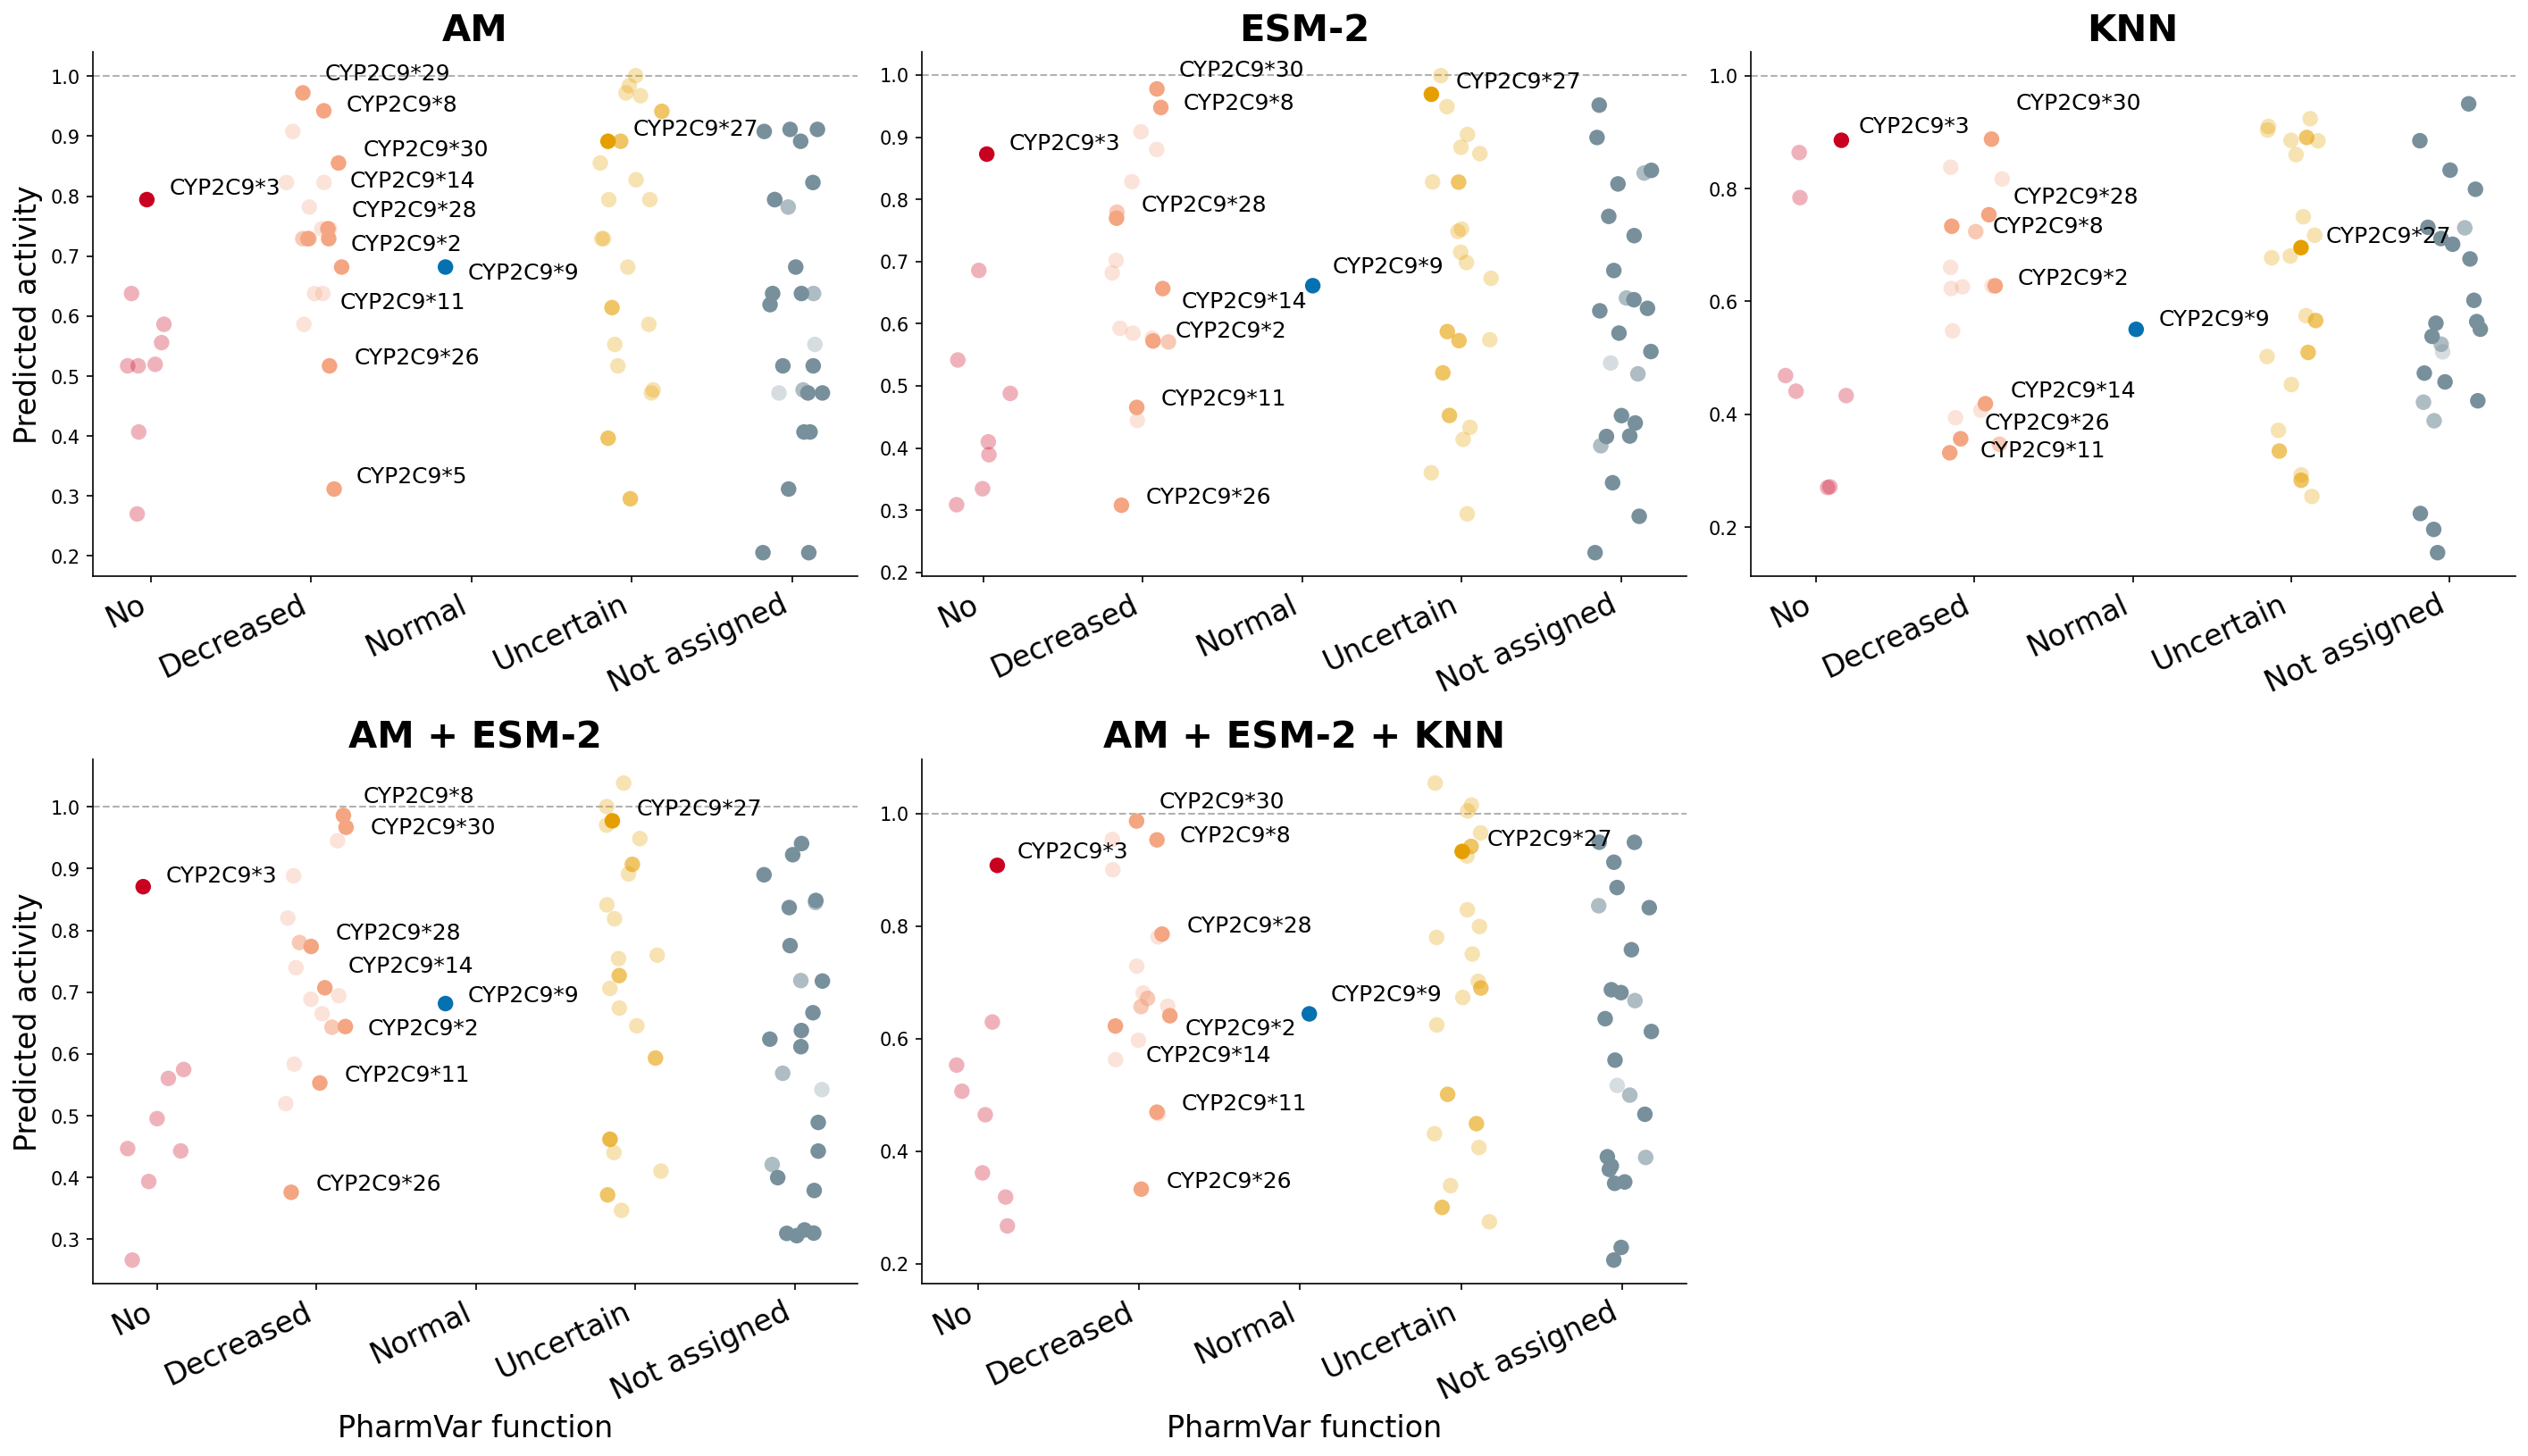

In [24]:
# Merge Unknown + Not Assigned into one plotting category
FUNC_MERGE = {'Function Not Assigned': 'Unknown / Not Assigned',
              'Unknown Function':      'Unknown / Not Assigned'}
pv['Function_plot'] = pv['Function'].replace(FUNC_MERGE)

PV_FUNC_ORDER = [
    'No Function', 'Decreased Function', 'Normal Function',
    'Uncertain Function', 'Unknown / Not Assigned',
]
PV_FUNC_COLORS = {
    'No Function':            '#CA0020',
    'Decreased Function':     '#F4A582',
    'Normal Function':        '#0571B0',
    'Uncertain Function':     '#E69F00',
    'Unknown / Not Assigned': '#78909C',
}
XLABEL_MAP = {'Unknown / Not Assigned': 'Not assigned'}   # x-axis display override
EVID_ALPHA = {'Definitive': 1.0, 'Moderate': 0.6, 'Limited': 0.3}

# Ordinal function scale for quantifying predicted-activity vs. PharmVar-label
# correlation (higher = more functional). Uncertain/Unknown/Not Assigned excluded.
FUNC_NUMERIC = {'No Function': 0, 'Decreased Function': 1, 'Normal Function': 2}
pv['func_numeric'] = pv['Function'].map(FUNC_NUMERIC)

# Reorder models: AM → ESM-2 → KNN → AM + ESM-2 → AM + ESM-2 + KNN
clean = lambda s: s.replace('(individual)', '').strip()
MODEL_ORDER = ['AM', 'ESM-2', 'KNN', 'AM + ESM-2', 'AM + ESM-2 + KNN']
pv_models_ordered = sorted(
    PV_MODELS,
    key=lambda cn: MODEL_ORDER.index(clean(cn[1])) if clean(cn[1]) in MODEL_ORDER else 99)


def plot_activity_by_pharmvar(ax, sub, pred_col, func_present, rng, label_fontsize=12):
    """Jittered scatter of predicted activity by PharmVar function label, colored by
    function and shaded by evidence level; labels Definitive-evidence alleles."""
    allele_pos = {}
    for evid, alpha in EVID_ALPHA.items():
        grp = sub[sub['Evidence Level'] == evid]
        if grp.empty:
            continue
        xs = np.array([func_present.index(f) for f in grp['Function_plot']], dtype=float)
        xs += rng.uniform(-0.2, 0.2, size=len(grp))
        ax.scatter(xs, grp[pred_col].values,
                   c=[PV_FUNC_COLORS[f] for f in grp['Function_plot']],
                   s=70, alpha=alpha, edgecolors='none', zorder=3)
        for xv, (_, row) in zip(xs, grp.iterrows()):      # remember true jittered position
            allele_pos[row['Allele']] = (xv, row[pred_col])

    # Label all Definitive-evidence points except the "Not assigned" column
    texts = []
    label_rows = sub[(sub['Evidence Level'] == 'Definitive') &
                     (sub['Function_plot'] != 'Unknown / Not Assigned')]
    for _, row in label_rows.iterrows():
        xv, yv = allele_pos.get(row['Allele'],
                                (func_present.index(row['Function_plot']), row[pred_col]))
        texts.append(ax.text(xv, yv, row['Allele'], fontsize=label_fontsize))
    adjust_text(texts, ax=ax, only_move={'text': 'y'}, expand_text=(1.05, 1.2))

    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xticks(range(len(func_present)))
    ax.set_xticklabels([XLABEL_MAP.get(f, f.replace(' Function', '')) for f in func_present],
                       fontsize=16, rotation=25, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ── Print Spearman ρ / p / n per model first ──────────────────────────────────
print('Spearman ρ: predicted activity vs ordinal PharmVar function label')
print('(No Function=0, Decreased Function=1, Normal Function=2;')
print(' Uncertain / Unknown / Not Assigned excluded)\n')
for pred_col, name in pv_models_ordered:
    ord_sub = pv.dropna(subset=['func_numeric', pred_col])
    if len(ord_sub) >= 3:
        rho, p = stats.spearmanr(ord_sub['func_numeric'], ord_sub[pred_col])
        stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {clean(name):<20}: rho={rho:+.3f}  p={p:.3e} {stars}  n={len(ord_sub)}')
    else:
        print(f'  {clean(name):<20}: insufficient data (n={len(ord_sub)})')
print()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
axes_flat = axes.flatten()
rng = np.random.default_rng(42)
ncols, n_used = 3, len(pv_models_ordered)

for ax_i, (pred_col, title) in enumerate(pv_models_ordered):
    ax = axes_flat[ax_i]
    sub = pv[pv[pred_col].notna()].copy()
    func_present = [f for f in PV_FUNC_ORDER if f in sub['Function_plot'].values]

    plot_activity_by_pharmvar(ax, sub, pred_col, func_present, rng)

    ax.set_ylabel('Predicted activity' if ax_i % ncols == 0 else '', fontsize=16)
    ax.set_xlabel('PharmVar function' if ax_i + ncols > n_used else '', fontsize=16)
    ax.set_title(clean(title), fontsize=20, fontweight='bold')

# 6th panel unused (only 5 models) -- function/evidence color key lives in the caption
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()


Spearman ρ: predicted activity vs ordinal function label
(No Function=0, Decreased Function=1, Normal Function=2;
 Uncertain / Unknown / Function Not Assigned excluded)

  AM (individual):
    Definitive only           : rho=-0.305  p=0.362 ns  n=11
    Definitive + Moderate     : rho=-0.346  p=0.247 ns  n=13
    All known-function        : rho=+0.505  p=0.004 **  n=30

  ESM-2 (individual):
    Definitive only           : rho=-0.183  p=0.638 ns  n=9
    Definitive + Moderate     : rho=-0.202  p=0.551 ns  n=11
    All known-function        : rho=+0.399  p=0.039 *  n=27

  AM + ESM-2:
    Definitive only           : rho=-0.274  p=0.476 ns  n=9
    Definitive + Moderate     : rho=-0.270  p=0.423 ns  n=11
    All known-function        : rho=+0.498  p=0.008 **  n=27

  KNN (individual):
    Definitive only           : rho=-0.365  p=0.334 ns  n=9
    Definitive + Moderate     : rho=-0.337  p=0.311 ns  n=11
    All known-function        : rho=+0.051  p=0.801 ns  n=27

  AM + ESM-2 + KNN:
   

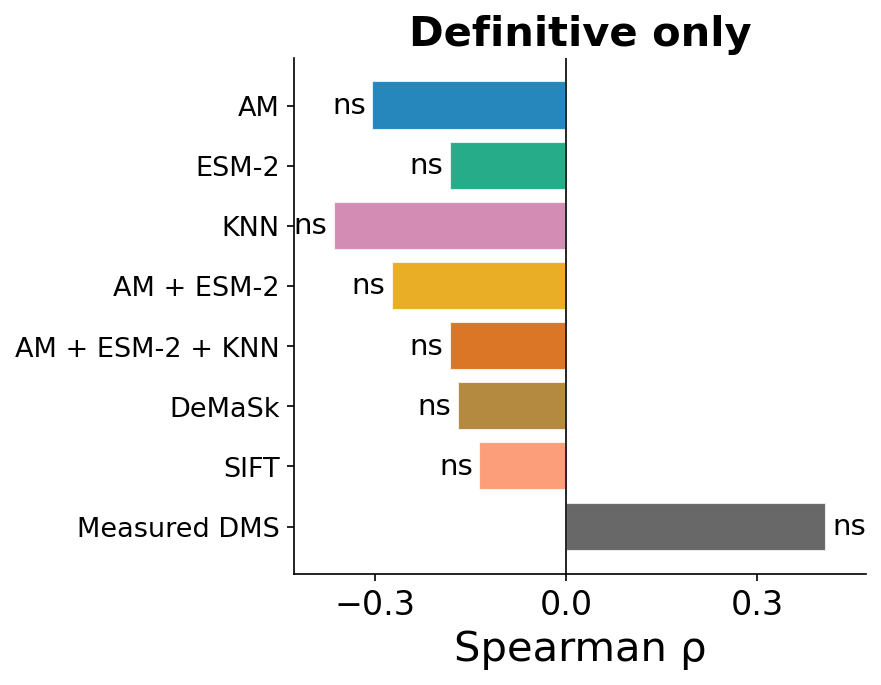

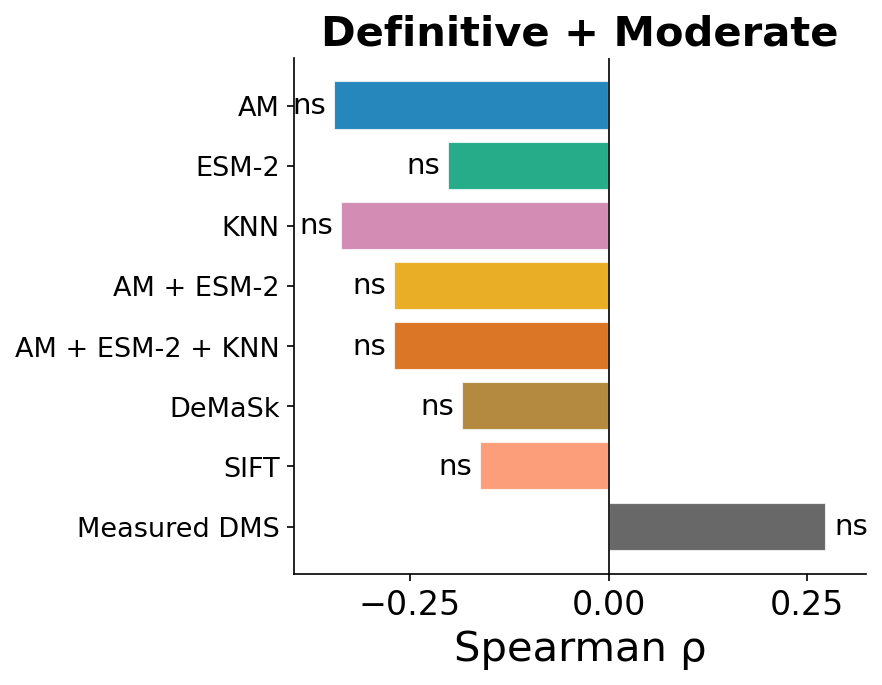

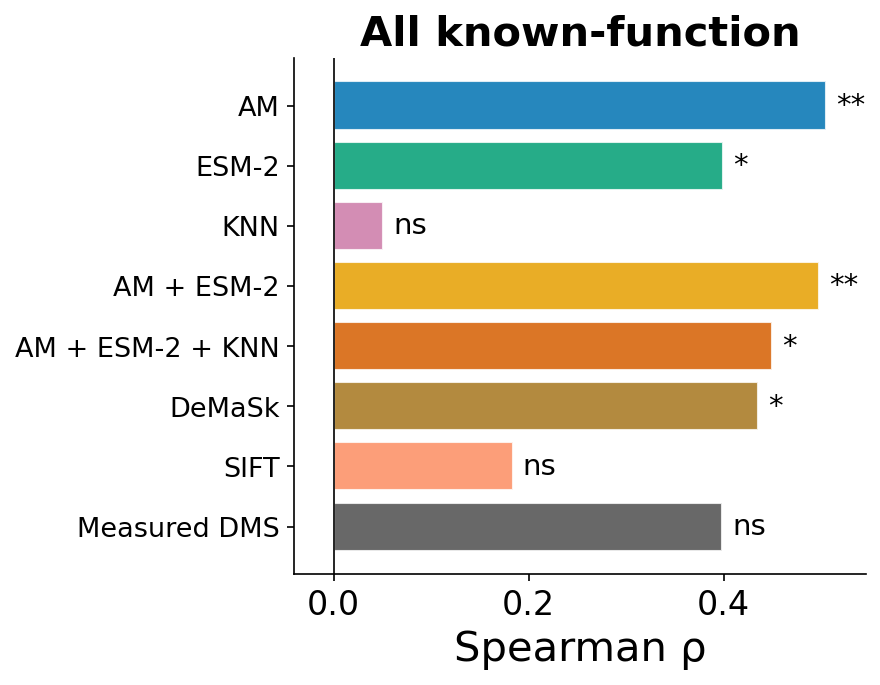

In [25]:
# FUNC_NUMERIC / pv['func_numeric'] already defined above (PharmVar figure cell)
EVID_RANK = {'Limited': 1, 'Moderate': 2, 'Definitive': 3}

pv['evid_rank'] = pv['Evidence Level'].map(EVID_RANK)

evidence_thresholds = [
    ('Definitive only',       3),
    ('Definitive + Moderate', 2),
    ('All known-function',    1),
]

# Include the raw measured click-seq score as a "Measured DMS" reference row
# (predicted -> measured, same ordinal PharmVar scale).
EXT_ORDER = ['demask_score', 'sift']  # PharmGScore, REVEL excluded from clinical alignment (see markdown above)
PV_MODELS_WITH_DMS = (PV_MODELS
                      + [(f'pred_{f}', EXT_SCORES[f]['label']) for f in EXT_ORDER
                         if f'pred_{f}' in pv.columns]
                      + [('click-seq_score', 'Measured DMS')])

print('Spearman ρ: predicted activity vs ordinal function label')
print('(No Function=0, Decreased Function=1, Normal Function=2;')
print(' Uncertain / Unknown / Function Not Assigned excluded)\n')

for col, name in PV_MODELS_WITH_DMS:
    print(f'  {name}:')
    for label, min_evid in evidence_thresholds:
        sub = pv[pv['evid_rank'] >= min_evid].dropna(subset=['func_numeric', col])
        if len(sub) >= 3:
            r, p = stats.spearmanr(sub['func_numeric'], sub[col])
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            print(f'    {label:<26}: rho={r:+.3f}  p={p:.3f} {stars}  n={len(sub)}')
        else:
            print(f'    {label:<26}: insufficient data (n={len(sub)})')
    print()

# ── Bar chart: Spearman rho by evidence level threshold ───────────────────────
MODEL_ORDER = ['AM', 'ESM-2', 'KNN', 'AM + ESM-2', 'AM + ESM-2 + KNN',
               'DeMaSk', 'SIFT', 'Measured DMS']  # top → bottom (PharmGScore, REVEL excluded, see markdown above)
MODEL_COLOR = {
    'AM':                 '#0072B2',
    'ESM-2':              '#009E73',
    'KNN':                '#CC79A7',
    'AM + ESM-2':         '#E69F00',
    'AM + ESM-2 + KNN':   '#D55E00',
    'DeMaSk':             '#A6761D',
    'SIFT':               '#FC8D62',
    'Measured DMS':       '#4D4D4D',
}
clean = lambda s: s.replace('(individual)', '').strip()

def _tight_rho_xaxis(ax, rhos, pad_frac=0.08):
    """Tight x-limits around just the bars (always including 0), with a small,
    clean tick set (0 plus 1-2 more) instead of fixed (-1, 1) limits."""
    vals = [v for v in rhos if v == v] + [0.0]
    lo, hi = min(vals), max(vals)
    span = (hi - lo) or 1.0
    pad = span * pad_frac
    lo_lim, hi_lim = lo - pad, hi + pad
    ax.set_xlim(lo_lim, hi_lim)
    raw_ticks = MaxNLocator(nbins=3).tick_values(lo_lim, hi_lim)
    ticks = sorted(set([0.0] + [t for t in raw_ticks if lo_lim <= t <= hi_lim]))
    if len(ticks) > 3:
        ticks = sorted({0.0, ticks[0], ticks[-1]})
    ax.set_xticks(ticks)

for label, min_evid in evidence_thresholds:
    sub_all = pv[pv['evid_rank'] >= min_evid].dropna(subset=['func_numeric'])

    # collect results keyed by cleaned model name
    stats_by_model = {}
    for col, name in PV_MODELS_WITH_DMS:
        sub = sub_all.dropna(subset=[col])
        if len(sub) >= 3:
            r, p = stats.spearmanr(sub['func_numeric'], sub[col])
        else:
            r, p = 0.0, 1.0
        stats_by_model[clean(name)] = (r, p)

    # reorder to the desired top-to-bottom order
    model_names = [m for m in MODEL_ORDER if m in stats_by_model]
    r_vals = [stats_by_model[m][0] for m in model_names]
    p_vals = [stats_by_model[m][1] for m in model_names]
    colors = [MODEL_COLOR[m] for m in model_names]

    fig, ax = plt.subplots(figsize=(6, 0.4 * len(MODEL_ORDER) + 1.5))
    ys   = range(len(model_names))
    bars = ax.barh(list(ys), r_vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v, p in zip(bars, r_vals, p_vals):
        stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        yc = bar.get_y() + bar.get_height() / 2
        if v >= 0:
            ax.text(v + 0.01, yc, f'{stars}', va='center', ha='left', fontsize=14)
        else:
            ax.text(v - 0.01, yc, f'{stars}', va='center', ha='right', fontsize=14)

    ax.set_yticks(list(ys))
    ax.set_yticklabels(model_names, fontsize=13)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    _tight_rho_xaxis(ax, r_vals)
    ax.set_xlabel('Spearman ρ', fontsize=20)
    ax.tick_params(axis='x', labelsize=16)
    ax.set_title(f'{label}', fontsize=20, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

PharmVar variants with click-seq: 60

Model                   Spearman r         p     n
----------------------------------------------------
  AM (individual)            0.500     0.000    60
  ESM-2 (individual)         0.581     0.000    60
  AM + ESM-2                 0.564     0.000    60
  KNN (individual)           0.529     0.000    60
  AM + ESM-2 + KNN           0.571     0.000    60



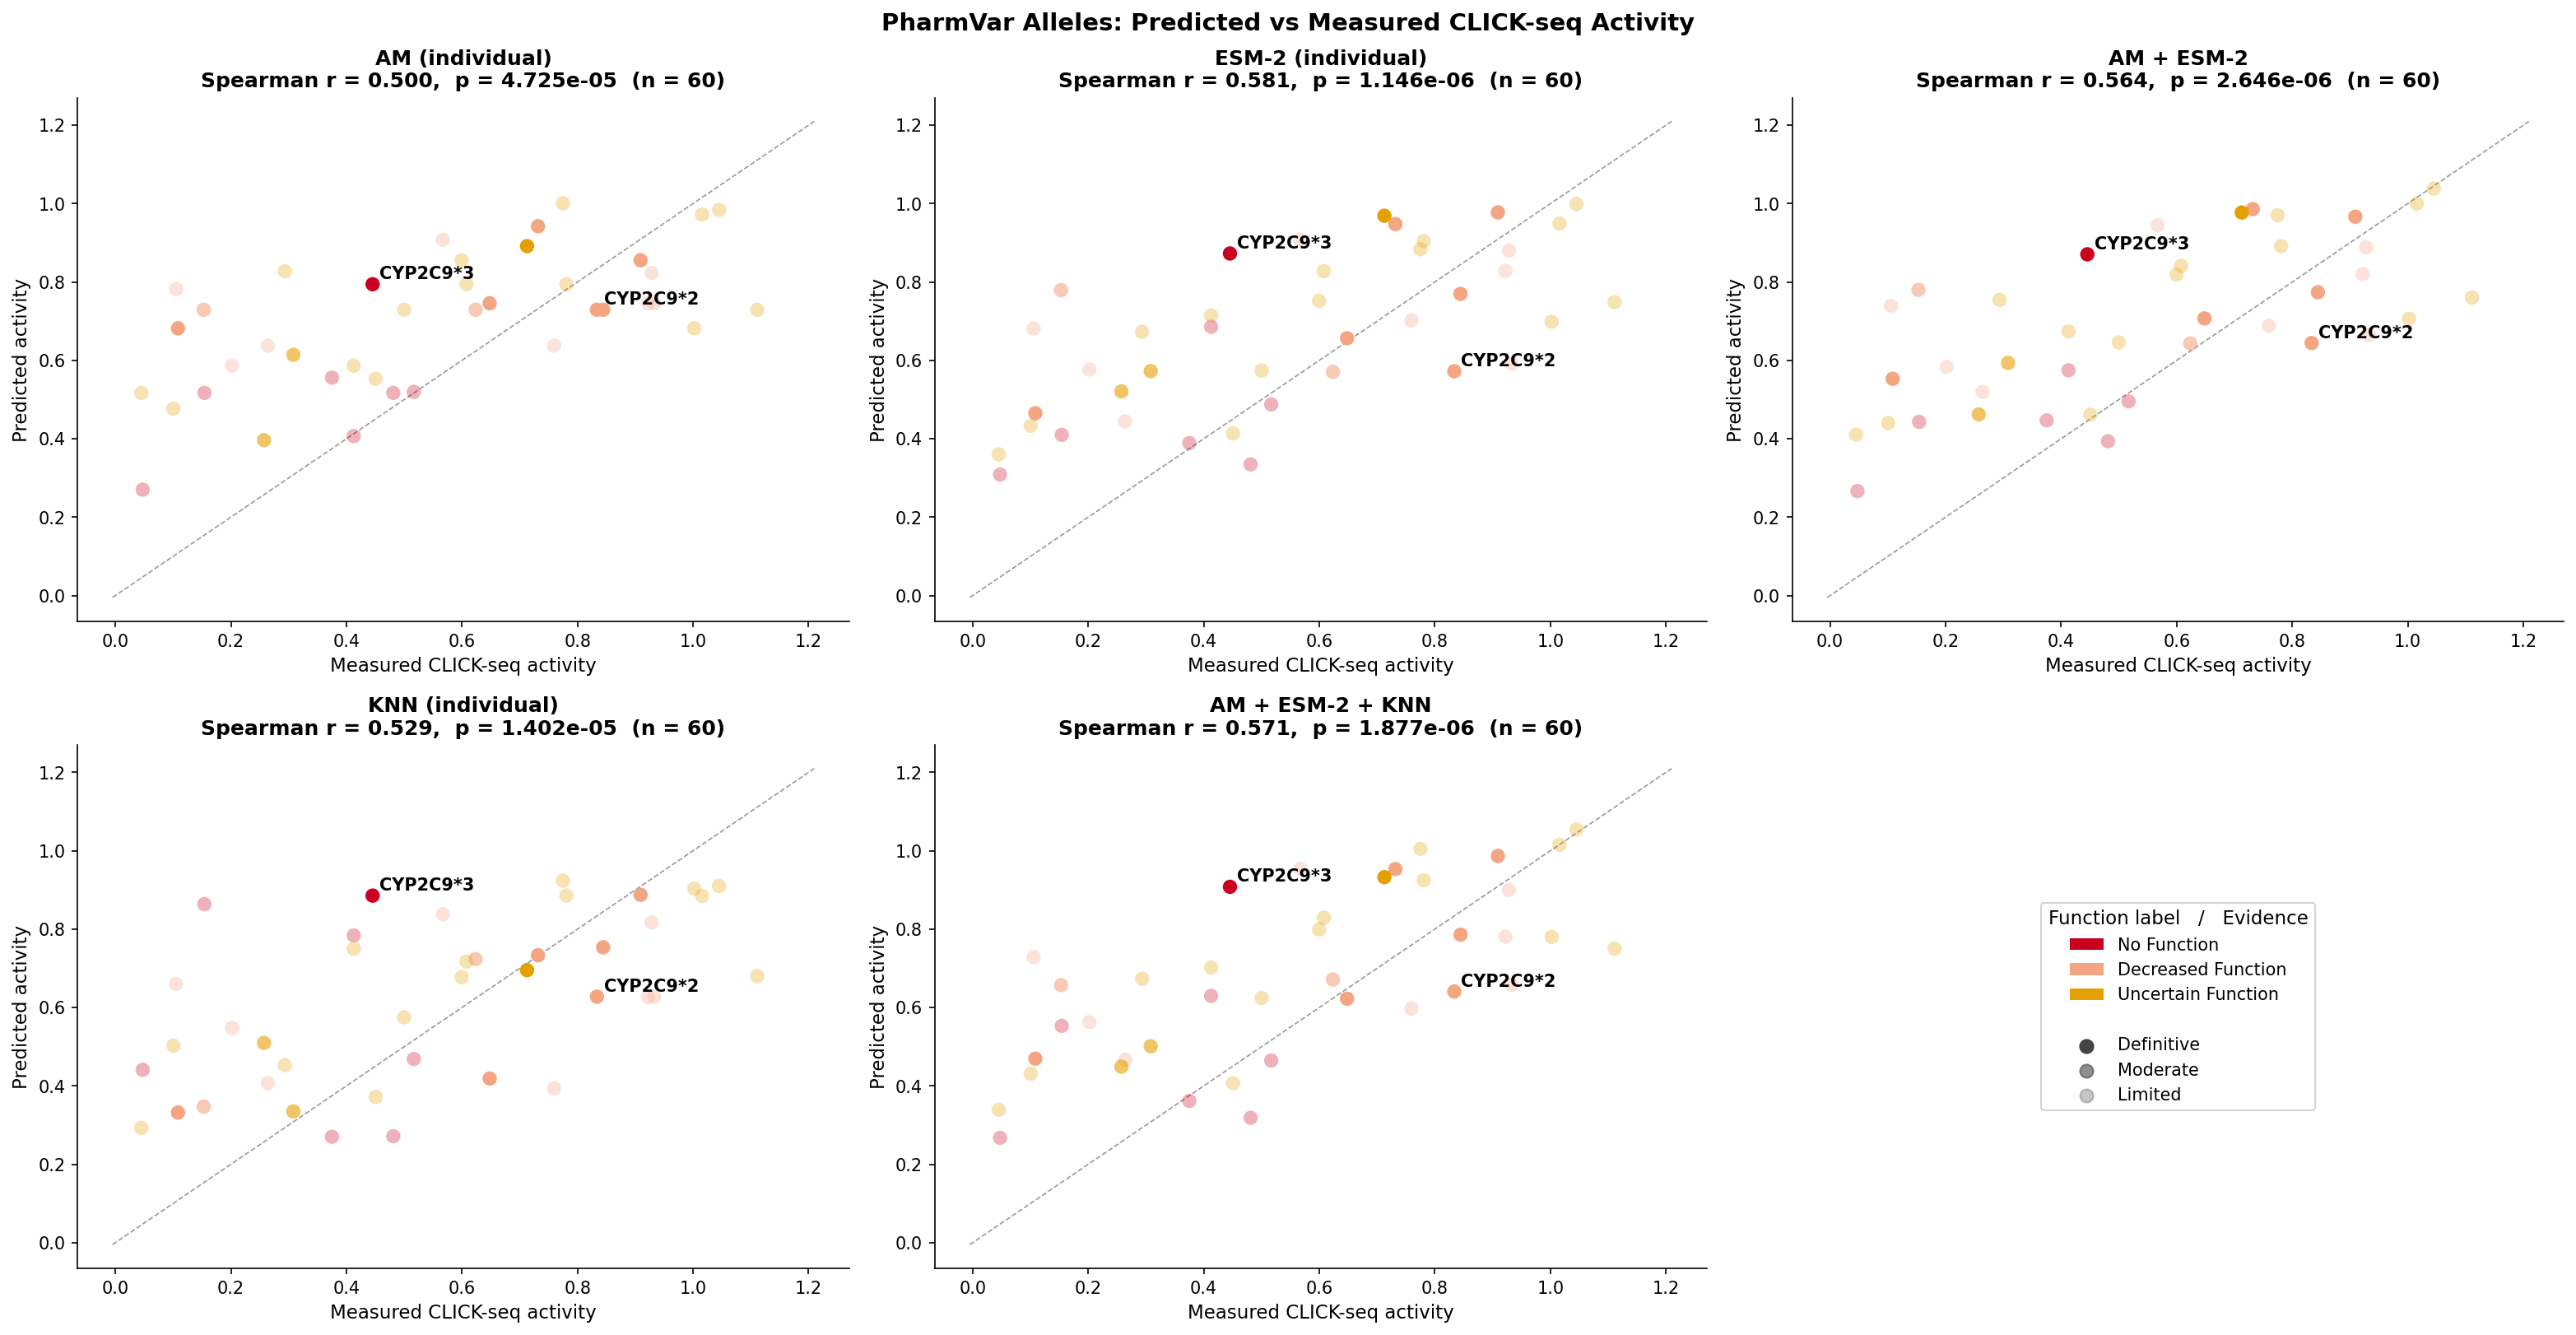

In [26]:
pv_click = pv[pv['click-seq_score'].notna()].drop_duplicates(['ref', 'pos', 'alt']).copy()
print(f'PharmVar variants with click-seq: {len(pv_click)}\n')

print(f'{"Model":<22}  {"Spearman r":>10}  {"p":>8}  {"n":>4}')
print('-' * 52)
for col, name in PV_MODELS:
    sub = pv_click[pv_click[col].notna()]
    r, p = stats.spearmanr(sub['click-seq_score'], sub[col])
    print(f'  {name:<20}  {r:>10.3f}  {p:>8.3f}  {len(sub):>4}')

print()
valid_models_pv = [(col, name) for col, name in PV_MODELS if pv_click[col].notna().any()]
ncols    = min(3, len(valid_models_pv))
nrows    = (len(valid_models_pv) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax_i, (pred_col, title) in enumerate(valid_models_pv):
    ax  = axes_flat[ax_i]
    sub = pv_click[pv_click[pred_col].notna()].copy()

    for func in PV_FUNC_ORDER:
        for evid, alpha in EVID_ALPHA.items():
            grp = sub[(sub['Function'] == func) & (sub['Evidence Level'] == evid)]
            if grp.empty: continue
            ax.scatter(grp['click-seq_score'], grp[pred_col],
                       color=PV_FUNC_COLORS[func],
                       s=70, alpha=alpha, edgecolors='none', zorder=3)

    for _, row in sub[sub['Allele'].isin({'CYP2C9*2', 'CYP2C9*3'})].iterrows():
        ax.annotate(row['Allele'], (row['click-seq_score'], row[pred_col]),
                    fontsize=10, xytext=(4, 3), textcoords='offset points', fontweight='bold')

    lo = min(sub['click-seq_score'].min(), sub[pred_col].min()) - 0.05
    hi = max(sub['click-seq_score'].max(), sub[pred_col].max()) + 0.05
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.4)

    r, p = stats.spearmanr(sub['click-seq_score'], sub[pred_col])
    ax.set_title(f'{title}\nSpearman r = {r:.3f},  p = {p:.3e}  (n = {len(sub)})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Measured CLICK-seq activity', fontsize=11)
    ax.set_ylabel('Predicted activity', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared legend on last panel
ax_leg = axes_flat[len(valid_models_pv)]
ax_leg.axis('off')
func_present = [f for f in PV_FUNC_ORDER if f in pv_click['Function'].values]
func_h = [Patch(facecolor=PV_FUNC_COLORS[f], label=f) for f in func_present]
sep    = [Line2D([0], [0], color='none')]
evid_h = [ax_leg.scatter([], [], c='#444444', s=60, alpha=a, label=e)
          for e, a in EVID_ALPHA.items()]
ax_leg.legend(handles=func_h + sep + evid_h,
              labels=[f for f in func_present] + [''] + list(EVID_ALPHA.keys()),
              loc='center', fontsize=10,
              title='Function label   /   Evidence', title_fontsize=11)

for ax_i in range(len(valid_models_pv) + 1, nrows * ncols):
    axes_flat[ax_i].set_visible(False)

fig.suptitle('PharmVar Alleles: Predicted vs Measured CLICK-seq Activity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Comprehensive metrics: all 5 methods × ClinVar / PharmVar / DMS datasets
# ─────────────────────────────────────────────────────────────────────────────
def _clf_metrics(y_true, y_score, pos_higher=True):
    """Binary classification metrics; finds optimal threshold via Youden's J."""
    s = y_score if pos_higher else -y_score
    try:
        auroc = roc_auc_score(y_true, s)
        auprc = average_precision_score(y_true, s)
        fpr, tpr, thrs = roc_curve(y_true, s)
        opt   = np.argmax(tpr - fpr)
        y_hat = (s >= thrs[opt]).astype(int)
    except Exception:
        return {k: np.nan for k in ['AUROC','AUPRC','Accuracy','Precision','Recall','F1','MCC']}
    return {
        'AUROC':     round(float(auroc), 3),
        'AUPRC':     round(float(auprc), 3),
        'Accuracy':  round(float(accuracy_score(y_true, y_hat)), 3),
        'Precision': round(float(precision_score(y_true, y_hat, zero_division=0)), 3),
        'Recall':    round(float(recall_score(y_true, y_hat, zero_division=0)), 3),
        'F1':        round(float(f1_score(y_true, y_hat, zero_division=0)), 3),
        'MCC':       round(float(matthews_corrcoef(y_true, y_hat)), 3),
    }


METHODS = {
    'AlphaMissense':    'pred_am',
    'ESM-2':            'pred_esm2',
    'KNN':              'pred_knn',
    'AM + ESM-2':       'pred_ensemble',
    'AM + ESM-2 + KNN': 'pred_ens_knn',
}

DMS_METHODS = {
    'AlphaMissense':    'oof_am_emb',
    'ESM-2':            'oof_esm_emb',
    'KNN':              'oof_knn_emb',
    'AM + ESM-2':       'oof_ens_emb',
    'AM + ESM-2 + KNN': 'oof_ens_knn',
}

# ── 1. ClinVar ────────────────────────────────────────────────────────────────
# Gold standard: B/LB = benign (0), LP/P = pathogenic (1); VUS excluded.
# Higher predicted activity → benign, so pos_higher=False for pathogenic as positive.
cv_eval = cv_pred[cv_pred['category'].isin(
    ['benign','likely_benign','likely_pathogenic','pathogenic'])].copy()
cv_eval['label'] = cv_eval['category'].isin(
    ['likely_pathogenic','pathogenic']).astype(int)

clinvar_rows = {}
for name, col in METHODS.items():
    sub = cv_eval.dropna(subset=[col])
    m   = _clf_metrics(sub['label'].values, sub[col].values, pos_higher=False)
    m['N'] = len(sub)
    clinvar_rows[name] = m

clinvar_metrics = (
    pd.DataFrame(clinvar_rows).T
      [['N','AUROC','AUPRC','Accuracy','Precision','Recall','F1','MCC']]
)
clinvar_metrics.index.name = 'Method'
print('=== ClinVar Metrics (B/LB=benign vs LP/P=pathogenic, VUS excluded) ===')
print(f'  Total N = {len(cv_eval)}  '
      f'(benign={int((cv_eval.label==0).sum())}, pathogenic={int((cv_eval.label==1).sum())})')
print(clinvar_metrics.to_string())

# ── 2. PharmVar ───────────────────────────────────────────────────────────────
# Gold standard: Normal Function = 1, Decreased/No Function = 0; uncertain excluded.
# Higher predicted activity → Normal Function (positive), so pos_higher=True.
pv_eval = pv[pv['Function'].isin(
    ['No Function','Decreased Function','Normal Function'])].copy()
pv_eval['label'] = (pv_eval['Function'] == 'Normal Function').astype(int)

pharmvar_rows = {}
for name, col in METHODS.items():
    sub = pv_eval.dropna(subset=[col])
    m   = _clf_metrics(sub['label'].values, sub[col].values, pos_higher=True)
    pv_ord = pv.dropna(subset=[col, 'func_numeric'])
    rho, _ = stats.spearmanr(pv_ord[col], pv_ord['func_numeric'])
    m['Spearman_rho'] = round(float(rho), 3)
    m['N'] = len(sub)
    pharmvar_rows[name] = m

pharmvar_metrics = (
    pd.DataFrame(pharmvar_rows).T
      [['N','AUROC','AUPRC','Accuracy','Precision','Recall','F1','MCC','Spearman_rho']]
)
pharmvar_metrics.index.name = 'Method'
print('\n=== PharmVar Metrics (Normal Function vs Decreased/No Function) ===')
print(f'  Total N = {len(pv_eval)}  '
      f'(normal={int((pv_eval.label==1).sum())}, decreased/no={int((pv_eval.label==0).sum())})')
print(pharmvar_metrics.to_string())

# ── 3. DMS / CLICK-seq ────────────────────────────────────────────────────────
# Gold standard: continuous click-seq_score (OOF predictions on embedding subset).
# Regression: Spearman, Pearson, RMSE.
# Binary split at median: above-median activity = 1 (functional), below = 0.
dms_median = emb_train['click-seq_score'].median()

dms_rows = {}
for name, col in DMS_METHODS.items():
    sub    = emb_train.dropna(subset=[col, 'click-seq_score'])
    y_cont = sub['click-seq_score'].values
    y_pred = sub[col].values
    rho, _ = stats.spearmanr(y_pred, y_cont)
    r, _   = stats.pearsonr(y_pred, y_cont)
    rmse   = float(np.sqrt(np.mean((y_pred - y_cont) ** 2)))
    y_bin  = (y_cont >= dms_median).astype(int)
    m      = _clf_metrics(y_bin, y_pred, pos_higher=True)
    m.update({
        'Spearman_rho': round(float(rho), 3),
        'Pearson_r':    round(float(r), 3),
        'RMSE':         round(float(rmse), 4),
        'N': len(sub),
    })
    dms_rows[name] = m

dms_metrics = (
    pd.DataFrame(dms_rows).T
      [['N','Spearman_rho','Pearson_r','RMSE','AUROC','AUPRC','Accuracy','Precision','Recall','F1','MCC']]
)
dms_metrics.index.name = 'Method'
print('\n=== DMS / CLICK-seq Metrics (OOF on embedding subset) ===')
print(f'  N = {len(emb_train.dropna(subset=["click-seq_score"]))}, '
      f'binary threshold = median ({dms_median:.4f})')
print(dms_metrics.to_string())


=== ClinVar Metrics (B/LB=benign vs LP/P=pathogenic, VUS excluded) ===
  Total N = 8  (benign=7, pathogenic=1)
                    N  AUROC  AUPRC  Accuracy  Precision  Recall     F1    MCC
Method                                                                        
AlphaMissense     8.0  0.286  0.167     0.375      0.167     1.0  0.286  0.218
ESM-2             7.0  0.333  0.200     0.429      0.200     1.0  0.333  0.258
KNN               7.0  0.000  0.143     0.857      0.000     0.0  0.000  0.000
AM + ESM-2        7.0  0.333  0.200     0.429      0.200     1.0  0.333  0.258
AM + ESM-2 + KNN  7.0  0.333  0.200     0.429      0.200     1.0  0.333  0.258

=== PharmVar Metrics (Normal Function vs Decreased/No Function) ===
  Total N = 30  (normal=1, decreased/no=29)
                     N  AUROC  AUPRC  Accuracy  Precision  Recall     F1    MCC  Spearman_rho
Method                                                                                       
AlphaMissense     30.0  0.466  0.05